In [1]:
# ==========================================================
# Conectar Google Drive
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# Rutas del proyecto
# ==========================================================

from pathlib import Path

RUTA_PROYECTO = Path(
    "/content/drive/MyDrive/Analisis_Geoespacial_Cobre"
)

NOTEBOOK = RUTA_PROYECTO / "01_Notebook"

DATOS = RUTA_PROYECTO / "02_Datos"
ORIGINALES = DATOS / "01_Originales"
PROCESADOS = DATOS / "02_Procesados"
ESTUDIO = DATOS / "03_Estudio"

FIGURAS = RUTA_PROYECTO / "03_Figuras"
RESULTADOS = RUTA_PROYECTO / "04_Resultados"
SCRIPTS = RUTA_PROYECTO / "05_Scripts"
DOCUMENTACION = RUTA_PROYECTO / "06_Documentacion"

print("Proyecto conectado correctamente.")

Proyecto conectado correctamente.


In [7]:
# ==========================================================
# Carga de datos
# ==========================================================

muestras = gpd.read_file(PROCESADOS / "Muestras_Cu.gpkg")
geologia = gpd.read_file(PROCESADOS / "Geologia_Suroeste.gpkg")
fallas = gpd.read_file(PROCESADOS / "Fallas_Suroeste.gpkg")
municipios = gpd.read_file(PROCESADOS / "Municipios_Suroeste.gpkg")

print("Capas cargadas correctamente.")

Capas cargadas correctamente.


In [115]:
!pip install geopandas
!pip install contextily
!pip install matplotlib-scalebar
!pip install scikit-gstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 710.3/710.3 kB 29.9 MB/s eta 0:00:00


In [126]:
import skgstat
print(skgstat.__version__)

1.0.23


# Análisis Geoespacial de la Distribución de Cobre en el Suroeste Antioqueño

**Autora:** Daniela Cardona Lopera

**Curso:** Análisis Geoespacial

**Software:** Google Colab (Python) y QGIS

**Objetivo:** Analizar la distribución espacial de la concentración de cobre (Cu) mediante técnicas de análisis exploratorio de datos (EDA), análisis espacial y geoestadística (variografía y kriging), utilizando información geológica y estructural del Suroeste antioqueño.


Este notebook documenta el flujo completo del análisis geoestadístico realizado sobre la base de datos geoquímica de cobre correspondiente al suroeste del departamento de Antioquia. El objetivo es caracterizar el comportamiento espacial de la variable mediante técnicas de análisis exploratorio, modelamiento variográfico e interpolación por kriging ordinario.

El desarrollo se estructura en cinco etapas: preparación de la información, análisis exploratorio de datos, exploración espacial, análisis geoestadístico e interpretación de resultados. Cada sección presenta el código empleado, los resultados obtenidos y su respectiva interpretación técnica.

# 1. Preparación de los datos

Antes de realizar el análisis exploratorio y el modelamiento geoestadístico, es necesario preparar y verificar la información espacial y tabular del proyecto. En esta etapa se organizan los archivos, se comprueba la consistencia del sistema de referencia de coordenadas (CRS), se revisa la integridad de las geometrías y se valida que todas las capas se encuentren listas para el análisis espacial.

Estas actividades garantizan que las operaciones posteriores, como el análisis exploratorio, la construcción del variograma y la interpolación mediante kriging, se realicen sobre una base de datos consistente y libre de errores geométricos.

## 1.1 Organización de la información

Los archivos del proyecto fueron organizados en una estructura de carpetas que diferencia la información original, los datos procesados y los productos generados durante el análisis. Esta organización facilita la trazabilidad de la información y la reproducibilidad del proyecto.

In [28]:
# =====================================================
# Organización del proyecto
# =====================================================

from google.colab import drive
from pathlib import Path

# Conectar Google Drive
drive.mount('/content/drive')

# Carpeta principal del proyecto
RUTA_PROYECTO = Path("/content/drive/MyDrive/Analisis_Geoespacial_Cobre")

# Subcarpetas
NOTEBOOK = RUTA_PROYECTO / "01_Notebook"

DATOS = RUTA_PROYECTO / "02_Datos"
ORIGINALES = DATOS / "01_Originales"
PROCESADOS = DATOS / "02_Procesados"
ESTUDIO = DATOS / "03_Estudio"

FIGURAS = RUTA_PROYECTO / "03_Figuras"
RESULTADOS = RUTA_PROYECTO / "04_Resultados"
SCRIPTS = RUTA_PROYECTO / "05_Scripts"
DOCUMENTACION = RUTA_PROYECTO / "06_Documentacion"

print("Proyecto conectado correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Proyecto conectado correctamente.


In [35]:
print("Proyecto:", RUTA_PROYECTO.exists())
print("Originales:", ORIGINALES.exists())
print("Procesados:", PROCESADOS.exists())
print("Estudio:", ESTUDIO.exists())
print("Figuras:", FIGURAS.exists())
print("Resultados:", RESULTADOS.exists())
print("Scripts:", SCRIPTS.exists())
print("Documentación:", DOCUMENTACION.exists())

Proyecto: True
Originales: True
Procesados: True
Estudio: True
Figuras: True
Resultados: True
Scripts: True
Documentación: True


In [36]:
# ==========================================================
# Librerías
# ==========================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

from pathlib import Path

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [37]:
# ==========================================================
# Instalación de librerías adicionales
# (Ejecutar una sola vez por sesión de Google Colab)
# ==========================================================

!pip -q install contextily
!pip -q install matplotlib-scalebar
!pip -q install adjustText

In [6]:
# ==========================================================
# Importación de librerías para cartografía
# ==========================================================

import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar
from adjustText import adjust_text

## 1.2 Carga de datos

En esta etapa se cargan las capas espaciales y la base de datos de concentraciones de cobre que serán utilizadas durante el análisis. La información incluye las muestras geoquímicas, los municipios del suroeste antioqueño, la cartografía geológica y las fallas geológicas del área de estudio.

In [8]:
# ==========================================================
# Carga de datos
# ==========================================================

muestras = gpd.read_file(
    PROCESADOS / "Muestras_Cu.gpkg"
)

geologia = gpd.read_file(
    PROCESADOS / "Geologia_Suroeste.gpkg"
)

fallas = gpd.read_file(
    PROCESADOS / "Fallas_Suroeste.gpkg"
)

municipios = gpd.read_file(
    PROCESADOS / "Municipios_Suroeste.gpkg"
)

print("Capas cargadas correctamente.\n")
print(f"Muestras:   {len(muestras)}")
print(f"Geología:   {len(geologia)}")
print(f"Fallas:     {len(fallas)}")
print(f"Municipios: {len(municipios)}")

Capas cargadas correctamente.

Muestras:   2103
Geología:   658
Fallas:     475
Municipios: 23


## 1.3 Verificación de las capas

Una vez cargada la información, se verifica que todas las capas hayan sido importadas correctamente, comprobando el número de registros y el sistema de referencia de coordenadas (CRS) asociado a cada una.

In [9]:
# ==========================================================
# Información general de las capas
# ==========================================================

print("===== CAPAS CARGADAS =====\n")

print(f"Muestras: {len(muestras)} registros")
print(f"Municipios: {len(municipios)} registros")
print(f"Geología: {len(geologia)} registros")
print(f"Fallas: {len(fallas)} registros")

print("\nSistema de referencia:")

print("Muestras :", muestras.crs)
print("Municipios:", municipios.crs)
print("Geología :", geologia.crs)
print("Fallas   :", fallas.crs)

===== CAPAS CARGADAS =====

Muestras: 2103 registros
Municipios: 23 registros
Geología: 658 registros
Fallas: 475 registros

Sistema de referencia:
Muestras : EPSG:21897
Municipios: EPSG:21897
Geología : EPSG:21897
Fallas   : EPSG:21897


## 1.4 Conversión y revisión de la variable Cu

Se verifica que la variable correspondiente a la concentración de cobre (Cu) tenga un formato numérico adecuado y que no existan valores nulos que puedan afectar los análisis estadísticos y geoestadísticos posteriores.

In [10]:
# ==========================================================
# Información de la variable Cu
# ==========================================================

print(muestras.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2103 entries, 0 to 2102
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Y         2103 non-null   float64 
 1   X         2103 non-null   float64 
 2   Cu        2103 non-null   object  
 3   geometry  2103 non-null   geometry
dtypes: float64(2), geometry(1), object(1)
memory usage: 65.8+ KB
None


In [11]:
# ==========================================================
# Convertir la variable Cu a numérica
# ==========================================================

muestras["Cu"] = pd.to_numeric(muestras["Cu"], errors="coerce")

print(muestras.dtypes)

Y            float64
X            float64
Cu             int64
geometry    geometry
dtype: object


In [12]:
# =====================================================
# Verificación de la variable Cu
# =====================================================

print(f"Valores nulos: {muestras['Cu'].isna().sum()}")
print(f"Valores negativos: {(muestras['Cu'] < 0).sum()}")

print("\nResumen de Cu:")
display(muestras["Cu"].describe())

Valores nulos: 0
Valores negativos: 0

Resumen de Cu:


,Cu
count,2103.000000
mean,72.623871
std,56.611406
min,5.000000
25%,30.000000
50%,70.000000
75%,100.000000
max,1000.000000


Finalmente, se revisa la validez de las geometrías de todas las capas espaciales para identificar posibles errores topológicos que puedan afectar las operaciones espaciales. Las geometrías inválidas detectadas fueron corregidas previamente durante el preprocesamiento de la información en QGIS.

# 2. Análisis Exploratorio de Datos (EDA) con toda la base de datos original

En esta sección se realiza un análisis exploratorio de la concentración de cobre (Cu) con el fin de conocer el comportamiento de los datos antes de aplicar técnicas geoestadísticas como el variograma y el kriging.

Se evaluará la calidad de la información, la distribución de la variable y sus principales características estadísticas.

## 2.1 Estadística descriptiva

Antes de realizar el análisis espacial y geoestadístico, se calculan las principales medidas descriptivas de la concentración de cobre (Cu). Estas estadísticas permiten conocer el comportamiento general de los datos, identificar su variabilidad y detectar posibles valores extremos.

In [13]:
# ==========================================================
# Estadística descriptiva de la concentración de cobre
# ==========================================================

estadistica = muestras["Cu"].describe()

display(estadistica)

,Cu
count,2103.000000
mean,72.623871
std,56.611406
min,5.000000
25%,30.000000
50%,70.000000
75%,100.000000
max,1000.000000


In [14]:
# Guardar tabla de estadística descriptiva

estadistica.to_csv(
    RESULTADOS / "Tabla_01_Estadistica_Descriptiva.csv",
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente.")

Tabla guardada correctamente.


**Tabla 1.** Estadística descriptiva de la concentración de cobre.

La base de datos contiene **2103 muestras** de concentración de cobre (Cu), con valores comprendidos entre **5 y 1000 ppm**. La media (72.62 ppm) y la mediana (70 ppm) presentan valores muy próximos, indicando que la mayor parte de las observaciones se concentra alrededor de estos valores. Sin embargo, la amplia diferencia entre el valor máximo y el resto de la distribución sugiere la existencia de concentraciones excepcionalmente altas que deberán evaluarse en los análisis posteriores.

## 2.2 Estadísticos complementarios

Además de las estadísticas descriptivas básicas, se calculan medidas complementarias que permiten evaluar la variabilidad y la forma de la distribución de la concentración de cobre (Cu). Estos indicadores son fundamentales para determinar si los datos presentan alta dispersión, asimetría o valores extremos antes de realizar el análisis geoestadístico.

In [15]:
# ==========================================================
# Estadísticos complementarios
# ==========================================================

from scipy.stats import skew, kurtosis

# Variable de trabajo
cu = muestras["Cu"]

# Calcular estadísticos
media = cu.mean()
mediana = cu.median()
moda = cu.mode()[0]

desviacion = cu.std(ddof=1)
varianza = cu.var(ddof=1)

coef_variacion = (desviacion / media) * 100

asimetria = skew(cu)
curtosis_valor = kurtosis(cu, fisher=False)

tabla_estadisticos = pd.DataFrame({

    "Estadístico":[
        "Media",
        "Mediana",
        "Moda",
        "Desviación estándar",
        "Varianza",
        "Coeficiente de variación (%)",
        "Asimetría",
        "Curtosis"
    ],

    "Valor":[
        media,
        mediana,
        moda,
        desviacion,
        varianza,
        coef_variacion,
        asimetria,
        curtosis_valor
    ]

})

display(tabla_estadisticos.round(2))

,Estadístico,Valor
0,Media,72.62
1,Mediana,70.00
2,Moda,70.00
3,Desviación estándar,56.61
4,Varianza,3204.85
5,Coeficiente de variación (%),77.95
6,Asimetría,4.19
7,Curtosis,49.23


In [30]:
# Guardar tabla de estadísticos complementarios

tabla_estadisticos.round(2).to_csv(
    RESULTADOS / "Tabla_02_Estadisticos_Complementarios.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla guardada correctamente.")

Tabla guardada correctamente.


**Tabla 2.** Estadísticos complementarios de la concentración de cobre.

Los estadísticos complementarios muestran que la concentración de cobre presenta una alta variabilidad, reflejada en un coeficiente de variación de 77.95 %, lo que indica una distribución heterogénea de los datos.

Asimismo, la asimetría positiva (4.19) y la curtosis (49.23) evidencian que la distribución está influenciada por un número reducido de muestras con concentraciones significativamente superiores al resto, comportamiento característico de datos geoquímicos asociados a procesos de mineralización.

En conjunto, estos resultados justifican evaluar la distribución de la variable mediante histogramas, diagramas de caja y pruebas de normalidad antes de realizar el análisis geoestadístico.

## 2.3 Histograma

El histograma permite visualizar la distribución de frecuencias de la concentración de cobre (Cu). Este gráfico facilita la identificación de la forma de la distribución, la presencia de sesgos y posibles valores extremos, aspectos fundamentales antes de realizar el análisis geoestadístico.

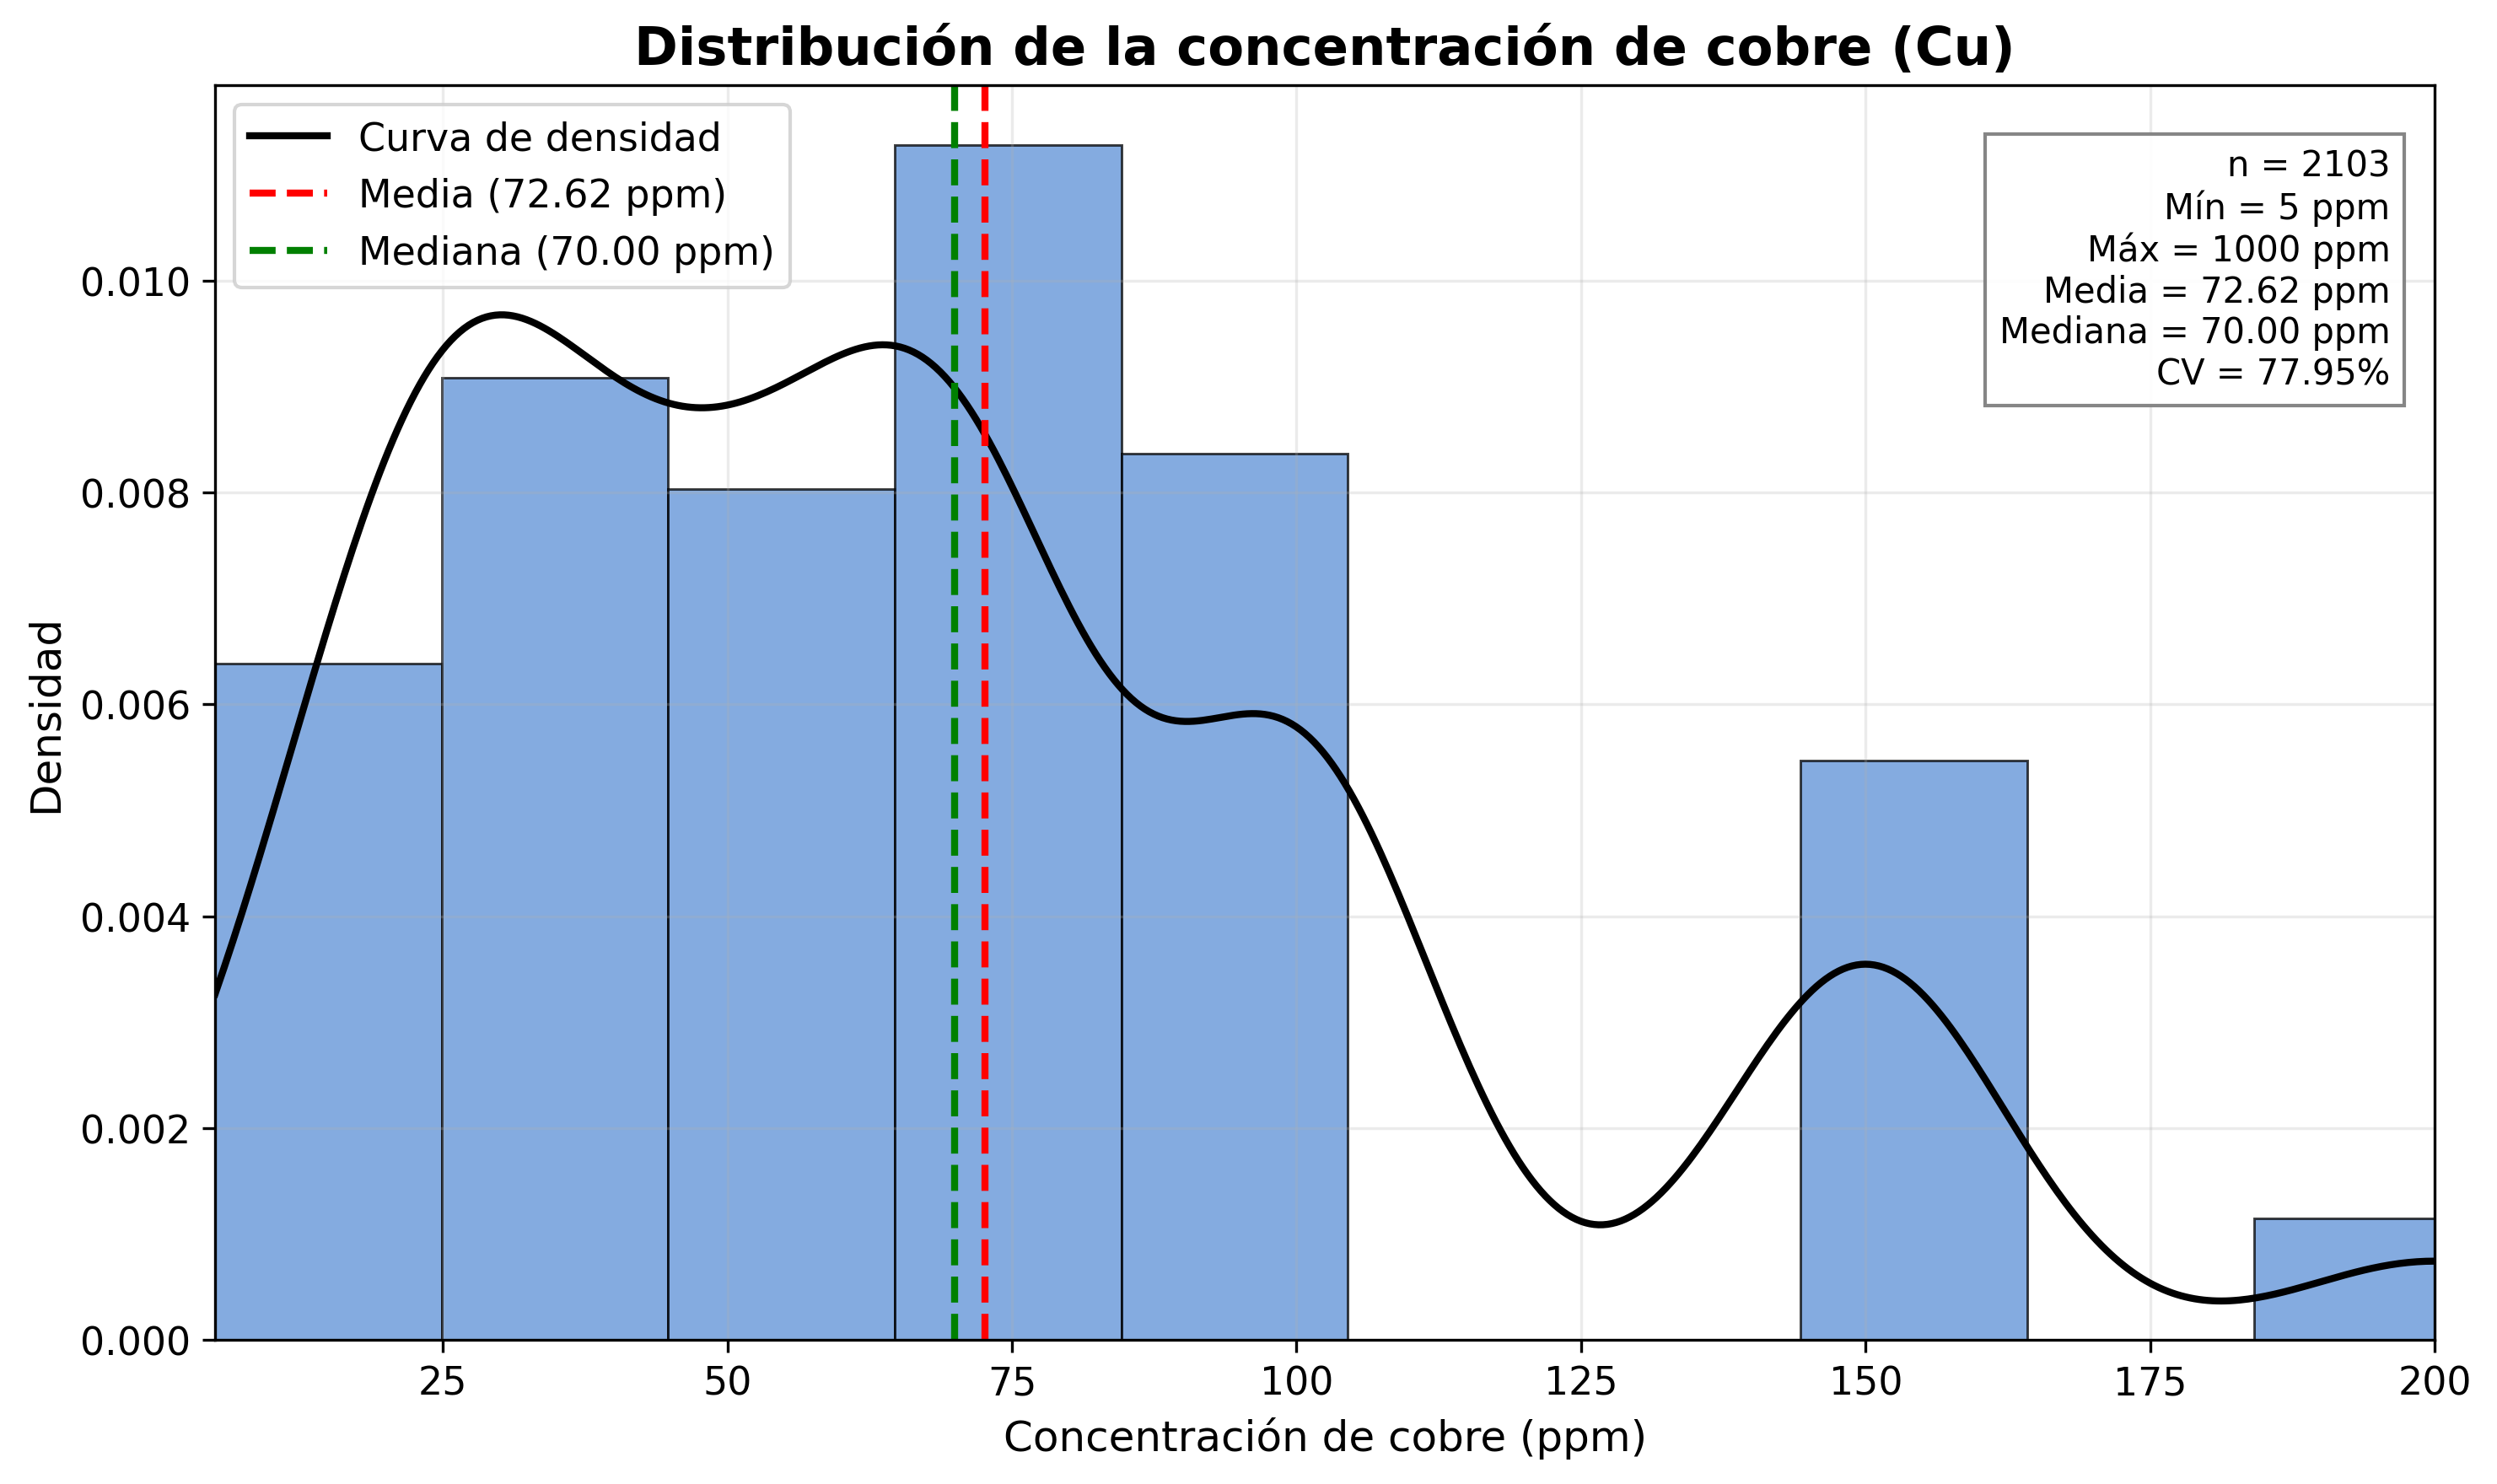

El gráfico muestra los datos hasta el percentil 99 (200 ppm).
El valor máximo real de la base es 1000 ppm.


In [31]:
# ==========================================================
# Figura 1. Histograma de la concentración de cobre
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Variable de trabajo
cu = muestras["Cu"].dropna()

# Estadísticos
n = len(cu)
media = cu.mean()
mediana = cu.median()
desviacion = cu.std()
cv = (desviacion / media) * 100

valor_min = cu.min()
valor_max = cu.max()

# Percentil 99 para mejorar la visualización
p99 = cu.quantile(0.99)

# Regla de Freedman-Diaconis
q1 = cu.quantile(0.25)
q3 = cu.quantile(0.75)
iqr = q3 - q1

ancho = 2 * iqr / np.cbrt(n)

if ancho > 0:
    bins = int(np.ceil((cu.max() - cu.min()) / ancho))
else:
    bins = 20

bins = max(10, min(bins, 50))

# ==========================================================
# Figura
# ==========================================================

fig, ax = plt.subplots(figsize=(10,6))

# Histograma
ax.hist(
    cu,
    bins=bins,
    density=True,
    color="#5B8FD6",
    edgecolor="black",
    linewidth=0.7,
    alpha=0.75
)

# Curva KDE
x = np.linspace(cu.min(), p99, 500)
kde = gaussian_kde(cu)

ax.plot(
    x,
    kde(x),
    color="black",
    linewidth=2,
    label="Curva de densidad"
)

# Media
ax.axvline(
    media,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media ({media:.2f} ppm)"
)

# Mediana
ax.axvline(
    mediana,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Mediana ({mediana:.2f} ppm)"
)

# Cuadro de estadísticas
texto = (
    f"n = {n}\n"
    f"Mín = {valor_min:.0f} ppm\n"
    f"Máx = {valor_max:.0f} ppm\n"
    f"Media = {media:.2f} ppm\n"
    f"Mediana = {mediana:.2f} ppm\n"
    f"CV = {cv:.2f}%"
)

ax.text(
    0.98,
    0.95,
    texto,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

# Configuración
ax.set_xlim(cu.min(), p99)

ax.set_xlabel("Concentración de cobre (ppm)", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)

# Quitamos "Figura 1" del título
ax.set_title(
    "Distribución de la concentración de cobre (Cu)",
    fontsize=15,
    fontweight="bold"
)

ax.grid(alpha=0.25)

# Leyenda más limpia
ax.legend(
    loc="upper left",
    frameon=True
)

plt.tight_layout()

plt.savefig(
    FIGURAS / "Figura_01_Histograma_Cu.png",
    dpi=300,
    bbox_inches="tight"

)

plt.show()

print(f"El gráfico muestra los datos hasta el percentil 99 ({p99:.0f} ppm).")
print(f"El valor máximo real de la base es {valor_max:.0f} ppm.")

**Figura 1.** Histograma de la concentración de cobre (Cu). El eje X se limita al percentil 99 (200 ppm) para facilitar la visualización, aunque el valor máximo de la base de datos es de 1000 ppm.

La distribución de las concentraciones de cobre presenta una marcada asimetría positiva, con la mayoría de las observaciones concentradas entre aproximadamente 25 y 105 ppm y un número reducido de valores altos. Este comportamiento es consistente con el coeficiente de variación (77.95 %), la asimetría (4.19) y la curtosis (49.23), lo que indica una distribución alejada de la normalidad y la presencia de valores extremos.

## 2.4 Gráfico Q-Q (Normal Q-Q Plot)

El gráfico Q-Q (Quantile-Quantile) permite comparar la distribución observada de la concentración de cobre con una distribución normal teórica. Si los datos siguen una distribución normal, los puntos se alinearán aproximadamente sobre una línea recta. Desviaciones importantes de esta línea indican la presencia de asimetrías, colas largas o valores atípicos.

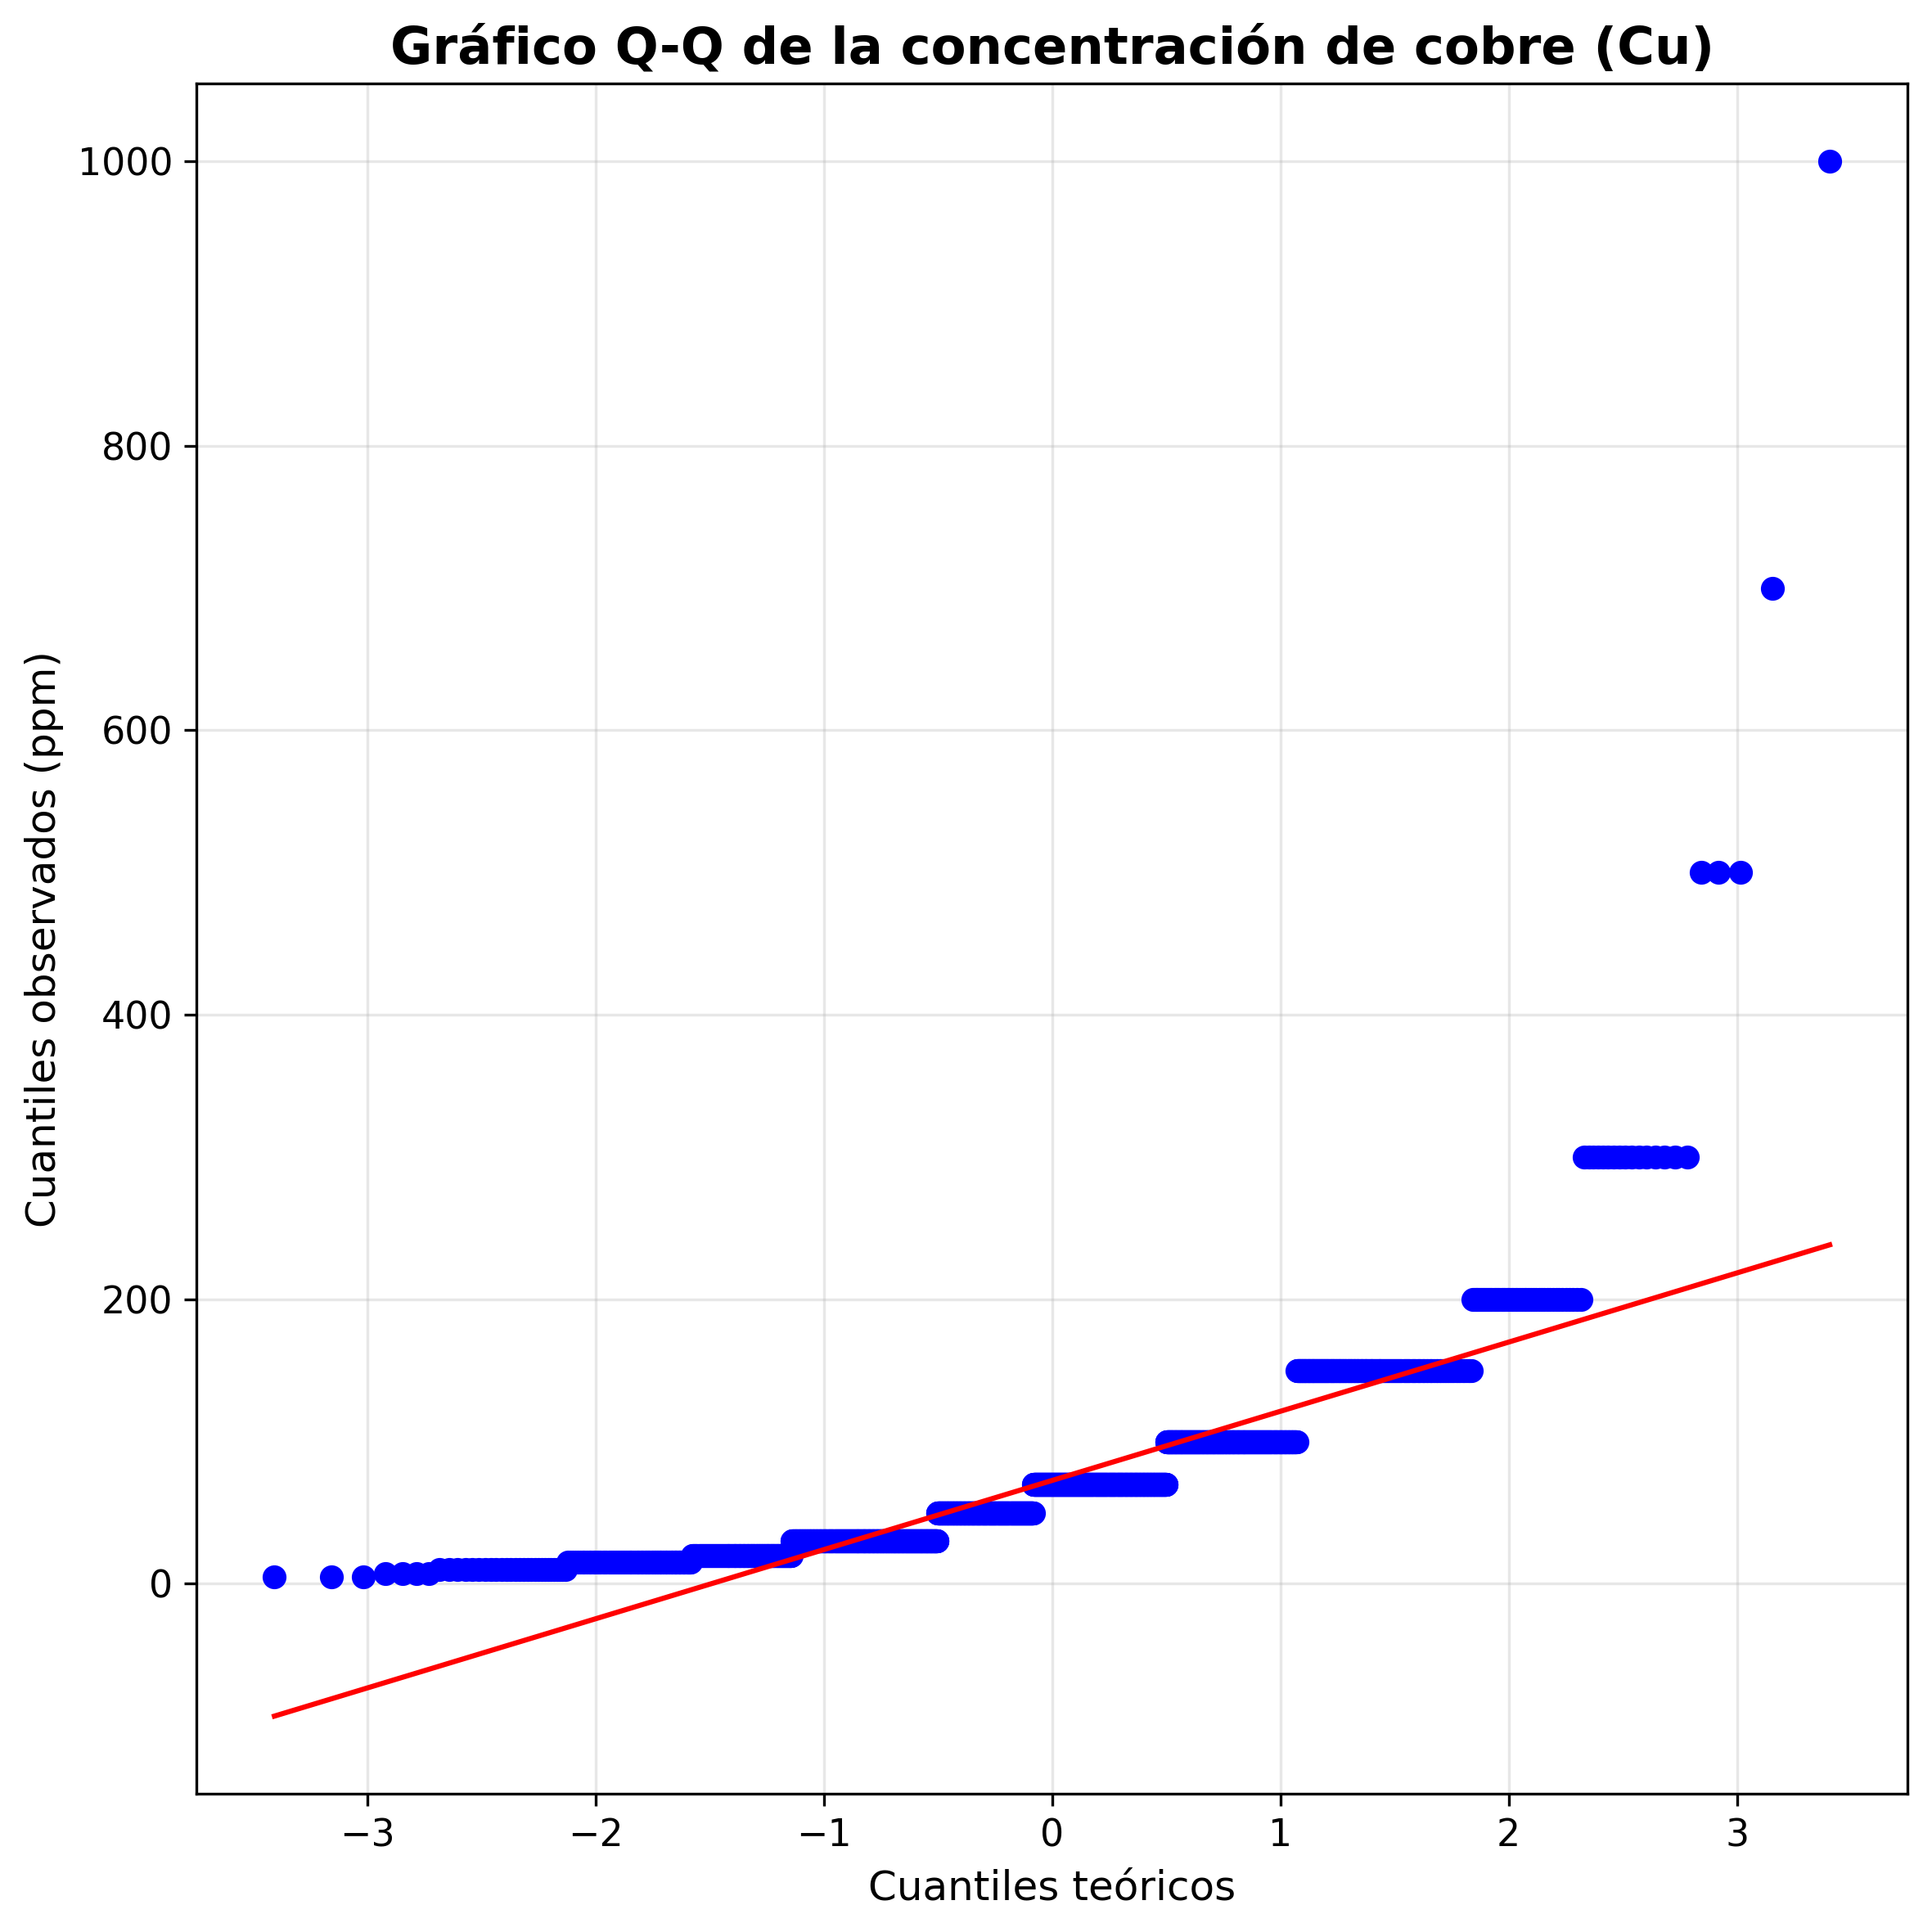

In [38]:
# ==========================================================
# Figura 2. QQ Plot de la concentración de cobre
# ==========================================================

import matplotlib.pyplot as plt
from scipy import stats

# Variable
cu = muestras["Cu"]

# Crear figura
fig, ax = plt.subplots(figsize=(8,8))

# QQ Plot
stats.probplot(cu, dist="norm", plot=ax)

# Mejorar apariencia
ax.set_title(
    "Gráfico Q-Q de la concentración de cobre (Cu)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Cuantiles teóricos", fontsize=12)
ax.set_ylabel("Cuantiles observados (ppm)", fontsize=12)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURAS / "Figura_02_QQPlot_Cu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figura 2.** Gráfico Q-Q de la concentración de cobre (Cu). La separación de los puntos respecto a la línea de referencia evidencia una desviación importante de la normalidad.

El gráfico muestra que los datos se ajustan razonablemente a la línea de referencia en la zona central, pero presentan desviaciones marcadas en los extremos, especialmente en los valores altos. Este comportamiento confirma la asimetría positiva y la presencia de valores extremos identificadas previamente.

## 2.5 Prueba de normalidad

Además de la evaluación visual mediante el histograma y el gráfico Q-Q, se aplica la prueba de Anderson-Darling para determinar estadísticamente si la concentración de cobre (Cu) sigue una distribución normal. Esta prueba compara la distribución observada con una distribución normal teórica y permite establecer si las diferencias observadas son estadísticamente significativas.

In [39]:
# ==========================================================
# Tabla 3. Prueba de normalidad Anderson-Darling
# ==========================================================

from scipy.stats import anderson
import pandas as pd

# Ejecutar prueba
resultado = anderson(cu, dist='norm')

# Crear tabla
tabla_anderson = pd.DataFrame({
    "Nivel de significancia (%)": resultado.significance_level,
    "Valor crítico": resultado.critical_values
})

print(f"Estadístico Anderson-Darling = {resultado.statistic:.3f}")

display(tabla_anderson.round(3))

Estadístico Anderson-Darling = 91.041


,Nivel de significancia (%),Valor crítico
0,15.0,0.575
1,10.0,0.655
2,5.0,0.786
3,2.5,0.916
4,1.0,1.090


In [40]:
# Guardar resultados de la prueba Anderson-Darling
tabla_anderson.round(3).to_csv(
    RESULTADOS / "Tabla_03_Prueba_Anderson_Darling.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla guardada correctamente.")

Tabla guardada correctamente.


**Tabla 3.** Resultados de la prueba de normalidad de Anderson-Darling para la concentración de cobre (Cu).

La prueba de Anderson-Darling produjo un estadístico de 91.041, valor superior a los valores críticos para todos los niveles de significancia evaluados. En consecuencia, se rechaza la hipótesis nula de normalidad, indicando que la concentración de cobre no sigue una distribución normal.

Este resultado es consistente con el histograma y el gráfico Q-Q, donde se evidenció una marcada asimetría positiva y la presencia de valores extremos. Por tanto, la variable Cu presenta un comportamiento no normal, condición frecuente en bases de datos geoquímicas

## 2.6 Diagrama de caja (Boxplot)

El diagrama de caja permite identificar la dispersión de los datos, los cuartiles y la presencia de posibles valores atípicos en la concentración de cobre (Cu). En geoestadística, este análisis es importante porque permite reconocer anomalías que posteriormente deberán evaluarse en función de su contexto espacial antes de decidir si deben conservarse o transformarse.

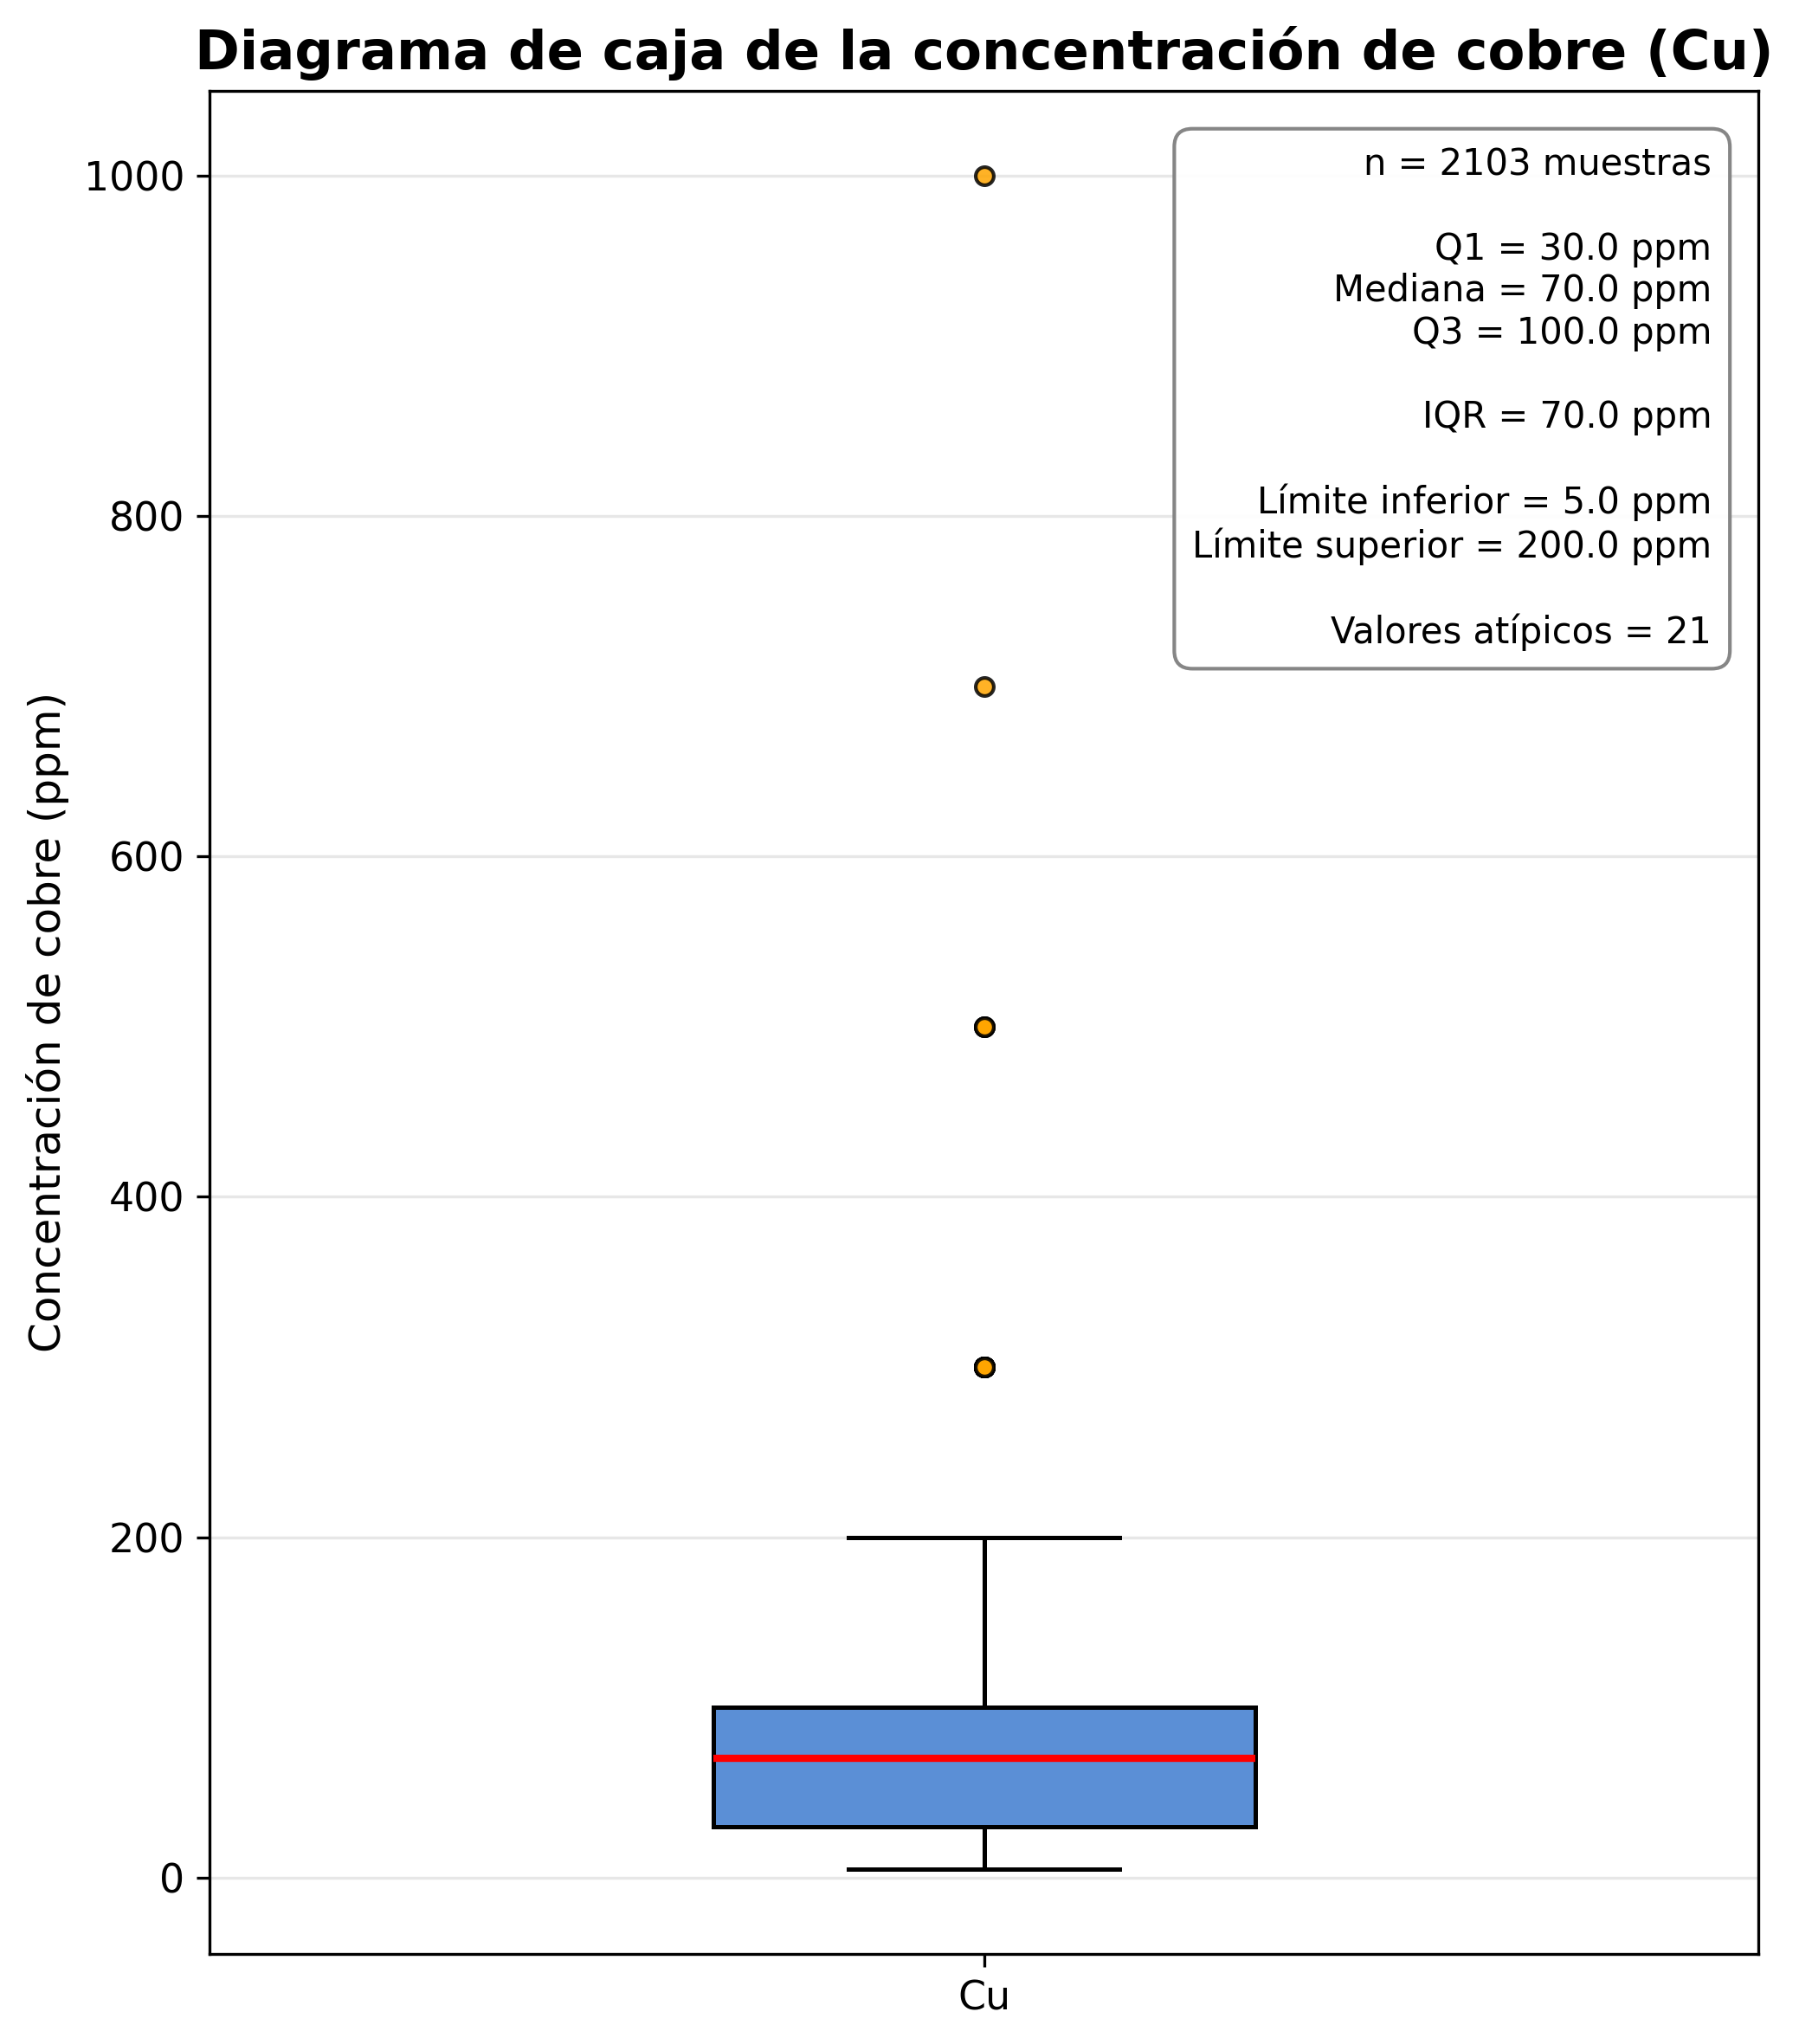

Figura guardada correctamente.
Valores atípicos identificados: 21 (1.0%)


,Estadístico,Valor
0,Número de muestras,2103.0
1,Q1,30.0
2,Mediana,70.0
3,Q3,100.0
4,Rango intercuartílico (IQR),70.0
5,Límite inferior real,5.0
6,Límite superior real,200.0
7,Valores atípicos,21.0
8,Porcentaje de valores atípicos,1.0


Tabla guardada correctamente.


In [41]:
# ============================================================
# Figura 3. Diagrama de caja de la concentración de cobre (Cu)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Variable de trabajo
# ------------------------------------------------------------

cu = muestras["Cu"].dropna()

# ------------------------------------------------------------
# Estadísticos del boxplot
# ------------------------------------------------------------

n = len(cu)

Q1 = cu.quantile(0.25)
Mediana = cu.median()
Q3 = cu.quantile(0.75)

IQR = Q3 - Q1

# Límites teóricos para identificar valores atípicos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Límites reales representados por los bigotes del boxplot
limite_inf_real = cu[cu >= limite_inferior].min()
limite_sup_real = cu[cu <= limite_superior].max()

# Valores atípicos
outliers = cu[
    (cu < limite_inferior) |
    (cu > limite_superior)
]

porcentaje_outliers = len(outliers) / n * 100

# ------------------------------------------------------------
# Crear figura
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 8))

ax.boxplot(
    cu,
    vert=True,
    patch_artist=True,
    widths=0.35,

    boxprops=dict(
        facecolor="#5B8FD6",
        edgecolor="black",
        linewidth=1.2
    ),

    medianprops=dict(
        color="red",
        linewidth=2
    ),

    whiskerprops=dict(
        color="black",
        linewidth=1.2
    ),

    capprops=dict(
        color="black",
        linewidth=1.2
    ),

    flierprops=dict(
        marker="o",
        markerfacecolor="orange",
        markeredgecolor="black",
        markersize=5,
        alpha=0.85
    )
)

# ------------------------------------------------------------
# Título y ejes
# ------------------------------------------------------------

ax.set_title(
    "Diagrama de caja de la concentración de cobre (Cu)",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel(
    "Concentración de cobre (ppm)",
    fontsize=12
)

ax.set_xticks([1])
ax.set_xticklabels(["Cu"])

# ------------------------------------------------------------
# Cuadro informativo
# ------------------------------------------------------------

texto = (
    f"n = {n} muestras\n\n"
    f"Q1 = {Q1:.1f} ppm\n"
    f"Mediana = {Mediana:.1f} ppm\n"
    f"Q3 = {Q3:.1f} ppm\n\n"
    f"IQR = {IQR:.1f} ppm\n\n"
    f"Límite inferior = {limite_inf_real:.1f} ppm\n"
    f"Límite superior = {limite_sup_real:.1f} ppm\n\n"
    f"Valores atípicos = {len(outliers)}"
)

ax.text(
    0.97,
    0.97,
    texto,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round,pad=0.5",
        alpha=0.95
    )
)

# ------------------------------------------------------------
# Cuadrícula
# ------------------------------------------------------------

ax.grid(
    axis="y",
    alpha=0.30
)

# ------------------------------------------------------------
# Guardar y mostrar figura
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    FIGURAS / "Figura_03_Boxplot_Cu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente.")
print(
    f"Valores atípicos identificados: "
    f"{len(outliers)} ({porcentaje_outliers:.1f}%)"
)

# ------------------------------------------------------------
# Tabla resumen del boxplot
# ------------------------------------------------------------

tabla_boxplot = pd.DataFrame({
    "Estadístico": [
        "Número de muestras",
        "Q1",
        "Mediana",
        "Q3",
        "Rango intercuartílico (IQR)",
        "Límite inferior real",
        "Límite superior real",
        "Valores atípicos",
        "Porcentaje de valores atípicos"
    ],
    "Valor": [
        n,
        round(Q1, 2),
        round(Mediana, 2),
        round(Q3, 2),
        round(IQR, 2),
        round(limite_inf_real, 2),
        round(limite_sup_real, 2),
        len(outliers),
        round(porcentaje_outliers, 2)
    ]
})

display(tabla_boxplot)

tabla_boxplot.to_csv(
    RESULTADOS / "Tabla_04_Boxplot.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla guardada correctamente.")

In [42]:
tabla_boxplot = pd.DataFrame({
    "Estadístico":[
        "Número de muestras",
        "Q1",
        "Mediana",
        "Q3",
        "Rango intercuartílico (IQR)",
        "Límite inferior",
        "Límite superior",
        "Valores atípicos"
    ],
    "Valor":[
        n,
        round(Q1,2),
        round(Mediana,2),
        round(Q3,2),
        round(IQR,2),
        round(limite_inf_real,2),
        round(limite_sup_real,2),
        len(outliers)
    ]
})

display(tabla_boxplot)

tabla_boxplot.to_csv(
    RESULTADOS / "Tabla_04_Boxplot.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla guardada correctamente.")

,Estadístico,Valor
0,Número de muestras,2103.0
1,Q1,30.0
2,Mediana,70.0
3,Q3,100.0
4,Rango intercuartílico (IQR),70.0
5,Límite inferior,5.0
6,Límite superior,200.0
7,Valores atípicos,21.0


Tabla guardada correctamente.


**Figura 3.** Diagrama de caja de la concentración de cobre (Cu).

El diagrama de caja muestra que la mayor parte de las concentraciones de cobre se concentra entre aproximadamente 30 y 100 ppm, con una mediana de 70 ppm. Se identificaron 21 valores atípicos por encima del límite superior del rango intercuartílico, confirmando la presencia de concentraciones excepcionalmente altas y el comportamiento no normal de la distribución.

# 3. Exploración espacial

La exploración espacial tiene como propósito analizar la distribución geográfica de las muestras de cobre y su relación con los principales elementos geológicos del área de estudio. Esta etapa permite identificar patrones espaciales, tendencias y posibles controles geológicos o estructurales que servirán como base para el análisis geoestadístico y la interpolación mediante kriging.


#3.1. Configuración cartográfica


- Configuración general:

In [43]:
# ==========================================================
# Configuración cartográfica del proyecto
# ==========================================================

# Tamaño por defecto de las figuras
plt.rcParams["figure.figsize"] = (10, 8)

# Resolución
plt.rcParams["figure.dpi"] = 300

# Tamaño de letra
plt.rcParams["font.size"] = 11

# Títulos
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"

# Etiquetas
plt.rcParams["axes.labelsize"] = 12

# Fondo blanco
plt.rcParams["figure.facecolor"] = "white"

print("Configuración cartográfica cargada correctamente.")

Configuración cartográfica cargada correctamente.


En esta sección se establecen los parámetros cartográficos utilizados en todas las figuras del análisis espacial, incluyendo tamaño de la figura, resolución, tipografía y formato general. Esta configuración garantiza uniformidad en la presentación de los mapas y facilita su interpretación.

- Funciones cartográficas auxiliares




In [44]:
# ============================================================
# Funciones cartográficas auxiliares
# ============================================================

def guardar_figura(nombre):
    """
    Guarda la figura en la carpeta de resultados con resolución de 300 dpi.
    """
    plt.savefig(
        FIGURAS / nombre,
        dpi=300,
        bbox_inches="tight"
    )

## 3.2 Localización del área de estudio

En esta sección se presenta la ubicación del área de estudio correspondiente al suroeste del departamento de Antioquia. El mapa muestra los municipios que conforman el área de análisis y sirve como referencia espacial para la interpretación de los resultados obtenidos en las etapas posteriores del estudio.

In [45]:
# ==========================================================
# Figura 4. Localización del área de estudio
# ==========================================================

import matplotlib.pyplot as plt
import contextily as ctx

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ----------------------------------------------------------
# 1. Preparar la capa
# ----------------------------------------------------------

municipios_mapa = municipios.copy()

municipios_mapa = municipios_mapa[
    municipios_mapa.geometry.notna()
    & ~municipios_mapa.geometry.is_empty
].copy()

municipios_mapa["geometry"] = municipios_mapa.geometry.make_valid()

# Unir los municipios para obtener el límite exterior
limite_estudio = municipios_mapa.dissolve()

# ----------------------------------------------------------
# 2. Corregir nombres abreviados
# ----------------------------------------------------------

nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_mapa["NOMBRE_MAPA"] = (
    municipios_mapa["NOMBRE"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(nombres_corregidos)
)

municipios_mapa["NOMBRE_MAPA"] = municipios_mapa["NOMBRE_MAPA"].apply(
    lambda nombre: nombre.title()
    if nombre == nombre.upper()
    else nombre
)

# ----------------------------------------------------------
# 3. Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

# Dibujar primero los municipios para establecer la extensión
municipios_mapa.plot(
    ax=ax,
    facecolor="#E6E6E6",
    edgecolor="#666666",
    linewidth=0.8,
    alpha=0.70,
    zorder=2
)

# Guardar extensión espacial
xmin, ymin, xmax, ymax = municipios_mapa.total_bounds

margen_x = (xmax - xmin) * 0.05
margen_y = (ymax - ymin) * 0.05

ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Agregar mapa base después de fijar la extensión
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=municipios_mapa.crs,
    zoom=9,
    attribution=False
)

# Restablecer extensión después de añadir el mapa base
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Límite exterior
limite_estudio.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2,
    zorder=3
)

# ----------------------------------------------------------
# 4. Etiquetas municipales
# ----------------------------------------------------------

for _, fila in municipios_mapa.iterrows():

    punto = fila.geometry.representative_point()

    ax.text(
        punto.x,
        punto.y,
        fila["NOMBRE_MAPA"],
        fontsize=7,
        ha="center",
        va="center",
        color="black",
        zorder=4
    )

# ----------------------------------------------------------
# 5. Flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.94, 0.92),
    xytext=(0.94, 0.81),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=4,
        headwidth=12
    ),
    zorder=5
)

# ----------------------------------------------------------
# 6. Escala gráfica
# ----------------------------------------------------------

escala = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.20,
    box_alpha=0.85,
    scale_loc="bottom",
    font_properties={"size": 9}
)

ax.add_artist(escala)

# ----------------------------------------------------------
# 7. Leyenda
# ----------------------------------------------------------

elementos_leyenda = [
    Patch(
        facecolor="#E6E6E6",
        edgecolor="#666666",
        label="Municipios"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.2,
        label="Límite del área de estudio"
    )
]

ax.legend(
    handles=elementos_leyenda,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.95
)

# ----------------------------------------------------------
# 8. Título, ejes y fuente
# ----------------------------------------------------------

ax.set_title(
    "Localización del área de estudio",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Coordenada Este (m)")
ax.set_ylabel("Coordenada Norte (m)")

ax.text(
    0.99,
    0.012,
    "Sistema de referencia\nEPSG:21897",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95
    ),
    zorder=10
)

fig.text(
    0.98,
    0.015,
    "Fuente: cartografía municipal y elaboración propia.",
    ha="right",
    va="bottom",
    fontsize=8
)

# Marco
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

plt.tight_layout(rect=[0, 0.035, 1, 1])

# ----------------------------------------------------------
# 9. Guardar y mostrar
# ----------------------------------------------------------

guardar_figura("Figura_04_Localizacion_Area_Estudio.png"
)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Figura 4.** Localización del área de estudio, conformada por los municipios del Suroeste antioqueño.

## 3.2 Distribución espacial de las muestras de cobre

En esta sección se representa la ubicación de las muestras geoquímicas dentro del área de estudio. Los puntos se simbolizan según la concentración de cobre (Cu), lo que permite identificar visualmente zonas con valores bajos, medios y altos, así como posibles agrupamientos espaciales.

In [46]:
# ==========================================================
# Figura 5. Distribución espacial de las muestras de cobre
# ==========================================================

import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# Copias de trabajo
municipios_mapa = municipios.copy()
muestras_mapa = muestras.copy()

# Eliminar geometrías nulas o vacías
municipios_mapa = municipios_mapa[
    municipios_mapa.geometry.notna()
    & ~municipios_mapa.geometry.is_empty
].copy()

muestras_mapa = muestras_mapa[
    muestras_mapa.geometry.notna()
    & ~muestras_mapa.geometry.is_empty
].copy()

# Reparar geometrías
municipios_mapa["geometry"] = municipios_mapa.geometry.make_valid()
muestras_mapa["geometry"] = muestras_mapa.geometry.make_valid()

# Crear límite exterior
limite_estudio = municipios_mapa.dissolve()

# Extensión espacial
xmin, ymin, xmax, ymax = municipios_mapa.total_bounds

margen_x = (xmax - xmin) * 0.05
margen_y = (ymax - ymin) * 0.05

# Crear figura
fig, ax = plt.subplots(figsize=(10, 10))

# Municipios
municipios_mapa.plot(
    ax=ax,
    facecolor="#E6E6E6",
    edgecolor="#777777",
    linewidth=0.7,
    alpha=0.60,
    zorder=2
)

# Fijar extensión
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Mapa base
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=municipios_mapa.crs,
    zoom=9,
    attribution=False,
    alpha=0.75,
    zorder=1
)

# Restablecer extensión
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Muestras de cobre
muestras_mapa.plot(
    ax=ax,
    column="Cu",
    cmap="viridis",
    markersize=18,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    legend_kwds={
        "label": "Concentración de cobre (ppm)",
        "shrink": 0.65
    },
    zorder=4
)

# Límite exterior
limite_estudio.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2,
    zorder=5
)

# Etiquetas municipales
for _, fila in municipios_mapa.iterrows():
    punto = fila.geometry.representative_point()

    ax.text(
        punto.x,
        punto.y,
        str(fila["NOMBRE"]).title(),
        fontsize=6.5,
        ha="center",
        va="center",
        color="black",
        zorder=6
    )

# Flecha norte
ax.annotate(
    "N",
    xy=(0.94, 0.89),
    xytext=(0.94, 0.79),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=4,
        headwidth=12
    ),
    zorder=7
)

# Escala
escala = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.28,      # ligeramente más larga
    width_fraction=0.02,       # barra más gruesa
    box_alpha=1.0,             # fondo completamente blanco
    box_color="white",
    color="black",
    scale_loc="bottom",
    font_properties={"size": 10}
)

ax.add_artist(escala)

# Título y ejes
ax.set_title(
    "Distribución espacial de las muestras de cobre",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Coordenada Este (m)")
ax.set_ylabel("Coordenada Norte (m)")

# CRS
ax.text(
    0.99,
    0.012,
    "Sistema de referencia\nEPSG:21897",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95
    ),
    zorder=10
)

# Fuente
fig.text(
    0.98,
    0.015,
    "Fuente: base geoquímica de Cu, cartografía municipal y elaboración propia.",
    ha="right",
    va="bottom",
    fontsize=8
)

# Marco
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

plt.tight_layout(rect=[0, 0.035, 1, 1])

# Guardar

guardar_figura("Figura_05_Distribución_espacial_de_las_muestras_geoquímicas_de_cobre.png"
)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Figura 5.** Distribución espacial de las 2103 muestras geoquímicas de cobre



### 3.3 Verificación de la cobertura espacial

Antes de iniciar el análisis geoestadístico, se verificó la ubicación espacial de todas las muestras respecto al límite del área de estudio. Este procedimiento permitió identificar las observaciones localizadas fuera del dominio espacial definido y separarlas de la base de datos que será utilizada en el cálculo del variograma y la interpolación mediante kriging.

In [47]:
# ==========================================================
# Verificación de muestras dentro del área de estudio
# ==========================================================

# Crear el límite del área de estudio
limite = municipios.dissolve()

# Verificar si cada muestra está dentro del límite
muestras["Dentro_area"] = muestras.within(limite.geometry.iloc[0])

# Contar resultados
dentro = muestras["Dentro_area"].sum()
fuera = len(muestras) - dentro

print(f"Muestras totales : {len(muestras)}")
print(f"Dentro del área : {dentro}")
print(f"Fuera del área  : {fuera}")
print(f"Porcentaje fuera: {fuera/len(muestras)*100:.2f}%")

Muestras totales : 2103
Dentro del área : 2029
Fuera del área  : 74
Porcentaje fuera: 3.52%


Se verificó la ubicación espacial de todas las muestras respecto al límite del área de estudio.

In [48]:
# ==========================================================
# Selección de muestras dentro del área de estudio
# ==========================================================

# Crear un único polígono con el límite de los municipios
limite_area = municipios.dissolve().geometry.iloc[0]

# Seleccionar muestras dentro o sobre el límite
muestras_estudio = muestras[
    muestras.geometry.intersects(limite_area)
].copy()

# Muestras localizadas fuera del área
muestras_fuera = muestras[
    ~muestras.geometry.intersects(limite_area)
].copy()

# Resumen
total = len(muestras)
dentro = len(muestras_estudio)
fuera = len(muestras_fuera)
porcentaje_fuera = (fuera / total) * 100

print(f"Muestras totales: {total}")
print(f"Muestras dentro del área: {dentro}")
print(f"Muestras fuera del área: {fuera}")
print(f"Porcentaje excluido: {porcentaje_fuera:.2f}%")

Muestras totales: 2103
Muestras dentro del área: 2029
Muestras fuera del área: 74
Porcentaje excluido: 3.52%


In [49]:
# Guardar la capa definitiva para el análisis
muestras_estudio.to_file(
    ESTUDIO / "Muestras_Cu_Area_Estudio.gpkg",
    layer="Muestras_Cu_Area_Estudio",
    driver="GPKG"
)

# Guardar las muestras excluidas para trazabilidad
muestras_fuera.to_file(
    ESTUDIO / "Muestras_Cu_Fuera_Area.gpkg",
    layer="Muestras_Cu_Fuera_Area",
    driver="GPKG"
)

print("Capas guardadas correctamente en Google Drive.")

Capas guardadas correctamente en Google Drive.


In [50]:
muestras_estudio

,Y,X,Cu,geometry,Dentro_area
0,1103800.0,824800.0,50,POINT (824800 1103800),True
1,1104800.0,825350.0,20,POINT (825350 1104800),True
2,1105300.0,825800.0,20,POINT (825800 1105300),True
3,1108200.0,827500.0,15,POINT (827500 1108200),True
4,1108600.0,827300.0,100,POINT (827300 1108600),True
...,...,...,...,...,...
2098,1207550.0,728963.0,30,POINT (728963 1207550),True
2099,1206100.0,729555.0,20,POINT (729555 1206100),True
2100,1205850.0,729754.0,30,POINT (729754 1205850),True
2101,1205500.0,729351.0,30,POINT (729351 1205500),True


In [51]:
# ==========================================================
# Tabla 5. Distribución de las muestras respecto al área de estudio
# ==========================================================

import pandas as pd

tabla_cobertura = pd.DataFrame({
    "Estado de las muestras": [
        "Dentro del área de estudio",
        "Fuera del área de estudio",
        "Total"
    ],
    "Cantidad": [
        dentro,
        fuera,
        total
    ],
    "Porcentaje (%)": [
        round(dentro/total*100,2),
        round(fuera/total*100,2),
        100.00
    ]
})

display(tabla_cobertura)

,Estado de las muestras,Cantidad,Porcentaje (%)
0,Dentro del área de estudio,2029,96.48
1,Fuera del área de estudio,74,3.52
2,Total,2103,100.00


In [52]:
# ==========================================================
# Guardar Tabla 5. Distribución de las muestras
# ==========================================================

tabla_cobertura.to_csv(
    RESULTADOS / "Tabla_05_Distribucion_Muestras_Area_Estudio.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla guardada correctamente.")

Tabla guardada correctamente.


**Tabla 5.** Distribución de las muestras geoquímicas respecto al límite del área de estudio.

De las 2103 muestras disponibles, 2029 (96.48%) se localizaron dentro del límite del área de estudio y fueron seleccionadas para los análisis geoestadísticos posteriores. Las 74 muestras restantes (3.52%), ubicadas fuera del dominio espacial definido, fueron excluidas de la interpolación y almacenadas en una capa independiente para mantener la trazabilidad del procesamiento.

In [53]:
muestras_originales = muestras.copy()
muestras = muestras_estudio.copy()

In [54]:
# ==========================================================
# Figura 6. Verificación de la cobertura espacial
# ==========================================================

import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# Copias de trabajo
municipios_mapa = municipios.copy()
muestras_dentro_mapa = muestras_estudio.copy()
muestras_fuera_mapa = muestras_fuera.copy()

# Limpiar geometrías municipales
municipios_mapa = municipios_mapa[
    municipios_mapa.geometry.notna()
    & ~municipios_mapa.geometry.is_empty
].copy()

municipios_mapa["geometry"] = municipios_mapa.geometry.make_valid()

# Límite exterior
limite_estudio = municipios_mapa.dissolve()

# Extensión del mapa
xmin, ymin, xmax, ymax = municipios_mapa.total_bounds
margen_x = (xmax - xmin) * 0.05
margen_y = (ymax - ymin) * 0.05

# Crear figura
fig, ax = plt.subplots(figsize=(10, 10))

# Municipios
municipios_mapa.plot(
    ax=ax,
    facecolor="#E6E6E6",
    edgecolor="#777777",
    linewidth=0.7,
    alpha=0.60,
    zorder=2
)

# Fijar extensión
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Mapa base
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=municipios_mapa.crs,
    zoom=9,
    attribution=False,
    alpha=0.75,
    zorder=1
)

# Restaurar extensión
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Muestras dentro
muestras_dentro_mapa.plot(
    ax=ax,
    color="#2E86DE",
    markersize=13,
    edgecolor="black",
    linewidth=0.15,
    alpha=0.80,
    label="Dentro del área",
    zorder=4
)

# Muestras fuera
if len(muestras_fuera_mapa) > 0:
    muestras_fuera_mapa.plot(
        ax=ax,
        color="red",
        marker="x",
        markersize=50,
        linewidth=1.5,
        label="Fuera del área",
        zorder=5
    )

# Límite exterior
limite_estudio.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2,
    zorder=6
)

# Flecha norte
ax.annotate(
    "N",
    xy=(0.94, 0.89),
    xytext=(0.94, 0.79),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=4,
        headwidth=12
    ),
    zorder=7
)

# Escala gráfica
escala = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.20,
    box_alpha=1,
    box_color="white",
    color="black",
    scale_loc="bottom",
    font_properties={"size": 9}
)

ax.add_artist(escala)

# Sistema de referencia
ax.text(
    0.99,
    0.012,
    "Sistema de referencia\nEPSG:21897",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.95
    ),
    zorder=8
)

# Título y ejes
ax.set_title(
    "Verificación de la cobertura espacial de las muestras",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Coordenada Este (m)")
ax.set_ylabel("Coordenada Norte (m)")

# Leyenda
ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.88, 0.98),   # deja espacio para la flecha norte
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.95,
    fontsize=10,
    title="Clasificación",
    title_fontsize=10
)

# Fuente
fig.text(
    0.98,
    0.015,
    "Fuente: base geoquímica de Cu, cartografía municipal y elaboración propia.",
    ha="right",
    va="bottom",
    fontsize=8
)

# Marco
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

plt.tight_layout(rect=[0, 0.035, 1, 1])

# Guardar
guardar_figura("Figura_06_Verificacion_Cobertura.png")

plt.show(
)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Figura 6.** verificación y exclusión de 74 muestras fuera del area de interes.


La verificación espacial permitió confirmar que la mayoría de las observaciones se localiza dentro del límite definido para el estudio. Las muestras excluidas corresponden principalmente a puntos ubicados sobre los bordes del área o completamente fuera del dominio cartográfico, por lo que fueron retiradas antes del análisis geoestadístico para evitar extrapolaciones durante la interpolación mediante kriging.

In [55]:
# ======================================================================
# Figura 7. Distribución espacial de las muestras de cobre discretizadas
# ======================================================================

import matplotlib.pyplot as plt
import contextily as ctx

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ----------------------------------------------------------
# 1. Preparar las capas
# ----------------------------------------------------------

municipios_mapa = municipios.copy()
muestras_mapa = muestras_estudio.copy()

municipios_mapa = municipios_mapa[
    municipios_mapa.geometry.notna()
    & ~municipios_mapa.geometry.is_empty
].copy()

muestras_mapa = muestras_mapa[
    muestras_mapa.geometry.notna()
    & ~muestras_mapa.geometry.is_empty
].copy()

municipios_mapa["geometry"] = municipios_mapa.geometry.make_valid()
muestras_mapa["geometry"] = muestras_mapa.geometry.make_valid()

# Unir los municipios para obtener el límite exterior
limite_estudio = municipios_mapa.dissolve()

# ----------------------------------------------------------
# 2. Corregir nombres abreviados
# ----------------------------------------------------------

nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_mapa["NOMBRE_MAPA"] = (
    municipios_mapa["NOMBRE"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(nombres_corregidos)
)

municipios_mapa["NOMBRE_MAPA"] = municipios_mapa["NOMBRE_MAPA"].apply(
    lambda nombre: nombre.title()
    if nombre == nombre.upper()
    else nombre
)

# ----------------------------------------------------------
# 3. Escala de color de las muestras
# ----------------------------------------------------------

# Se conserva el rango completo de Cu: 5–1000 ppm
valor_min = muestras_mapa["Cu"].min()
valor_max = muestras_mapa["Cu"].max()

normalizacion = Normalize(
    vmin=valor_min,
    vmax=valor_max
)

# ----------------------------------------------------------
# 4. Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

# Municipios
municipios_mapa.plot(
    ax=ax,
    facecolor="#E6E6E6",
    edgecolor="#666666",
    linewidth=0.8,
    alpha=0.70,
    zorder=2
)

# Extensión espacial
xmin, ymin, xmax, ymax = municipios_mapa.total_bounds

margen_x = (xmax - xmin) * 0.05
margen_y = (ymax - ymin) * 0.05

ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Mapa base
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=municipios_mapa.crs,
    zoom=9,
    attribution=False
)

# Restablecer extensión
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Muestras de cobre
muestras_mapa.plot(
    ax=ax,
    column="Cu",
    cmap="viridis",
    norm=normalizacion,
    markersize=18,
    edgecolor="black",
    linewidth=0.20,
    alpha=0.85,
    zorder=4
)

# Límite exterior
limite_estudio.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2,
    zorder=5
)

# ----------------------------------------------------------
# 5. Etiquetas municipales
# ----------------------------------------------------------

for _, fila in municipios_mapa.iterrows():

    punto = fila.geometry.representative_point()

    ax.text(
        punto.x,
        punto.y,
        fila["NOMBRE_MAPA"],
        fontsize=7,
        ha="center",
        va="center",
        color="black",
        zorder=6
    )

# ----------------------------------------------------------
# 6. Flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.94, 0.92),
    xytext=(0.94, 0.81),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=4,
        headwidth=12
    ),
    zorder=7
)

# ----------------------------------------------------------
# 7. Escala gráfica
# ----------------------------------------------------------

escala = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.20,
    box_alpha=0.85,
    scale_loc="bottom",
    font_properties={"size": 9}
)

ax.add_artist(escala)

# ----------------------------------------------------------
# 8. Leyenda y barra de colores
# ----------------------------------------------------------

elementos_leyenda = [
    Patch(
        facecolor="#E6E6E6",
        edgecolor="#666666",
        label="Municipios"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.2,
        label="Límite del área de estudio"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#440154",
        markeredgecolor="black",
        markersize=7,
        label="Muestras geoquímicas"
    )
]

ax.legend(
    handles=elementos_leyenda,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.95
)

# Barra de colores
mapeable = ScalarMappable(
    norm=normalizacion,
    cmap="viridis"
)

mapeable.set_array([])

barra_color = fig.colorbar(
    mapeable,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

barra_color.set_label(
    "Concentración de cobre (ppm)",
    fontsize=11
)

# ----------------------------------------------------------
# 9. Título, ejes y fuente
# ----------------------------------------------------------

ax.set_title(
    "Distribución espacial de las muestras de cobre",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Coordenada Este (m)")
ax.set_ylabel("Coordenada Norte (m)")

ax.text(
    0.99,
    0.012,
    "Sistema de referencia\nEPSG:21897",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95
    ),
    zorder=10
)

fig.text(
    0.98,
    0.015,
    "Fuente: base geoquímica de Cu, cartografía municipal y elaboración propia.",
    ha="right",
    va="bottom",
    fontsize=8
)

# Marco
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

plt.tight_layout(rect=[0, 0.035, 1, 1])

# ----------------------------------------------------------
# 10. Guardar y mostrar
# ----------------------------------------------------------

guardar_figura(
    "Figura_07_Distribucion_Espacial_Muestras_Cu_Discretizadas.png"
)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

Figura 7. Distribución espacial de las 2029 muestras definitivas utilizadas en el analisis.


### 3.4 Distribución de las muestras sobre las unidades geológicas
En esta sección se analiza la distribución espacial de las muestras geoquímicas de cobre respecto a las unidades geológicas presentes en el área de estudio. Para ello, se preparó y validó la cartografía geológica y posteriormente se asoció cada muestra con la unidad geológica correspondiente, proporcionando el contexto geológico para la interpretación de la distribución de las concentraciones de cobre.


3.4.1 Preparación y validación de la cartografía geológica

Como etapa previa al análisis, la cartografía geológica fue preparada y validada para garantizar la consistencia espacial de la información. Este proceso incluyó la corrección de geometrías inválidas, la eliminación de geometrías vacías, el recorte al área de estudio y la asociación espacial de las muestras con las unidades geológicas mediante una unión espacial (Spatial Join).

In [64]:
# 1. Cargar nuevamente la geología
geologia = gpd.read_file(
    PROCESADOS / "Geologia_Suroeste.gpkg"
)

print("Geología cargada:", len(geologia))

Geología cargada: 658


In [65]:
# 2. Crear nuevamente el límite del área de estudio
limite_area = municipios.dissolve().geometry.iloc[0]

print("Límite del área creado.")

Límite del área creado.


In [66]:
# 3. Preparar nuevamente la geología
geologia_mapa = geologia[
    geologia.geometry.notna()
    & ~geologia.geometry.is_empty
].copy()

geologia_mapa["geometry"] = (
    geologia_mapa.geometry.make_valid()
)

geologia_mapa = gpd.clip(
    geologia_mapa,
    limite_area
)

geologia_mapa = geologia_mapa[
    geologia_mapa.geometry.notna()
    & ~geologia_mapa.geometry.is_empty
].copy()

print(
    "Polígonos geológicos dentro del área:",
    len(geologia_mapa)
)

print(
    "Unidades geológicas dentro del área:",
    geologia_mapa["UNIDAD_DES"].nunique()
)

/tmp/ipykernel_306/1403595482.py:3: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  geologia.geometry.notna()


Polígonos geológicos dentro del área: 126
Unidades geológicas dentro del área: 36


In [57]:
# Preparación de la geología para el análisis espacial

In [67]:
# ==========================================================
# Asociación de cada muestra con su unidad geológica
# ==========================================================

muestras_geo = gpd.sjoin(
    muestras_estudio,
    geologia_mapa[
        ["UNIDAD_DES", "ENTITY", "DESCRIPCIO", "geometry"]
    ],
    how="left",
    predicate="intersects"
)

print(f"Muestras dentro del área de estudio: {len(muestras_geo)}")
print(
    "Muestras sin unidad geológica:",
    muestras_geo["UNIDAD_DES"].isna().sum()
)

Muestras dentro del área de estudio: 2029
Muestras sin unidad geológica: 13


La cartografía geológica validada permitió identificar 35 unidades geológicas dentro del área de estudio. De las 2.029 muestras utilizadas en el análisis, únicamente 15 (0,74 %) no pudieron asociarse a una unidad geológica debido a pequeñas inconsistencias topológicas de la cartografía disponible. Dado que este porcentaje es muy bajo, estas observaciones no afectan la interpretación general de los resultados.

3.4.2 Distribución espacial de las muestras sobre las unidades geológicas

Una vez asociadas las muestras con las unidades geológicas, se representa su distribución espacial sobre la cartografía geológica del área de estudio. Esta representación permite identificar las unidades con mayor densidad de muestreo y evaluar, de manera preliminar, la relación entre la distribución de las concentraciones de cobre y el contexto geológico regional.

In [68]:
# ==========================================================
# Figura 8. Muestras sobre las unidades geológicas
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ----------------------------------------------------------
# 1. Preparar las capas
# ----------------------------------------------------------

geologia_fig = geologia_mapa.copy()
muestras_fig = muestras_geo.copy()

# Actualizar las muestras sin unidad geológica
muestras_sin_unidad = muestras_fig[
    muestras_fig["UNIDAD_DES"].isna()
].copy()

# Eliminar unidades sin identificación
geologia_fig = geologia_fig[
    geologia_fig["UNIDAD_DES"].notna()
].copy()

# Código de la unidad: texto anterior a ":"
geologia_fig["CODIGO_UNIDAD"] = (
    geologia_fig["UNIDAD_DES"]
    .astype(str)
    .str.split(":")
    .str[0]
    .str.strip()
)

# Nombre de la unidad: texto posterior a ":"
geologia_fig["NOMBRE_UNIDAD"] = (
    geologia_fig["UNIDAD_DES"]
    .astype(str)
    .str.split(":", n=1)
    .str[-1]
    .str.strip()
    .str.title()
)

# Texto completo para la leyenda
geologia_fig["ETIQUETA_UNIDAD"] = (
    geologia_fig["CODIGO_UNIDAD"]
    + " – "
    + geologia_fig["NOMBRE_UNIDAD"]
)

# ----------------------------------------------------------
# 2. Crear una paleta para las unidades geológicas
# ----------------------------------------------------------

unidades = sorted(
    geologia_fig["ETIQUETA_UNIDAD"].unique()
)

# Combinar tres paletas para disponer de más de 35 colores
colores = (
    list(plt.colormaps["tab20"].colors)
    + list(plt.colormaps["tab20b"].colors)
    + list(plt.colormaps["tab20c"].colors)
)

color_por_unidad = {
    unidad: colores[i % len(colores)]
    for i, unidad in enumerate(unidades)
}

geologia_fig["COLOR_UNIDAD"] = (
    geologia_fig["ETIQUETA_UNIDAD"]
    .map(color_por_unidad)
)

# ----------------------------------------------------------
# 3. Escala de color para las concentraciones de Cu
# ----------------------------------------------------------

normalizacion = Normalize(
    vmin=muestras_fig["Cu"].min(),
    vmax=muestras_fig["Cu"].max()
)

# ----------------------------------------------------------
# 4. Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 11))

# Polígonos geológicos
geologia_fig.plot(
    ax=ax,
    color=geologia_fig["COLOR_UNIDAD"],
    edgecolor="#4D4D4D",
    linewidth=0.45,
    alpha=0.85,
    zorder=2
)

# Extensión del área
xmin, ymin, xmax, ymax = geologia_fig.total_bounds

margen_x = (xmax - xmin) * 0.04
margen_y = (ymax - ymin) * 0.04

ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Mapa base
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=geologia_fig.crs,
    zoom=9,
    attribution=False,
    alpha=0.35,
    zorder=1
)

# Restablecer extensión
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Límite del área de estudio
limite_estudio.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2,
    zorder=4
)

# ----------------------------------------------------------
# 5. Dibujar las muestras con unidad geológica
# ----------------------------------------------------------

muestras_con_unidad = muestras_fig[
    muestras_fig["UNIDAD_DES"].notna()
].copy()

muestras_con_unidad.plot(
    ax=ax,
    column="Cu",
    cmap="viridis",
    norm=normalizacion,
    markersize=17,
    edgecolor="black",
    linewidth=0.18,
    alpha=0.90,
    zorder=6
)

# Muestras sin unidad geológica
if len(muestras_sin_unidad) > 0:

    muestras_sin_unidad.plot(
        ax=ax,
        marker="x",
        color="red",
        markersize=75,
        linewidth=2,
        zorder=7
    )

# ----------------------------------------------------------
# 6. Etiquetar las unidades geológicas principales
# ----------------------------------------------------------

# Disolver por unidad para obtener un único polígono por categoría
geologia_etiquetas = geologia_fig.dissolve(
    by=[
        "ETIQUETA_UNIDAD",
        "CODIGO_UNIDAD"
    ]
).reset_index()

# Calcular área
geologia_etiquetas["AREA_KM2"] = (
    geologia_etiquetas.geometry.area / 1_000_000
)

# Etiquetar solo las unidades de mayor extensión
# para evitar saturar el mapa
unidades_etiquetadas = geologia_etiquetas.nlargest(
    18,
    "AREA_KM2"
)

for _, fila in unidades_etiquetadas.iterrows():

    punto = fila.geometry.representative_point()

    ax.text(
        punto.x,
        punto.y,
        fila["CODIGO_UNIDAD"],
        fontsize=6.5,
        ha="center",
        va="center",
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.60,
            pad=0.8
        ),
        zorder=8
    )

# ----------------------------------------------------------
# 7. Flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.94, 0.92),
    xytext=(0.94, 0.81),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=4,
        headwidth=12
    ),
    zorder=10
)

# ----------------------------------------------------------
# 8. Escala gráfica
# ----------------------------------------------------------

escala = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.20,
    box_alpha=0.90,
    scale_loc="bottom",
    font_properties={"size": 9}
)

ax.add_artist(escala)

# ----------------------------------------------------------
# 9. Leyenda principal
# ----------------------------------------------------------

leyenda_principal = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#440154",
        markeredgecolor="black",
        markersize=7,
        label=f"Muestras con unidad geológica (n = {len(muestras_con_unidad)})"
    ),
    Line2D(
        [0],
        [0],
        marker="x",
        color="red",
        linestyle="none",
        markeredgewidth=2,
        markersize=9,
        label=f"Muestras sin unidad geológica (n = {len(muestras_sin_unidad)})"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.2,
        label="Límite del área de estudio"
    )
]

leyenda_muestras = ax.legend(
    handles=leyenda_principal,
    title="Información cartográfica",
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.95,
    fontsize=8,
    title_fontsize=9
)

ax.add_artist(leyenda_muestras)

# ----------------------------------------------------------
# 10. Leyenda de unidades geológicas
# ----------------------------------------------------------

elementos_geologia = [
    Patch(
        facecolor=color_por_unidad[unidad],
        edgecolor="#4D4D4D",
        linewidth=0.5,
        label=unidad
    )
    for unidad in unidades
]

leyenda_geologia = ax.legend(
    handles=elementos_geologia,
    title="Unidades geológicas",
    loc="center left",
    bbox_to_anchor=(1.13, 0.50),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.98,
    fontsize=6.5,
    title_fontsize=9,
    columnspacing=1.0,
    handlelength=1.4,
    handleheight=1.0
)

ax.add_artist(leyenda_geologia)

# ----------------------------------------------------------
# 11. Barra de colores de Cu
# ----------------------------------------------------------

mapeable = ScalarMappable(
    norm=normalizacion,
    cmap="viridis"
)

mapeable.set_array([])

barra_color = fig.colorbar(
    mapeable,
    ax=ax,
    fraction=0.028,
    pad=0.025
)

barra_color.set_label(
    "Concentración de cobre (ppm)",
    fontsize=10
)

# ----------------------------------------------------------
# 12. Título, ejes y sistema de referencia
# ----------------------------------------------------------

ax.set_title(
    "Distribución de las muestras sobre las unidades geológicas",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Coordenada Este (m)")
ax.set_ylabel("Coordenada Norte (m)")

ax.text(
    0.99,
    0.012,
    "Sistema de referencia\nEPSG:21897",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95
    ),
    zorder=10
)

# ----------------------------------------------------------
# 13. Fuente y nota metodológica
# ----------------------------------------------------------

fig.text(
    0.01,
    0.025,
    (
        "* Las muestras señaladas con una X no pudieron asociarse a una "
        "unidad geológica debido a vacíos o inconsistencias topológicas "
        "de la cartografía disponible."
    ),
    ha="left",
    va="bottom",
    fontsize=7.5
)

fig.text(
    0.99,
    0.010,
    (
        "Fuente: base geoquímica de Cu, cartografía geológica del "
        "Servicio Geológico Colombiano y elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.5
)

# Marco
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

# Reservar espacio a la derecha para la leyenda
plt.tight_layout(
    rect=[0, 0.05, 0.78, 1]
)

# ----------------------------------------------------------
# 14. Guardar y mostrar
# ----------------------------------------------------------

guardar_figura(
    "Figura_08_Muestras_Unidades_Geologicas.png"
)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

Figura 8. Distribución espacial de las muestras geoquímicas de cobre sobre las unidades geológicas del área de estudio.

La Figura 8 muestra la distribución espacial de las muestras geoquímicas de cobre sobre las unidades geológicas presentes en el área de estudio. Se observa que el muestreo se distribuye sobre la mayor parte de las unidades cartográficas, proporcionando una cobertura espacial representativa del contexto geológico regional. En el sector occidental predominan unidades geológicas de mayor extensión, mientras que en el sector oriental se presenta una mayor diversidad litológica, caracterizada por numerosas unidades de menor tamaño. De las 2.029 muestras analizadas, únicamente 15 (0,74 %) no pudieron asociarse a una unidad geológica debido a pequeñas inconsistencias topológicas de la cartografía disponible; no obstante, estas observaciones representan una proporción mínima del conjunto de datos y no afectan la interpretación general de los resultados.

3.4.3 Distribución de las muestras geoquímicas por unidad geológica

Con el propósito de evaluar la representatividad espacial del muestreo, se cuantificó el número de muestras geoquímicas de cobre asociadas a cada unidad geológica del área de estudio. Esta distribución permite identificar las unidades con mayor densidad de información y establecer el contexto geológico sobre el cual se desarrollarán los análisis geoestadísticos posteriores.

In [69]:
# ==========================================================
# Tabla 6. Distribución de las muestras por unidad geológica
# ==========================================================

import pandas as pd

# Agrupar únicamente las muestras que tienen unidad geológica asignada
tabla_geologia = (
    muestras_geo
    .dropna(subset=["UNIDAD_DES"])
    .groupby("UNIDAD_DES")
    .size()
    .reset_index(name="Cantidad")
)

# Calcular porcentaje respecto a las muestras con unidad geológica
tabla_geologia["Porcentaje (%)"] = (
    tabla_geologia["Cantidad"]
    / tabla_geologia["Cantidad"].sum()
    * 100
).round(2)

# Ordenar de mayor a menor
tabla_geologia = (
    tabla_geologia
    .sort_values(
        by="Cantidad",
        ascending=False
    )
    .reset_index(drop=True)
)

display(tabla_geologia)

,UNIDAD_DES,Cantidad,Porcentaje (%)
0,Ksu:MIEMBRO URRAO,755,37.45
1,Pggm:BATOLITO DE MANDE,299,14.83
2,Ngc:FORMACION COMBIA,283,14.04
3,Qal:ALUVIONES RECIENTES,187,9.28
4,Ksvx:COMPLEJO VOLCANICO STA CECILIA-LA EQUIS,180,8.93
5,Ngas:FORMACION AMAGA,94,4.66
6,Ksn:MIEMBRO NUTIBARA,40,1.98
7,Ksvb:VOLCANICO BARROSO,25,1.24
8,Kivqg:VOLCANICO DE QUEBRADA GRANDE,20,0.99
9,Ngpf:STOCK DEL PARAMO DE FRONTINO,18,0.89


In [137]:
# ==========================================================
# Guardar Tabla 6
# ==========================================================

tabla_geologia.to_csv(
    RESULTADOS / "Tabla_06_Distribucion_Muestras_Unidades_Geologicas.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla 6 guardada correctamente en Google Drive.")

Tabla 6 guardada correctamente en Google Drive.


 Tabla 6. Distribución de las muestras geoquímicas de cobre por unidad geológic

In [70]:
# ==========================================================
# Tabla 7 resumen: diez unidades con mayor número de muestras
# ==========================================================

tabla_geologia_top10 = tabla_geologia.head(10).copy()

display(tabla_geologia_top10)

,UNIDAD_DES,Cantidad,Porcentaje (%)
0,Ksu:MIEMBRO URRAO,755,37.45
1,Pggm:BATOLITO DE MANDE,299,14.83
2,Ngc:FORMACION COMBIA,283,14.04
3,Qal:ALUVIONES RECIENTES,187,9.28
4,Ksvx:COMPLEJO VOLCANICO STA CECILIA-LA EQUIS,180,8.93
5,Ngas:FORMACION AMAGA,94,4.66
6,Ksn:MIEMBRO NUTIBARA,40,1.98
7,Ksvb:VOLCANICO BARROSO,25,1.24
8,Kivqg:VOLCANICO DE QUEBRADA GRANDE,20,0.99
9,Ngpf:STOCK DEL PARAMO DE FRONTINO,18,0.89


In [71]:
tabla_geologia_top10.to_csv(
    RESULTADOS / "Tabla_07_Resumen_Top10_Unidades_Geologicas.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla resumida guardada correctamente.")

Tabla resumida guardada correctamente.


Tabla 7. Resumen con diez unidades con mayor número de muestras de cobre por unidad geologica

La distribución del muestreo evidencia que las observaciones no se encuentran homogéneamente distribuidas entre las unidades geológicas del área de estudio. El Miembro Urrao (Ksu) concentra la mayor cantidad de muestras, con 755 registros (37,49 %) del total de observaciones con unidad geológica asignada. Le siguen el Batolito de Mande (Pggm) con 299 muestras (14,85 %), la Formación Combia (Ngc) con 283 muestras (14,05 %), los Aluviones Recientes (Qal) con 187 muestras (9,29 %) y el Complejo Volcánico Santa Cecilia–La Equis (Ksvx) con 180 muestras (8,94 %).

En conjunto, las primeras cinco unidades reúnen aproximadamente el 84,6 % del total de las muestras asociadas a unidades geológicas, indicando que el esfuerzo de muestreo se concentró principalmente sobre estos dominios litológicos. En contraste, las demás unidades presentan una representación significativamente menor, con porcentajes individuales inferiores al 5 %, lo cual debe considerarse al interpretar los resultados geoquímicos y la representatividad espacial de cada unidad.

**3.5** Concentración de cobre y fallas geologicas


3.5.1 Preparación y validación de la cartografía estructural

Antes de analizar la relación entre las concentraciones de cobre y la red de fallas geológicas, fue necesario preparar y validar la cartografía estructural del área de estudio. Para ello se eliminaron los registros sin geometría, se verificó la validez topológica de las entidades lineales y se recortó la información al límite del área de estudio. Este procedimiento garantiza que únicamente las estructuras geológicas espacialmente representadas sean utilizadas en los análisis posteriores.

In [80]:
print(len(muestras_estudio))

2029


In [81]:
# ==========================================================
# 3.5.1 Revisión inicial de la cartografía estructural
# ==========================================================

print("===== INFORMACIÓN GENERAL DE LA CAPA DE FALLAS =====\n")

print(f"Registros totales: {len(fallas)}")
print(f"CRS: {fallas.crs}")
print(f"Columnas disponibles: {len(fallas.columns)}")

print("\nTipos de geometría:")
display(
    fallas.geometry.geom_type
    .value_counts(dropna=False)
    .rename_axis("Tipo de geometría")
    .reset_index(name="Cantidad")
)

print("\nCampos disponibles:")
print(fallas.columns.tolist())

===== INFORMACIÓN GENERAL DE LA CAPA DE FALLAS =====

Registros totales: 475
CRS: EPSG:21897
Columnas disponibles: 7

Tipos de geometría:


,Tipo de geometría,Cantidad
0,MultiLineString,475



Campos disponibles:
['FID_1', 'OBJECTID', 'SHAPE_Leng', 'Tipo', 'NombreFall', 'Shape__Len', 'geometry']


In [82]:
# ==========================================================
# Diagnóstico de calidad geométrica de la capa de fallas
# ==========================================================

fallas_con_geometria = fallas[
    fallas.geometry.notna()
    & ~fallas.geometry.is_empty
].copy()

registros_sin_geometria = (
    fallas.geometry.isna()
    | fallas.geometry.is_empty
).sum()

geometrias_invalidas = (
    ~fallas_con_geometria.geometry.is_valid
).sum()

print("===== CALIDAD GEOMÉTRICA INICIAL =====\n")

print(f"Registros originales: {len(fallas)}")
print(f"Registros con geometría: {len(fallas_con_geometria)}")
print(f"Registros sin geometría: {registros_sin_geometria}")
print(f"Geometrías inválidas: {geometrias_invalidas}")
print(f"CRS: {fallas.crs}")

===== CALIDAD GEOMÉTRICA INICIAL =====

Registros originales: 475
Registros con geometría: 162
Registros sin geometría: 313
Geometrías inválidas: 0
CRS: EPSG:21897


/tmp/ipykernel_306/3844475212.py:6: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  fallas.geometry.notna()


In [83]:
# ¿Cuántos tipos de geometría existen realmente?

fallas.geometry.geom_type.value_counts(dropna=False)

,count
MultiLineString,475


In [84]:
# Mostrar únicamente los registros sin geometría

fallas[
    fallas.geometry.isna()
    | fallas.geometry.is_empty
].head(10)

/usr/local/lib/python3.12/dist-packages/geopandas/geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


,FID_1,OBJECTID,SHAPE_Leng,Tipo,NombreFall,Shape__Len,geometry
7,94,17708,0.067545,Falla,Falla de Ebéjico,7564.121166,MULTILINESTRING EMPTY
8,95,17709,0.108458,Falla,Falla de Ebéjico,12142.914653,MULTILINESTRING EMPTY
11,98,17712,0.125986,Falla,Falla de Tonusco,14113.140933,MULTILINESTRING EMPTY
14,105,17720,0.193053,Falla,Falla de Cauca-Almaguer,21580.191017,MULTILINESTRING EMPTY
19,178,17798,0.191050,Falla,None,21293.867972,MULTILINESTRING EMPTY
20,225,17866,0.089529,Falla de rumbo dextral cubierta,Falla de Canalete,9982.726805,MULTILINESTRING EMPTY
21,317,17970,0.055738,Falla,None,6216.752399,MULTILINESTRING EMPTY
22,400,15104,0.085627,Falla cubierta,None,9576.569746,MULTILINESTRING EMPTY
23,405,15109,0.054289,Lineamiento,None,6059.760660,MULTILINESTRING EMPTY
31,424,15130,0.027589,Falla,None,3090.383466,MULTILINESTRING EMPTY


In [85]:
# Mostrar únicamente los registros CON geometría

fallas[
    fallas.geometry.notna()
    & ~fallas.geometry.is_empty
].head(10)

/tmp/ipykernel_306/1341784894.py:4: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  fallas.geometry.notna()


,FID_1,OBJECTID,SHAPE_Leng,Tipo,NombreFall,Shape__Len,geometry
0,40,17649,0.114624,Falla,None,12836.651236,"MULTILINESTRING ((737324.517 1183471.601, 7373..."
1,84,17696,0.277547,Falla,None,31036.621271,"MULTILINESTRING ((784929.594 1138965.493, 7847..."
2,85,17697,0.074334,Falla,Falla de Penderisco,8316.117500,"MULTILINESTRING ((795781.88 1140226.748, 79581..."
3,86,17698,0.237972,Falla,Falla de Mistrató,26624.694595,"MULTILINESTRING ((799573.967 1145145.724, 7995..."
4,88,17700,0.218723,Falla,None,24460.186662,"MULTILINESTRING ((840887.629 1122927.208, 8408..."
5,89,17701,0.009545,Falla,None,1065.852876,"MULTILINESTRING ((841035.732 1128080.694, 8408..."
6,92,17705,0.198162,Falla,None,22146.757522,"MULTILINESTRING ((839591.684 1123582.022, 8395..."
9,96,17710,0.069314,Falla,None,7759.079946,"MULTILINESTRING ((804888.095 1160872.754, 8047..."
10,97,17711,0.062884,Falla,None,7020.572093,"MULTILINESTRING ((823581.757 1164372.854, 8241..."
12,103,17718,0.043938,Falla,Falla de Mistrató,4914.974401,"MULTILINESTRING ((800849.301 1120397.68, 80090..."


In [86]:
# ==========================================================
# Preparación de la cartografía estructural
# ==========================================================

# Conservar únicamente registros con geometría espacial real
fallas_mapa = fallas[
    fallas.geometry.notna()
    & ~fallas.geometry.is_empty
].copy()

# Corregir posibles geometrías inválidas
fallas_mapa["geometry"] = fallas_mapa.geometry.make_valid()

# Recortar las estructuras al límite del área de estudio
fallas_mapa = gpd.clip(
    fallas_mapa,
    limite_area
)

# Eliminar geometrías vacías que puedan generarse tras el recorte
fallas_mapa = fallas_mapa[
    fallas_mapa.geometry.notna()
    & ~fallas_mapa.geometry.is_empty
].copy()

# Conservar únicamente geometrías lineales
fallas_mapa = fallas_mapa[
    fallas_mapa.geometry.geom_type.isin(
        ["LineString", "MultiLineString"]
    )
].copy()

# Reiniciar índice
fallas_mapa = fallas_mapa.reset_index(drop=True)

print("Cartografía estructural preparada correctamente.")
print(f"Registros espaciales originales: {len(fallas_con_geometria)}")
print(f"Registros dentro del área de estudio: {len(fallas_mapa)}")

/tmp/ipykernel_306/2274236949.py:7: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  fallas.geometry.notna()


Cartografía estructural preparada correctamente.
Registros espaciales originales: 162
Registros dentro del área de estudio: 129


In [87]:
# ==========================================================
# Validación final de la cartografía estructural
# ==========================================================

registros_vacios_finales = (
    fallas_mapa.geometry.isna()
    | fallas_mapa.geometry.is_empty
).sum()

geometrias_invalidas_finales = (
    ~fallas_mapa.geometry.is_valid
).sum()

print("===== VALIDACIÓN FINAL DE LAS FALLAS =====\n")

print(f"Registros dentro del área de estudio: {len(fallas_mapa)}")
print(f"Registros vacíos restantes: {registros_vacios_finales}")
print(f"Geometrías inválidas restantes: {geometrias_invalidas_finales}")
print(f"CRS final: {fallas_mapa.crs}")

print("\nTipos de geometría finales:")

display(
    fallas_mapa.geometry.geom_type
    .value_counts(dropna=False)
    .rename_axis("Tipo de geometría")
    .reset_index(name="Cantidad")
)

===== VALIDACIÓN FINAL DE LAS FALLAS =====

Registros dentro del área de estudio: 129
Registros vacíos restantes: 0
Geometrías inválidas restantes: 0
CRS final: EPSG:21897

Tipos de geometría finales:


,Tipo de geometría,Cantidad
0,LineString,120
1,MultiLineString,9


3.5.2 Distribución espacial de las muestras respecto a las fallas geológicas

Una vez validada la cartografía estructural, se representó la distribución espacial de las concentraciones de cobre respecto a las fallas geológicas presentes en el área de estudio. Este mapa permite identificar de manera preliminar posibles agrupamientos o alineamientos de las muestras en relación con las principales estructuras, sin asumir necesariamente una relación causal entre la mineralización y las fallas cartografiadas.

In [88]:
# ==========================================================
# Figura 9. Concentración de cobre y fallas geológicas
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ----------------------------------------------------------
# 1. Preparar las capas
# ----------------------------------------------------------

municipios_fig = municipios.copy()
muestras_fig = muestras_estudio.copy()
fallas_fig = fallas_mapa.copy()

# Eliminar geometrías nulas o vacías
municipios_fig = municipios_fig[
    municipios_fig.geometry.notna()
    & ~municipios_fig.geometry.is_empty
].copy()

muestras_fig = muestras_fig[
    muestras_fig.geometry.notna()
    & ~muestras_fig.geometry.is_empty
].copy()

fallas_fig = fallas_fig[
    fallas_fig.geometry.notna()
    & ~fallas_fig.geometry.is_empty
].copy()

# Corregir posibles geometrías inválidas
municipios_fig["geometry"] = municipios_fig.geometry.make_valid()
muestras_fig["geometry"] = muestras_fig.geometry.make_valid()
fallas_fig["geometry"] = fallas_fig.geometry.make_valid()

# Crear el límite exterior del área de estudio
limite_estudio_fig = municipios_fig.dissolve()

# Calcular longitud de las fallas para seleccionar las principales
fallas_fig["Longitud_km"] = (
    fallas_fig.geometry.length / 1000
)

# ----------------------------------------------------------
# 2. Corregir nombres municipales
# ----------------------------------------------------------

nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_fig["NOMBRE_MAPA"] = (
    municipios_fig["NOMBRE"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(nombres_corregidos)
)

municipios_fig["NOMBRE_MAPA"] = municipios_fig["NOMBRE_MAPA"].apply(
    lambda nombre: nombre.title()
    if nombre == nombre.upper()
    else nombre
)

# ----------------------------------------------------------
# 3. Preparar los nombres de las fallas
# ----------------------------------------------------------

fallas_fig["NombreFall_mapa"] = (
    fallas_fig["NombreFall"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Eliminar expresiones que representan ausencia de nombre
fallas_fig.loc[
    fallas_fig["NombreFall_mapa"].str.lower().isin(
        ["none", "nan", "sin nombre", ""]
    ),
    "NombreFall_mapa"
] = ""

# Seleccionar las fallas nombradas de mayor longitud
# para evitar saturar el mapa
fallas_etiquetadas = (
    fallas_fig[
        fallas_fig["NombreFall_mapa"] != ""
    ]
    .sort_values(
        by="Longitud_km",
        ascending=False
    )
    .drop_duplicates(
        subset="NombreFall_mapa"
    )
    .head(8)
    .copy()
)

# ----------------------------------------------------------
# 4. Normalización de las concentraciones de Cu
# ----------------------------------------------------------

valor_min = muestras_fig["Cu"].min()
valor_max = muestras_fig["Cu"].max()

normalizacion = Normalize(
    vmin=valor_min,
    vmax=valor_max
)

# ----------------------------------------------------------
# 5. Crear la figura
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 11))

# Municipios como fondo cartográfico
municipios_fig.plot(
    ax=ax,
    facecolor="#E6E6E6",
    edgecolor="#777777",
    linewidth=0.65,
    alpha=0.62,
    zorder=2
)

# Definir la extensión espacial
xmin, ymin, xmax, ymax = municipios_fig.total_bounds

margen_x = (xmax - xmin) * 0.05
margen_y = (ymax - ymin) * 0.05

ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Agregar mapa base
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=municipios_fig.crs,
    zoom=9,
    attribution=False,
    alpha=0.55,
    zorder=1
)

# Restablecer la extensión después del mapa base
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# ----------------------------------------------------------
# 6. Dibujar las fallas geológicas
# ----------------------------------------------------------

fallas_fig.plot(
    ax=ax,
    color="#8B1A1A",
    linewidth=1.35,
    alpha=0.90,
    zorder=4
)

# Resaltar las fallas principales nombradas
fallas_etiquetadas.plot(
    ax=ax,
    color="#5A0000",
    linewidth=2.1,
    alpha=0.95,
    zorder=5
)

# ----------------------------------------------------------
# 7. Dibujar las muestras geoquímicas
# ----------------------------------------------------------

muestras_fig.plot(
    ax=ax,
    column="Cu",
    cmap="viridis",
    norm=normalizacion,
    markersize=18,
    edgecolor="black",
    linewidth=0.18,
    alpha=0.88,
    zorder=6
)

# ----------------------------------------------------------
# 8. Dibujar el límite exterior
# ----------------------------------------------------------

limite_estudio_fig.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2,
    zorder=7
)

# ----------------------------------------------------------
# 9. Etiquetas municipales
# ----------------------------------------------------------

for _, fila in municipios_fig.iterrows():

    punto = fila.geometry.representative_point()

    ax.text(
        punto.x,
        punto.y,
        fila["NOMBRE_MAPA"],
        fontsize=6.8,
        ha="center",
        va="center",
        color="#222222",
        zorder=8
    )

# ----------------------------------------------------------
# 10. Etiquetas de las fallas principales
# ----------------------------------------------------------

for _, fila in fallas_etiquetadas.iterrows():

    punto = fila.geometry.interpolate(
        0.50,
        normalized=True
    )

    ax.text(
        punto.x,
        punto.y,
        fila["NombreFall_mapa"],
        fontsize=6.5,
        ha="center",
        va="center",
        color="#6B0000",
        fontstyle="italic",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.72,
            pad=1.0
        ),
        zorder=9
    )

# ----------------------------------------------------------
# 11. Flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.94, 0.92),
    xytext=(0.94, 0.81),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=4,
        headwidth=12
    ),
    zorder=10
)

# ----------------------------------------------------------
# 12. Escala gráfica
# ----------------------------------------------------------

escala = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.20,
    box_alpha=0.88,
    scale_loc="bottom",
    font_properties={"size": 9}
)

ax.add_artist(escala)

# ----------------------------------------------------------
# 13. Leyenda cartográfica
# ----------------------------------------------------------

elementos_leyenda = [
    Patch(
        facecolor="#E6E6E6",
        edgecolor="#777777",
        label="Municipios"
    ),
    Line2D(
        [0],
        [0],
        color="#8B1A1A",
        linewidth=1.5,
        label="Fallas geológicas"
    ),
    Line2D(
        [0],
        [0],
        color="#5A0000",
        linewidth=2.2,
        label="Fallas principales etiquetadas"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#440154",
        markeredgecolor="black",
        markersize=7,
        label=f"Muestras geoquímicas (n = {len(muestras_fig)})"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.2,
        label="Límite del área de estudio"
    )
]

ax.legend(
    handles=elementos_leyenda,
    title="Información cartográfica",
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.96,
    fontsize=8,
    title_fontsize=9
)

# ----------------------------------------------------------
# 14. Barra de colores
# ----------------------------------------------------------

mapeable = ScalarMappable(
    norm=normalizacion,
    cmap="viridis"
)

mapeable.set_array([])

barra_color = fig.colorbar(
    mapeable,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

barra_color.set_label(
    "Concentración de cobre (ppm)",
    fontsize=10
)

# ----------------------------------------------------------
# 15. Título, ejes y sistema de referencia
# ----------------------------------------------------------

ax.set_title(
    "Distribución de las concentraciones de cobre respecto a las fallas geológicas",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Coordenada Este (m)",
    fontsize=11
)

ax.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=11
)

ax.text(
    0.99,
    0.012,
    "Sistema de referencia\nEPSG:21897",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95
    ),
    zorder=10
)

# ----------------------------------------------------------
# 16. Fuente
# ----------------------------------------------------------

fig.text(
    0.98,
    0.012,
    (
        "Fuente: base geoquímica de Cu, cartografía estructural del "
        "Servicio Geológico Colombiano y elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.8
)

# Marco cartográfico
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

plt.tight_layout(
    rect=[0, 0.035, 1, 1]
)

# ----------------------------------------------------------
# 17. Guardar y mostrar
# ----------------------------------------------------------

guardar_figura(
    "Figura_09_Concentracion_Cu_Fallas_Geologicas.png"
)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

Figura 9. Distribución espacial de las concentraciones de cobre respecto a las fallas geológicas del área de estudio.

La Figura 9 muestra la distribución espacial de las muestras geoquímicas de cobre sobre la cartografía estructural del área de estudio. Se observa que el muestreo presenta una cobertura adecuada sobre los principales corredores estructurales cartografiados, particularmente en los sectores occidental, central y oriental. Las mayores concentraciones de cobre aparecen distribuidas a lo largo de diferentes dominios estructurales, aunque la inspección visual no permite establecer por sí sola una relación directa entre la concentración del elemento y la proximidad a las fallas geológicas.

En consecuencia, se requiere un análisis cuantitativo de distancias para evaluar objetivamente el grado de asociación espacial entre las muestras y las estructuras geológicas

3.5.3 Proximidad de las muestras de cobre a las fallas geológica

Con el fin de cuantificar la relación espacial entre las muestras geoquímicas y la cartografía estructural, se calculó la distancia mínima desde cada muestra de cobre hasta la falla geológica más cercana. Este procedimiento permite evaluar si las concentraciones de cobre presentan una tendencia a localizarse próximas a corredores estructurales, aportando una medida objetiva que complementa la interpretación visual del mapa presentado anteriormente.

In [91]:
# ==========================================================
# Distancia de cada muestra a la falla más cercana
# ==========================================================

# Copiar las muestras del área de estudio
muestras_fallas = muestras_estudio.copy()

# Crear un identificador único para cada muestra
muestras_fallas["ID_MUESTRA"] = muestras_fallas.index

# Unión espacial con la falla más cercana
muestras_fallas = gpd.sjoin_nearest(
    muestras_fallas,
    fallas_mapa[["NombreFall", "Tipo", "geometry"]],
    how="left",
    distance_col="Distancia_m"
)

# Ordenar y conservar una sola coincidencia por muestra
muestras_fallas = (
    muestras_fallas
    .sort_values(
        by=["ID_MUESTRA", "Distancia_m"]
    )
    .drop_duplicates(
        subset="ID_MUESTRA",
        keep="first"
    )
    .reset_index(drop=True)
)

print("Muestras originales:", len(muestras_estudio))
print("Muestras analizadas:", len(muestras_fallas))

print(
    "Distancia mínima:",
    round(muestras_fallas["Distancia_m"].min(), 2),
    "m"
)

print(
    "Distancia máxima:",
    round(muestras_fallas["Distancia_m"].max(), 2),
    "m"
)

print(
    "Distancia media:",
    round(muestras_fallas["Distancia_m"].mean(), 2),
    "m"
)

Muestras originales: 2029
Muestras analizadas: 2029
Distancia mínima: 0.08 m
Distancia máxima: 12511.23 m
Distancia media: 2284.48 m


In [90]:
# ==========================================================
# Clasificación de las distancias a fallas
# ==========================================================

bins = [0,100,250,500,1000,np.inf]

labels = [
    "0–100 m",
    "100–250 m",
    "250–500 m",
    "500–1000 m",
    ">1000 m"
]

muestras_fallas["Clase_Distancia"] = pd.cut(
    muestras_fallas["Distancia_m"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

display(
    muestras_fallas[
        ["Cu","Distancia_m","Clase_Distancia"]
    ].head()
)

,Cu,Distancia_m,Clase_Distancia
0,50,8291.809250,>1000 m
1,20,7607.143804,>1000 m
2,20,7081.912210,>1000 m
3,15,5378.860879,>1000 m
4,100,5614.769654,>1000 m


3.5.4 Sintesis litológica y estructural del área de estudio

Con el fin de sintetizar el contexto geológico regional, las unidades cartográficas fueron agrupadas según su naturaleza litológica general en rocas ígneas, metamórficas, sedimentarias, depósitos no consolidados y unidades mixtas o no clasificadas. Sobre esta clasificación se representó la red de fallas geológicas, permitiendo reconocer la distribución de los principales dominios litológicos y su relación espacial con las estructuras presentes en el área de estudio.

In [93]:
# ==========================================================
# Clasificación general de las unidades geológicas
# ==========================================================

import numpy as np
import pandas as pd

geologia_sintesis = geologia_mapa.copy()

# Texto combinado para clasificar con mayor seguridad
geologia_sintesis["TEXTO_CLASIFICACION"] = (
    geologia_sintesis["UNIDAD_DES"]
    .fillna("")
    .astype(str)
    .str.upper()
)

def clasificar_litologia(texto):

    # ------------------------------------------------------
    # Depósitos no consolidados
    # ------------------------------------------------------
    palabras_depositos = [
        "ALUVION",
        "ALUVIÓN",
        "TERRAZA",
        "COLUV",
        "DEPOSITO",
        "DEPÓSITO",
        "CUATERNARIO"
    ]

    if any(palabra in texto for palabra in palabras_depositos):
        return "Depósitos no consolidados"

    # ------------------------------------------------------
    # Rocas metamórficas
    # ------------------------------------------------------
    palabras_metamorficas = [
        "ESQUIST",
        "GNEIS",
        "NEIS",
        "METASED",
        "METAMORF",
        "ANFIBOL",
        "MIGMAT",
        "CUARCITA",
        "FILITA"
    ]

    if any(palabra in texto for palabra in palabras_metamorficas):
        return "Rocas metamórficas"

    # ------------------------------------------------------
    # Rocas sedimentarias
    # ------------------------------------------------------
    palabras_sedimentarias = [
        "SEDIMENT",
        "FORMACION AMAGA",
        "FORMACIÓN AMAGÁ",
        "FORMACION ABEJORRAL",
        "FORMACIÓN ABEJORRAL",
        "MIEMBRO URRAO",
        "MIEMBRO NUTIBARA",
        "ARENISCA",
        "LUTITA",
        "CHERT",
        "CONGLOMERADO",
        "CALIZA"
    ]

    if any(palabra in texto for palabra in palabras_sedimentarias):
        return "Rocas sedimentarias"

    # ------------------------------------------------------
    # Rocas ígneas
    # ------------------------------------------------------
    palabras_igneas = [
        "BATOLITO",
        "DIORITA",
        "TONALITA",
        "GRANITO",
        "GRANODIORITA",
        "GABRO",
        "VOLCANICO",
        "VOLCÁNICO",
        "INTRUSIVO",
        "PORFIR",
        "PÓRFIR",
        "STOCK",
        "BASALTO",
        "ANDESITA",
        "ULTRAMAF",
        "PLUTON",
        "PLUTÓN"
    ]

    if any(palabra in texto for palabra in palabras_igneas):
        return "Rocas ígneas"

    return "Unidades mixtas o no clasificadas"


geologia_sintesis["GRUPO_LITOLOGICO"] = (
    geologia_sintesis["TEXTO_CLASIFICACION"]
    .apply(clasificar_litologia)
)

# Resumen inicial
tabla_clasificacion = (
    geologia_sintesis
    .groupby("GRUPO_LITOLOGICO")
    .agg(
        Poligonos=("GRUPO_LITOLOGICO", "size"),
        Unidades=("UNIDAD_DES", "nunique")
    )
    .reset_index()
)

display(tabla_clasificacion)

,GRUPO_LITOLOGICO,Poligonos,Unidades
0,Depósitos no consolidados,17,1
1,Rocas metamórficas,7,5
2,Rocas sedimentarias,32,7
3,Rocas ígneas,58,20
4,Unidades mixtas o no clasificadas,12,3


In [97]:
# ==========================================================
# Revisión de unidades sin clasificación específica
# ==========================================================

unidades_revision = (
    geologia_sintesis.loc[
        geologia_sintesis["GRUPO_LITOLOGICO"]
        == "Unidades mixtas o no clasificadas",
        ["UNIDAD_DES", "ENTITY", "DESCRIPCIO"]
    ]
    .drop_duplicates()
    .sort_values("UNIDAD_DES")
    .reset_index(drop=True)
)

print(
    "Unidades pendientes de revisión:",
    len(unidades_revision)
)

display(unidades_revision)

Unidades pendientes de revisión: 5


,UNIDAD_DES,ENTITY,DESCRIPCIO
0,Ngc:FORMACION COMBIA,Ngc,FORMACION COMBIA
1,Ngvpf:VOLCANICAS DEL PARAMO DE FRONTINO,Ngvpf,VOLCANICAS DEL PARAMO DE FRONTINO
2,PEgr:GRANULITA Y MAGMATITAS DE EL RETIRO,PEgr,GRANULITA Y MAGMATITAS DE EL RETIRO
3,None,Kidc,None
4,None,Kitt,None


In [99]:
# ==========================================================
# Figura 10. Síntesis litológica, estructural y geoquímica
# ==========================================================

import matplotlib.pyplot as plt
import contextily as ctx

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ----------------------------------------------------------
# 1. Preparar capas
# ----------------------------------------------------------

municipios_fig = municipios.copy()
geologia_fig = geologia_sintesis.copy()
fallas_fig = fallas_mapa.copy()
muestras_fig = muestras_estudio.copy()

municipios_fig = municipios_fig[
    municipios_fig.geometry.notna()
    & ~municipios_fig.geometry.is_empty
].copy()

geologia_fig = geologia_fig[
    geologia_fig.geometry.notna()
    & ~geologia_fig.geometry.is_empty
].copy()

fallas_fig = fallas_fig[
    fallas_fig.geometry.notna()
    & ~fallas_fig.geometry.is_empty
].copy()

muestras_fig = muestras_fig[
    muestras_fig.geometry.notna()
    & ~muestras_fig.geometry.is_empty
].copy()

municipios_fig["geometry"] = municipios_fig.geometry.make_valid()
geologia_fig["geometry"] = geologia_fig.geometry.make_valid()
fallas_fig["geometry"] = fallas_fig.geometry.make_valid()
muestras_fig["geometry"] = muestras_fig.geometry.make_valid()

limite_estudio_fig = municipios_fig.dissolve()

# ----------------------------------------------------------
# 2. Corregir nombres municipales
# ----------------------------------------------------------

nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_fig["NOMBRE_MAPA"] = (
    municipios_fig["NOMBRE"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(nombres_corregidos)
)

municipios_fig["NOMBRE_MAPA"] = (
    municipios_fig["NOMBRE_MAPA"]
    .apply(
        lambda nombre: nombre.title()
        if nombre == nombre.upper()
        else nombre
    )
)

# ----------------------------------------------------------
# 3. Colores de los grupos litológicos
# ----------------------------------------------------------

colores_litologia = {
    "Rocas ígneas": "#E7A0A0",
    "Rocas metamórficas": "#B9A5D4",
    "Rocas sedimentarias": "#D8C88E",
    "Depósitos no consolidados": "#FFF2A8",
    "Unidades mixtas o no clasificadas": "#BDBDBD"
}

geologia_fig["COLOR_LITOLOGIA"] = (
    geologia_fig["GRUPO_LITOLOGICO"]
    .map(colores_litologia)
)

# ----------------------------------------------------------
# 4. Escala de color para Cu
# ----------------------------------------------------------

valor_min = muestras_fig["Cu"].min()
valor_max = muestras_fig["Cu"].max()

normalizacion = Normalize(
    vmin=valor_min,
    vmax=valor_max
)

# ----------------------------------------------------------
# 5. Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 11))

# Fondo municipal tenue
municipios_fig.plot(
    ax=ax,
    facecolor="#F2F2F2",
    edgecolor="#808080",
    linewidth=0.55,
    alpha=0.45,
    zorder=2
)

# Extensión
xmin, ymin, xmax, ymax = municipios_fig.total_bounds

margen_x = (xmax - xmin) * 0.05
margen_y = (ymax - ymin) * 0.05

ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Mapa base
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=municipios_fig.crs,
    zoom=9,
    attribution=False,
    alpha=0.30,
    zorder=1
)

ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

# Grupos litológicos
geologia_fig.plot(
    ax=ax,
    color=geologia_fig["COLOR_LITOLOGIA"],
    edgecolor="#555555",
    linewidth=0.40,
    alpha=0.82,
    zorder=3
)

# Límites municipales
municipios_fig.boundary.plot(
    ax=ax,
    color="#777777",
    linewidth=0.45,
    alpha=0.75,
    zorder=4
)

# Fallas geológicas
fallas_fig.plot(
    ax=ax,
    color="#7A0000",
    linewidth=1.45,
    alpha=0.95,
    zorder=5
)

# Muestras geoquímicas
muestras_fig.plot(
    ax=ax,
    column="Cu",
    cmap="viridis",
    norm=normalizacion,
    markersize=17,
    edgecolor="black",
    linewidth=0.18,
    alpha=0.88,
    zorder=6
)

# Límite exterior
limite_estudio_fig.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2,
    zorder=7
)

# ----------------------------------------------------------
# 6. Etiquetas municipales
# ----------------------------------------------------------

for _, fila in municipios_fig.iterrows():

    punto = fila.geometry.representative_point()

    ax.text(
        punto.x,
        punto.y,
        fila["NOMBRE_MAPA"],
        fontsize=6.5,
        ha="center",
        va="center",
        color="#222222",
        zorder=8
    )

# ----------------------------------------------------------
# 7. Flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.94, 0.92),
    xytext=(0.94, 0.81),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=4,
        headwidth=12
    ),
    zorder=10
)

# ----------------------------------------------------------
# 8. Escala gráfica
# ----------------------------------------------------------

escala = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.20,
    box_alpha=0.88,
    scale_loc="bottom",
    font_properties={"size": 9}
)

ax.add_artist(escala)

# ----------------------------------------------------------
# 9. Leyenda
# ----------------------------------------------------------

orden_leyenda = [
    "Rocas ígneas",
    "Rocas metamórficas",
    "Rocas sedimentarias",
    "Depósitos no consolidados",
    "Unidades mixtas o no clasificadas"
]

elementos_leyenda = [
    Patch(
        facecolor=colores_litologia[categoria],
        edgecolor="#555555",
        label=categoria
    )
    for categoria in orden_leyenda
]

elementos_leyenda.extend([
    Line2D(
        [0],
        [0],
        color="#7A0000",
        linewidth=1.6,
        label="Fallas geológicas"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#440154",
        markeredgecolor="black",
        markersize=7,
        label=f"Muestras geoquímicas (n = {len(muestras_fig)})"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.2,
        label="Límite del área de estudio"
    )
])

ax.legend(
    handles=elementos_leyenda,
    title="Síntesis geológico-estructural",
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.96,
    fontsize=8,
    title_fontsize=9
)

# ----------------------------------------------------------
# 10. Barra de colores
# ----------------------------------------------------------

mapeable = ScalarMappable(
    norm=normalizacion,
    cmap="viridis"
)

mapeable.set_array([])

barra_color = fig.colorbar(
    mapeable,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

barra_color.set_label(
    "Concentración de cobre (ppm)",
    fontsize=10
)

# ----------------------------------------------------------
# 11. Título, ejes y sistema de referencia
# ----------------------------------------------------------

ax.set_title(
    "Síntesis litológica, estructural y geoquímica del área de estudio",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Coordenada Este (m)")
ax.set_ylabel("Coordenada Norte (m)")

ax.text(
    0.99,
    0.012,
    "Sistema de referencia\nEPSG:21897",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95
    ),
    zorder=10
)

# ----------------------------------------------------------
# 12. Fuente
# ----------------------------------------------------------

fig.text(
    0.98,
    0.012,
    (
        "Fuente: base geoquímica de Cu, cartografía geológica y estructural del "
        "Servicio Geológico Colombiano y elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.8
)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

plt.tight_layout(
    rect=[0, 0.035, 1, 1]
)

# ----------------------------------------------------------
# 13. Guardar y mostrar
# ----------------------------------------------------------

guardar_figura(
    "Figura_10_Sintesis_Litologica_Estructural_Cu.png"
)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

Figura 10. Síntesis de los principales grupos litológicos, las fallas geológicas y la distribución de las concentraciones de cobre del área de estudio.

4. Análisis geoestadístico



4.1. Análisis exploratorio de datos discretizados

El análisis exploratorio inicial se realizó sobre la base geoquímica completa. Sin embargo, el análisis geoestadístico se desarrollará únicamente con las 2.029 muestras localizadas dentro del área de estudio. Por esta razón, se actualizaron los principales estadísticos descriptivos de la concentración de cobre para caracterizar el conjunto definitivo utilizado en la evaluación de anisotropía, el variograma experimental y la interpolación mediante kriging ordinario.

4.1.1 Selección y verificación del conjunto definitivo

 Esta selección garantiza que la modelación espacial se desarrolle sobre un conjunto de datos consistente, libre de registros nulos, geometrías inválidas y observaciones fuera del dominio de análisis.

In [100]:
# ==========================================================
# 4.1.1 Verificación del conjunto definitivo de datos
# ==========================================================

datos_geoestadistica = muestras_estudio.copy()

datos_geoestadistica = datos_geoestadistica[
    datos_geoestadistica.geometry.notna()
    & ~datos_geoestadistica.geometry.is_empty
    & datos_geoestadistica["Cu"].notna()
].copy()

datos_geoestadistica["Cu"] = pd.to_numeric(
    datos_geoestadistica["Cu"],
    errors="coerce"
)

datos_geoestadistica = datos_geoestadistica[
    datos_geoestadistica["Cu"].notna()
].copy()

print("===== CONJUNTO DEFINITIVO PARA GEOESTADÍSTICA =====\n")
print(f"Muestras disponibles: {len(datos_geoestadistica)}")
print(f"Valores nulos de Cu: {datos_geoestadistica['Cu'].isna().sum()}")
print(f"Valores negativos de Cu: {(datos_geoestadistica['Cu'] < 0).sum()}")
print(f"CRS: {datos_geoestadistica.crs}")
print(
    "Tipos de geometría:",
    datos_geoestadistica.geometry.geom_type.value_counts().to_dict()
)

===== CONJUNTO DEFINITIVO PARA GEOESTADÍSTICA =====

Muestras disponibles: 2029
Valores nulos de Cu: 0
Valores negativos de Cu: 0
CRS: EPSG:21897
Tipos de geometría: {'Point': 2029}


In [101]:
datos_geoestadistica

,Y,X,Cu,geometry,Dentro_area
0,1103800.0,824800.0,50,POINT (824800 1103800),True
1,1104800.0,825350.0,20,POINT (825350 1104800),True
2,1105300.0,825800.0,20,POINT (825800 1105300),True
3,1108200.0,827500.0,15,POINT (827500 1108200),True
4,1108600.0,827300.0,100,POINT (827300 1108600),True
...,...,...,...,...,...
2098,1207550.0,728963.0,30,POINT (728963 1207550),True
2099,1206100.0,729555.0,20,POINT (729555 1206100),True
2100,1205850.0,729754.0,30,POINT (729754 1205850),True
2101,1205500.0,729351.0,30,POINT (729351 1205500),True


Después del proceso de depuración se obtuvo un conjunto definitivo conformado por 2.029 muestras puntuales, todas con geometría válida, valores de cobre disponibles y sistema de referencia EPSG:21897. Este conjunto constituye la base para el cálculo del variograma experimental, la evaluación de la anisotropía y la interpolación mediante kriging ordinario.

4.1.2 Estadísticos descriptivos del conjunto definitivo

Con el fin de caracterizar el conjunto de datos utilizado en la modelación geoestadística, se recalcularon los principales estadísticos descriptivos de la concentración de cobre considerando únicamente las muestras localizadas dentro del área de estudio. Estos parámetros permiten evaluar la tendencia central, la dispersión y la forma de la distribución de la variable, constituyendo la base estadística para las etapas posteriores del análisis geoestadístico.

In [102]:
# ==========================================================
# Tabla 08. Estadísticos descriptivos del conjunto definitivo
# ==========================================================

from scipy.stats import skew, kurtosis

cu = datos_geoestadistica["Cu"]

tabla_08 = pd.DataFrame({

    "Número de muestras":[len(cu)],
    "Mínimo (ppm)":[cu.min()],
    "Máximo (ppm)":[cu.max()],
    "Media (ppm)":[cu.mean()],
    "Mediana (ppm)":[cu.median()],
    "Desviación estándar (ppm)":[cu.std()],
    "Coeficiente de variación (%)":[cu.std()/cu.mean()*100],
    "Asimetría":[skew(cu)],
    "Curtosis":[kurtosis(cu)]

})

tabla_08 = tabla_08.round(2)

display(tabla_08)

,Número de muestras,Mínimo (ppm),Máximo (ppm),Media (ppm),Mediana (ppm),Desviación estándar (ppm),Coeficiente de variación (%),Asimetría,Curtosis
0,2029,5,1000,71.64,70.0,56.05,78.24,4.37,49.81


In [103]:
# Guardar Tabla 08

tabla_08.to_csv(
    RESULTADOS/"Tabla_08_Estadisticos_Geoestadistica.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla 08 guardada correctamente.")

Tabla 08 guardada correctamente.


Tabla 8. Estadísticos descriptivos datos discretizados

Los estadísticos muestran que la concentración de cobre presenta una media de 71,64 ppm y una mediana de 70 ppm, lo que indica que la mayor parte de las observaciones se concentra alrededor de estos valores. Sin embargo, el elevado coeficiente de variación (78,24 %) evidencia una marcada heterogeneidad espacial de la variable. Adicionalmente, la asimetría positiva (4,37) y la elevada curtosis (49,81) reflejan una distribución con una cola hacia valores altos y una importante presencia de valores extremos, comportamiento característico de variables geoquímicas regionales.

4.1.3 Histograma datos discretizados

Se evaluó utilizando el conjunto definitivo de datos empleado en el análisis geoestadístico. Esta representación permite identificar la forma de la distribución, la presencia de valores extremos y posibles desviaciones respecto a una distribución normal, aspectos fundamentales para la interpretación del variograma experimental y la selección del método de interpolación.

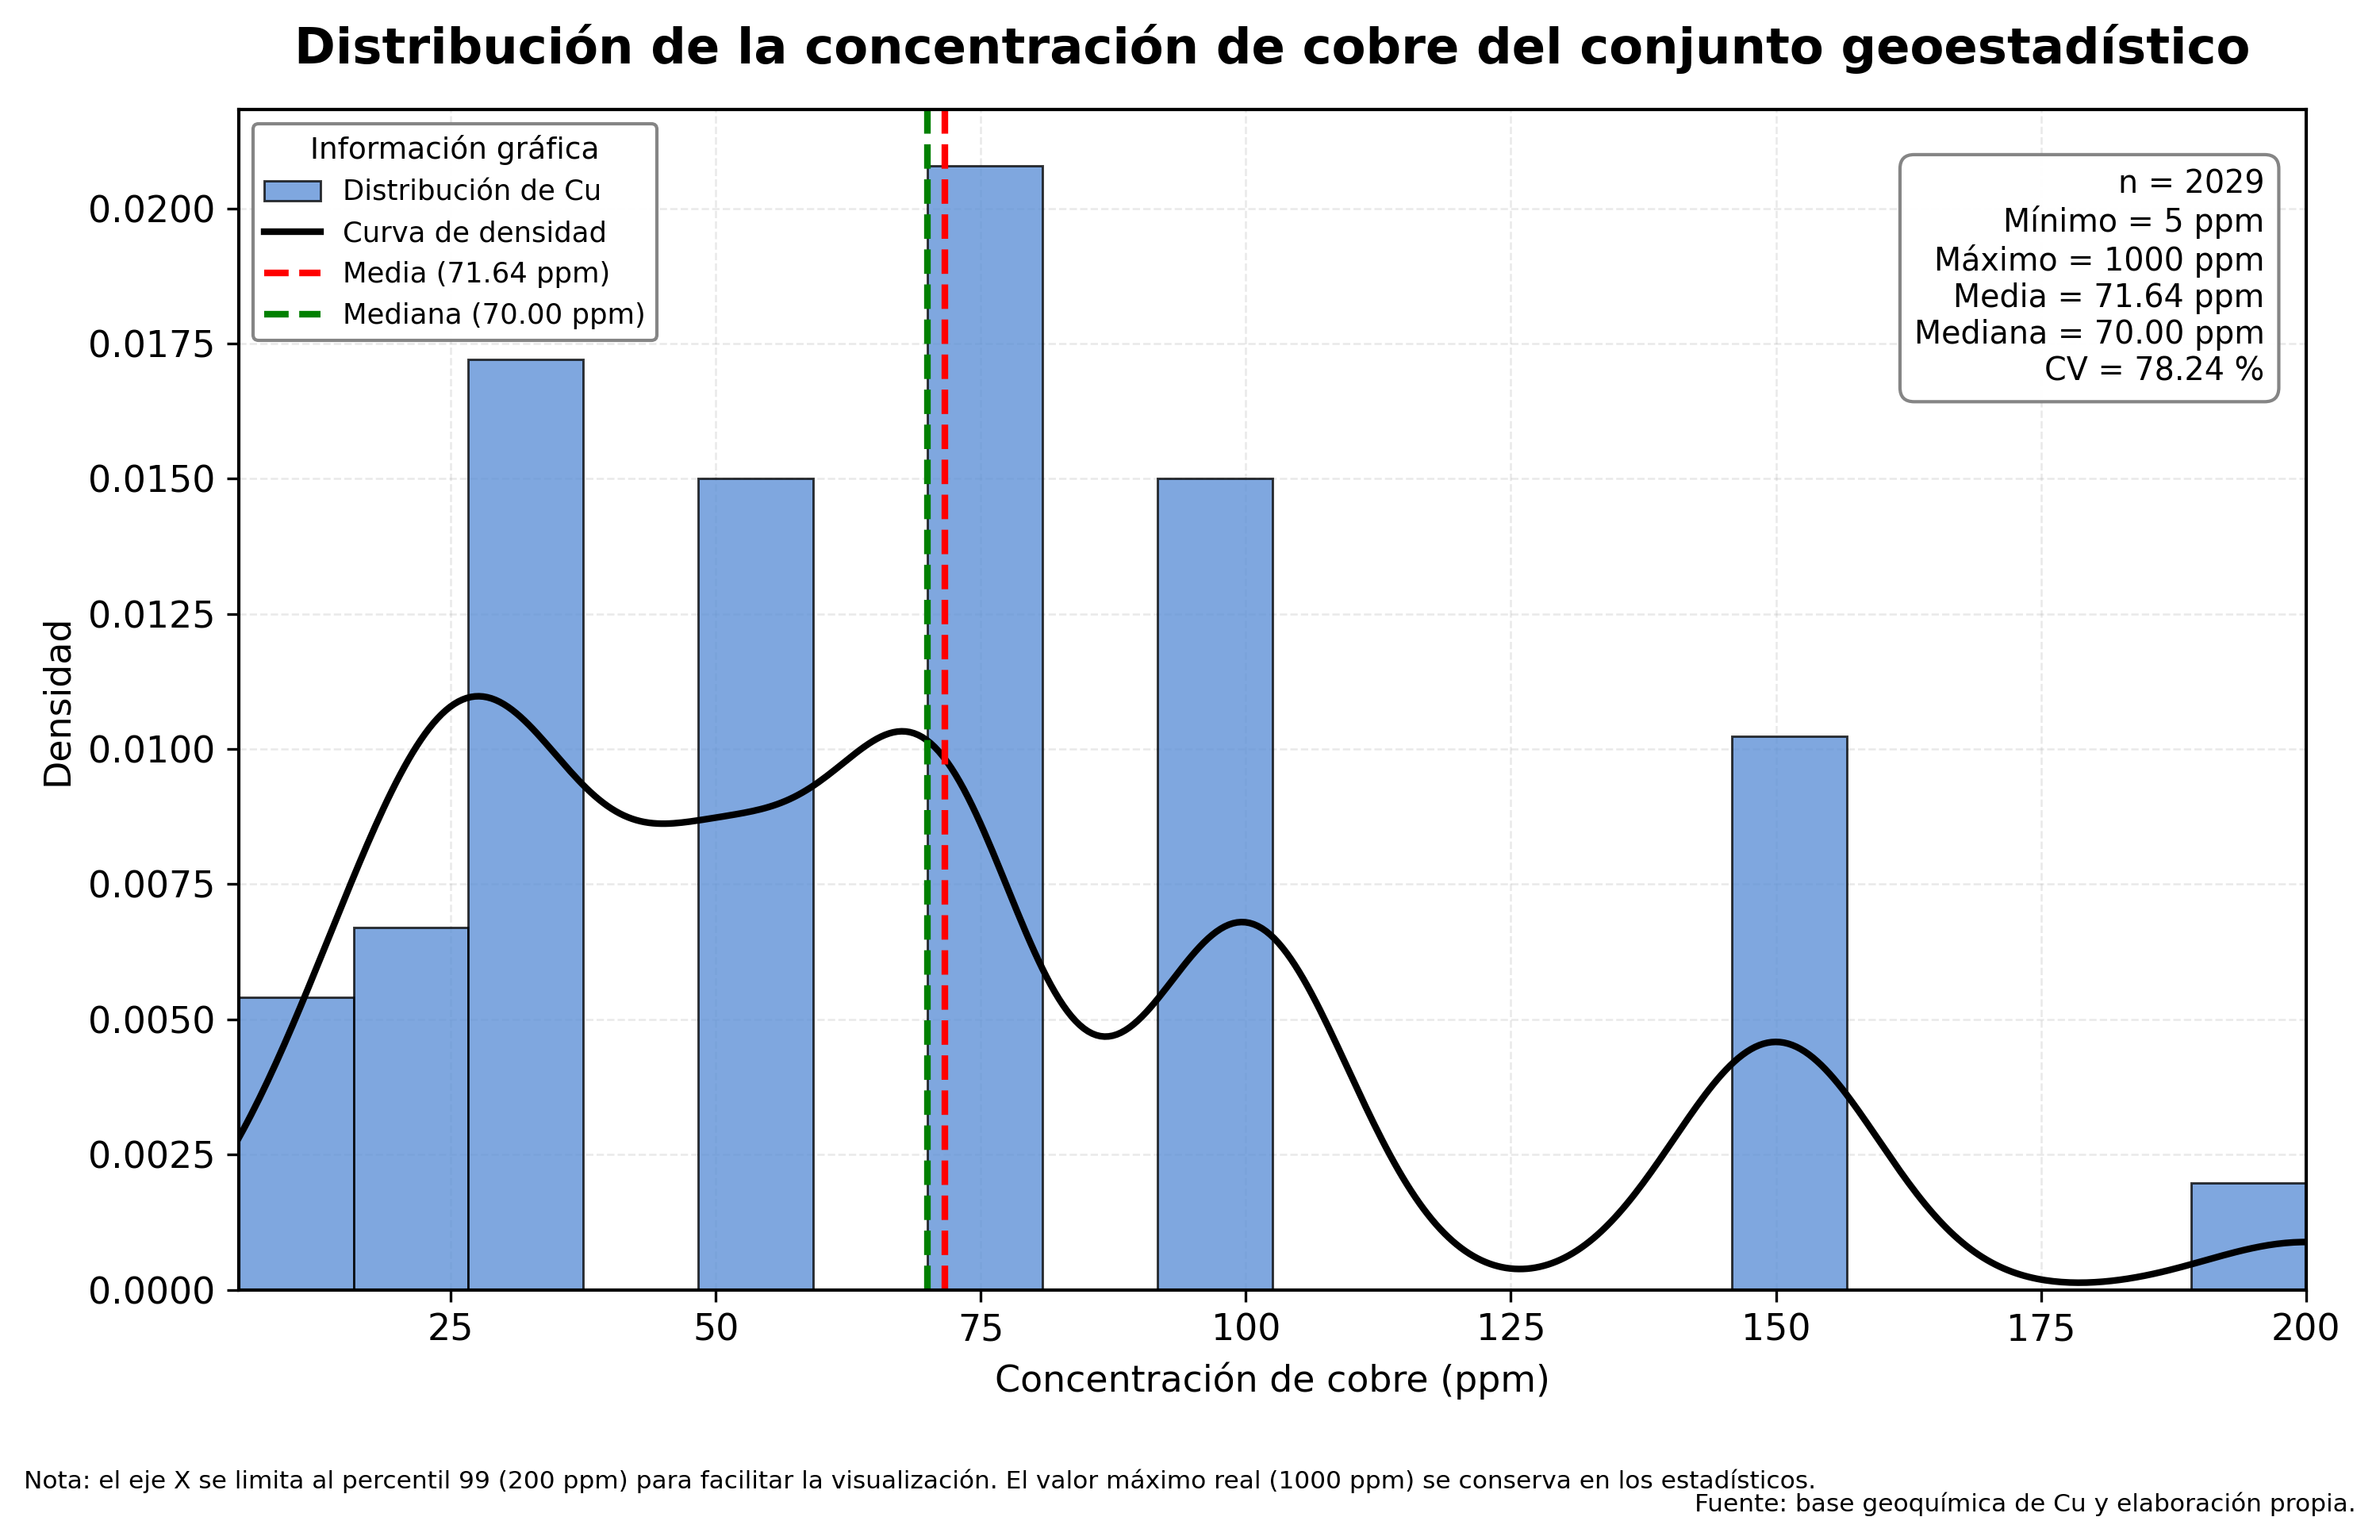

Figura generada con 2029 muestras. El eje X se limita al percentil 99 (200 ppm).


In [106]:
# ==========================================================
# Figura 11. Histograma del conjunto geoestadístico
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ----------------------------------------------------------
# 1. Variable de trabajo
# ----------------------------------------------------------

cu = datos_geoestadistica["Cu"].dropna()

# ----------------------------------------------------------
# 2. Estadísticos
# ----------------------------------------------------------

n = len(cu)
media = cu.mean()
mediana = cu.median()
desviacion = cu.std(ddof=1)
cv = (desviacion / media) * 100

valor_min = cu.min()
valor_max = cu.max()
p99 = cu.quantile(0.99)

# ----------------------------------------------------------
# 3. Número de intervalos: Freedman-Diaconis
# ----------------------------------------------------------

q1 = cu.quantile(0.25)
q3 = cu.quantile(0.75)
iqr = q3 - q1

ancho_clase = 2 * iqr / np.cbrt(n)

if ancho_clase > 0:
    bins = int(
        np.ceil(
            (p99 - valor_min) / ancho_clase
        )
    )
else:
    bins = 20

bins = max(10, min(bins, 50))

# Datos empleados únicamente para la visualización
cu_visual = cu[cu <= p99]

# ----------------------------------------------------------
# 4. Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6.5))

# Histograma
ax.hist(
    cu_visual,
    bins=bins,
    density=True,
    facecolor="#5B8FD6",
    edgecolor="black",
    linewidth=0.7,
    alpha=0.78,
    label="Distribución de Cu"
)

# Curva de densidad
x = np.linspace(
    cu_visual.min(),
    cu_visual.max(),
    500
)

kde = gaussian_kde(cu_visual)

ax.plot(
    x,
    kde(x),
    color="black",
    linewidth=2,
    label="Curva de densidad"
)

# Media
ax.axvline(
    media,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media ({media:.2f} ppm)"
)

# Mediana
ax.axvline(
    mediana,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Mediana ({mediana:.2f} ppm)"
)

# ----------------------------------------------------------
# 5. Cuadro estadístico
# ----------------------------------------------------------

texto_estadistico = (
    f"n = {n}\n"
    f"Mínimo = {valor_min:.0f} ppm\n"
    f"Máximo = {valor_max:.0f} ppm\n"
    f"Media = {media:.2f} ppm\n"
    f"Mediana = {mediana:.2f} ppm\n"
    f"CV = {cv:.2f} %"
)

ax.text(
    0.98,
    0.95,
    texto_estadistico,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round,pad=0.45",
        alpha=0.96
    ),
    zorder=10
)

# ----------------------------------------------------------
# 6. Título, ejes y cuadrícula
# ----------------------------------------------------------

ax.set_title(
    "Distribución de la concentración de cobre del conjunto geoestadístico",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    "Concentración de cobre (ppm)",
    fontsize=11
)

ax.set_ylabel(
    "Densidad",
    fontsize=11
)

ax.set_xlim(
    cu_visual.min(),
    p99
)

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.28
)

ax.set_axisbelow(True)

# ----------------------------------------------------------
# 7. Leyenda
# ----------------------------------------------------------

ax.legend(
    title="Información gráfica",
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.96,
    fontsize=8.5,
    title_fontsize=9
)

# ----------------------------------------------------------
# 8. Nota metodológica y fuente
# ----------------------------------------------------------

fig.text(
    0.01,
    0.025,
    (
        f"Nota: el eje X se limita al percentil 99 ({p99:.0f} ppm) "
        f"para facilitar la visualización. El valor máximo real "
        f"({valor_max:.0f} ppm) se conserva en los estadísticos."
    ),
    ha="left",
    va="bottom",
    fontsize=7.5
)

fig.text(
    0.99,
    0.010,
    "Fuente: base geoquímica de Cu y elaboración propia.",
    ha="right",
    va="bottom",
    fontsize=7.5
)

# Marco
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

# ----------------------------------------------------------
# 9. Guardar y mostrar
# ----------------------------------------------------------

guardar_figura(
    "Figura_11_Histograma_Conjunto_Geoestadistico.png"
)

plt.show()

print(
    f"Figura generada con {n} muestras. "
    f"El eje X se limita al percentil 99 ({p99:.0f} ppm)."
)

Figura 11. Histograma datos discretizados

La Figura 11 presenta la distribución de las concentraciones de cobre correspondientes a las 2.029 muestras utilizadas en el análisis geoestadístico. La distribución evidencia una marcada asimetría positiva, caracterizada por una alta frecuencia de concentraciones bajas y medias, acompañada de un número reducido de valores elevados que generan una cola hacia la derecha. La proximidad entre la media (71,64 ppm) y la mediana (70 ppm) indica que la mayor parte de las observaciones se concentra alrededor de estos valores, aunque la presencia de valores extremos incrementa la dispersión del conjunto de datos (CV = 78,24 %). Para mejorar la visualización, el histograma se presenta hasta el percentil 99 (200 ppm), manteniendo el valor máximo real (1000 ppm) únicamente en el resumen estadístico.

4.1.4 Evaluación de la normalidad

Antes de iniciar la modelación geoestadística, se evaluó nuevamente la normalidad de la concentración de cobre utilizando el conjunto definitivo de datos (2.029 muestras). Aunque métodos como el kriging ordinario no requieren estrictamente que la variable siga una distribución normal, conocer el comportamiento estadístico de los datos permite interpretar adecuadamente el variograma experimental y valorar la necesidad de aplicar transformaciones a la variable.

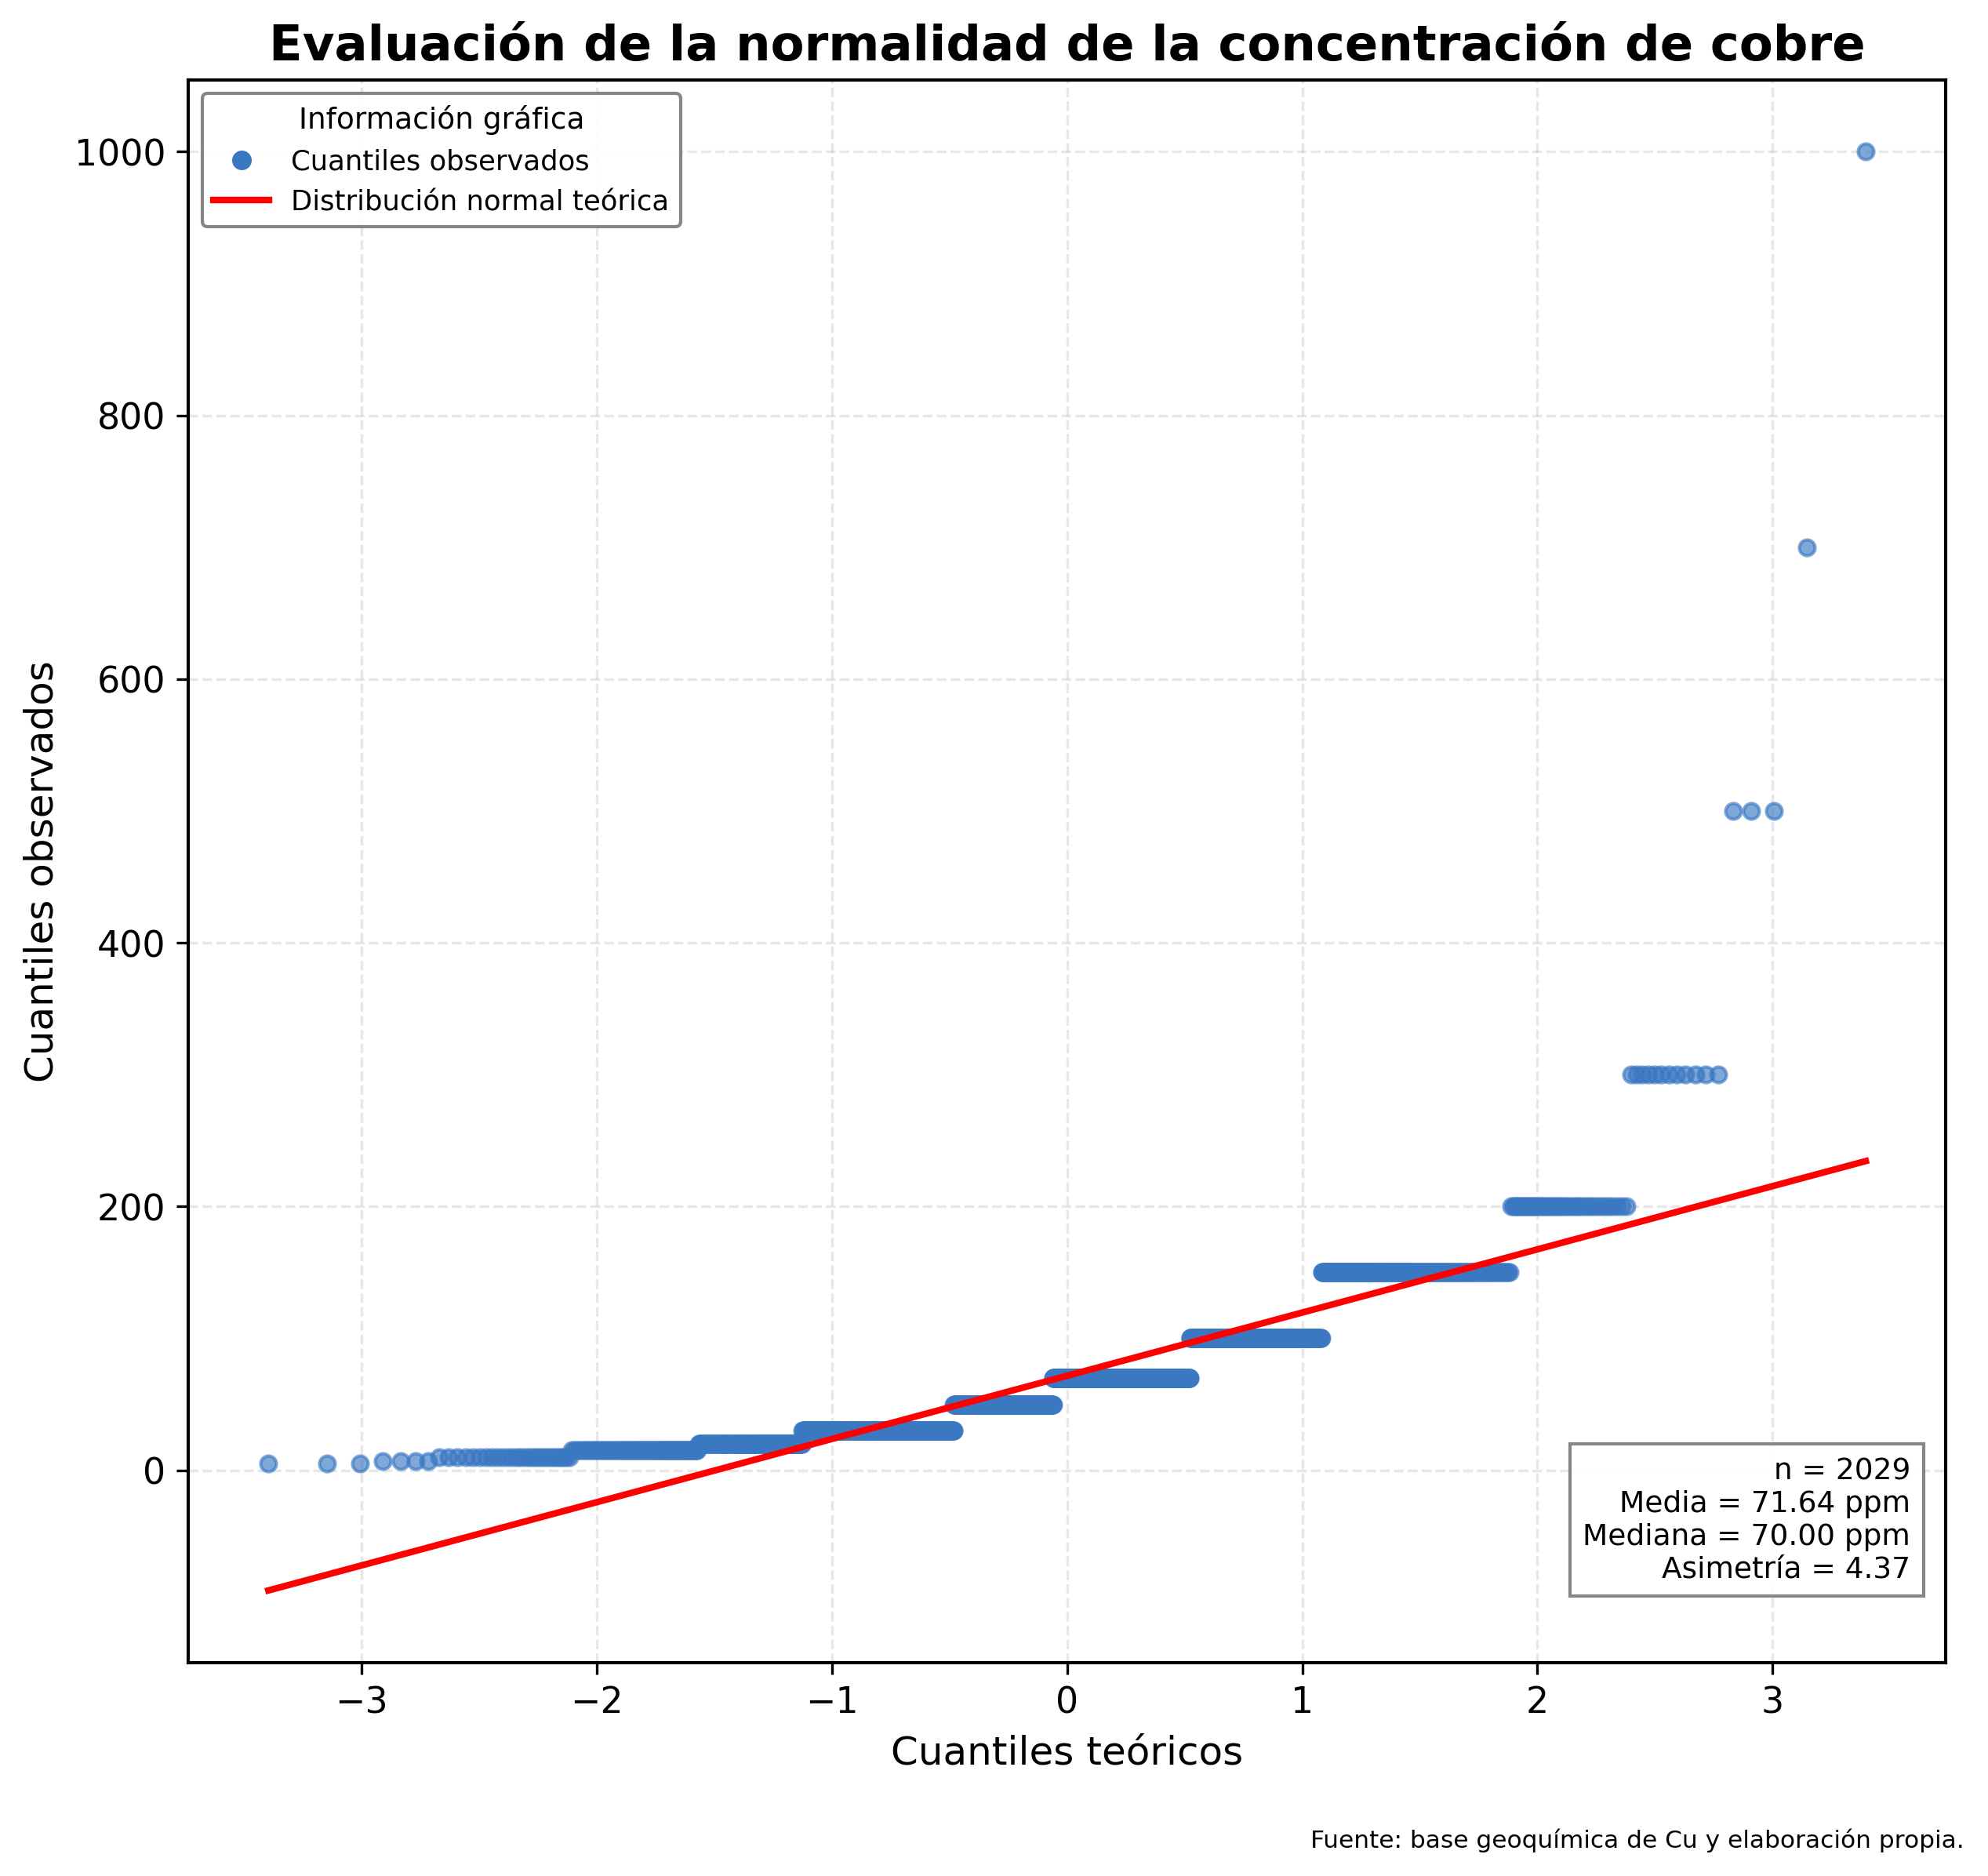

In [107]:
# ==========================================================
# Figura 12. Evaluación de la normalidad mediante gráfico Q-Q
# ==========================================================

import matplotlib.pyplot as plt
import scipy.stats as stats
from matplotlib.lines import Line2D

# ----------------------------------------------------------
# Variable de trabajo
# ----------------------------------------------------------

cu = datos_geoestadistica["Cu"]

# ----------------------------------------------------------
# Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5,8))

stats.probplot(
    cu,
    dist="norm",
    plot=ax
)

# ----------------------------------------------------------
# Personalizar puntos
# ----------------------------------------------------------

ax.get_lines()[0].set_marker("o")
ax.get_lines()[0].set_markersize(4.8)
ax.get_lines()[0].set_alpha(0.65)
ax.get_lines()[0].set_color("#3A78C2")

# Línea teórica

ax.get_lines()[1].set_color("red")
ax.get_lines()[1].set_linewidth(2)

# ----------------------------------------------------------
# Cuadro estadístico
# ----------------------------------------------------------

texto = (
    f"n = {len(cu)}\n"
    f"Media = {cu.mean():.2f} ppm\n"
    f"Mediana = {cu.median():.2f} ppm\n"
    f"Asimetría = {stats.skew(cu):.2f}"
)

ax.text(
    0.98,
    0.05,
    texto,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

# ----------------------------------------------------------
# Leyenda
# ----------------------------------------------------------

ax.legend(
    handles=[
        Line2D(
            [0],[0],
            marker="o",
            color="w",
            markerfacecolor="#3A78C2",
            markersize=7,
            label="Cuantiles observados"
        ),
        Line2D(
            [0],[0],
            color="red",
            linewidth=2,
            label="Distribución normal teórica"
        )
    ],
    title="Información gráfica",
    loc="upper left",
    framealpha=0.95,
    facecolor="white",
    edgecolor="gray",
    fontsize=8.5,
    title_fontsize=9
)

# ----------------------------------------------------------
# Formato
# ----------------------------------------------------------

ax.set_title(
    "Evaluación de la normalidad de la concentración de cobre",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Cuantiles teóricos")
ax.set_ylabel("Cuantiles observados")

ax.grid(
    linestyle="--",
    alpha=0.30
)

# Fuente

fig.text(
    0.99,
    0.01,
    "Fuente: base geoquímica de Cu y elaboración propia.",
    ha="right",
    fontsize=7.5
)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

plt.tight_layout(rect=[0,0.03,1,1])

guardar_figura(
    "Figura_12_QQPlot_Geoestadistica.png"
)

plt.show()

Figura 12. Evaluación de la normalidad de la concentración de cobre mediante gráfico Q–Q.

La Figura 12 muestra el gráfico de probabilidad normal (Q–Q) correspondiente al conjunto definitivo de datos utilizado en el análisis geoestadístico. Se observa que las observaciones se apartan progresivamente de la línea teórica de normalidad, especialmente en los cuantiles superiores, lo que evidencia una marcada asimetría positiva y la presencia de valores extremos. Este comportamiento coincide con los estadísticos descriptivos obtenidos previamente y confirma que la distribución de la concentración de cobre no sigue una distribución normal.

In [108]:
# ==========================================================
# Tabla 09. Prueba de normalidad Anderson-Darling
# ==========================================================

from scipy.stats import anderson

resultado = anderson(cu)

tabla_09 = pd.DataFrame({

    "Parámetro":[
        "Número de muestras",
        "Estadístico A²",
        "Valor crítico (5 %)",
        "Conclusión"
    ],

    "Resultado":[
        len(cu),
        round(resultado.statistic,3),
        resultado.critical_values[2],
        (
            "Se rechaza la normalidad"
            if resultado.statistic > resultado.critical_values[2]
            else "No se rechaza la normalidad"
        )
    ]

})

display(tabla_09)

,Parámetro,Resultado
0,Número de muestras,2029
1,Estadístico A²,87.951
2,Valor crítico (5 %),0.785
3,Conclusión,Se rechaza la normalidad


In [110]:
tabla_09.to_csv(
    RESULTADOS/"Tabla_09_Prueba_Anderson_Darling_Geoestadistica.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla 09 guardada correctamente.")

Tabla 09 guardada correctamente.


Tabla 9. Resultados de la prueba de normalidad Anderson-Darling para el conjunto utilizado en el análisis geoestadístico.

La prueba de Anderson-Darling confirma que la concentración de cobre no sigue una distribución normal, resultado consistente con el histograma, el gráfico Q–Q y los elevados valores de asimetría y curtosis observados previamente. Este comportamiento es frecuente en variables geoquímicas, donde la presencia de concentraciones anómalas genera distribuciones sesgadas hacia valores altos.

En conjunto, la evaluación de la normalidad demuestra que la variable presenta una distribución asimétrica con desviaciones significativas respecto a la normalidad. No obstante, esta condición no impide la aplicación del kriging ordinario, ya que este método no exige que la variable sea estrictamente normal. El aspecto fundamental para la modelación geoestadística es que exista una estructura de dependencia espacial representativa, la cual será evaluada mediante el análisis de anisotropía y la construcción del variograma experimental en las siguientes secciones.

4.2 Evaluación de la anisotropía

4.2.1 Fundamento y preparación del análisis

La anisotropía corresponde a la variación de la continuidad espacial de una variable en función de la dirección. En términos geoestadísticos, su evaluación permite determinar si la dependencia espacial de la concentración de cobre es similar en todas las direcciones o si existen orientaciones preferenciales asociadas al control geológico y estructural de la mineralización. Esta etapa es fundamental porque define si el variograma debe modelarse como isotrópico o anisotrópico, condición que influye directamente en la interpolación mediante kriging ordinario.

In [111]:
# ==========================================================
# Preparación del conjunto para el análisis de anisotropía
# ==========================================================

import numpy as np

# ----------------------------------------------------------
# Copiar únicamente el conjunto definitivo
# ----------------------------------------------------------

datos_anisotropia = datos_geoestadistica.copy()

# ----------------------------------------------------------
# Extraer coordenadas
# ----------------------------------------------------------

datos_anisotropia["X"] = datos_anisotropia.geometry.x
datos_anisotropia["Y"] = datos_anisotropia.geometry.y

# ----------------------------------------------------------
# Variable geoestadística
# ----------------------------------------------------------

x = datos_anisotropia["X"].values
y = datos_anisotropia["Y"].values
z = datos_anisotropia["Cu"].values

print("===== CONJUNTO PARA ANISOTROPÍA =====\n")

print(f"Número de muestras: {len(z)}")
print(f"Valor mínimo: {z.min():.2f} ppm")
print(f"Valor máximo: {z.max():.2f} ppm")
print(f"Media: {z.mean():.2f} ppm")

print("\nExtensión espacial")

print(f"X: {x.min():.0f} - {x.max():.0f}")
print(f"Y: {y.min():.0f} - {y.max():.0f}")

print("\nConjunto preparado correctamente.")

===== CONJUNTO PARA ANISOTROPÍA =====

Número de muestras: 2029
Valor mínimo: 5.00 ppm
Valor máximo: 1000.00 ppm
Media: 71.64 ppm

Extensión espacial
X: 728862 - 837725
Y: 1098800 - 1218650

Conjunto preparado correctamente.


El conjunto de datos preparado para el análisis de anisotropía conserva las 2.029 muestras utilizadas en la modelación geoestadística. A partir de estas observaciones se extrajeron las coordenadas cartesianas (X, Y) y la concentración de cobre (Cu), variables necesarias para calcular los variogramas direccionales y evaluar la continuidad espacial de la mineralización en diferentes orientaciones.

In [112]:
# ==========================================================
# Parámetros para el análisis de anisotropía
# ==========================================================

numero_lags = 15

maxlag = "median"

direcciones = [

    0,
    45,
    90,
    135

]

tolerancia = 22.5

print("===== PARÁMETROS DEL ANÁLISIS =====")

print(f"Número de lags: {numero_lags}")
print(f"Distancia máxima: {maxlag}")
print(f"Direcciones: {direcciones}")
print(f"Tolerancia angular: ±{tolerancia}°")

===== PARÁMETROS DEL ANÁLISIS =====
Número de lags: 15
Distancia máxima: median
Direcciones: [0, 45, 90, 135]
Tolerancia angular: ±22.5°


Para evaluar la anisotropía se calcularán variogramas experimentales en cuatro direcciones principales (0°, 45°, 90° y 135°), utilizando una tolerancia angular de ±22,5°. Esta configuración permite comparar la continuidad espacial de la concentración de cobre en diferentes orientaciones y establecer si existe una dirección preferencial de variabilidad asociada al contexto geológico y estructural del área de estudio.

4.2.2 Construcción de los variogramas direccionales

Con el propósito de identificar posibles direcciones preferenciales de continuidad espacial de la concentración de cobre, se calcularon variogramas experimentales en cuatro orientaciones principales (0°, 45°, 90° y 135°), utilizando una tolerancia angular de ±22,5°. La comparación entre estas direcciones permite evaluar si la variabilidad espacial es similar en todas las orientaciones (isotropía) o si presenta diferencias asociadas al control geológico y estructural del área de estudio (anisotropía).

In [122]:
# ==========================================================
# Figura 13. Variogramas experimentales direccionales
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

from skgstat import DirectionalVariogram

In [123]:
# ==========================================================
# Construcción de los variogramas direccionales
# ==========================================================

direcciones = [0,45,90,135]

variogramas = {}

for az in direcciones:

    variogramas[az] = DirectionalVariogram(

        coordinates=np.column_stack((x,y)),
        values=z,

        azimuth=az,
        tolerance=tolerancia,

        n_lags=numero_lags,
        maxlag=maxlag,

        normalize=False,
        use_nugget=True

    )

print("Variogramas construidos.")

Variogramas construidos.


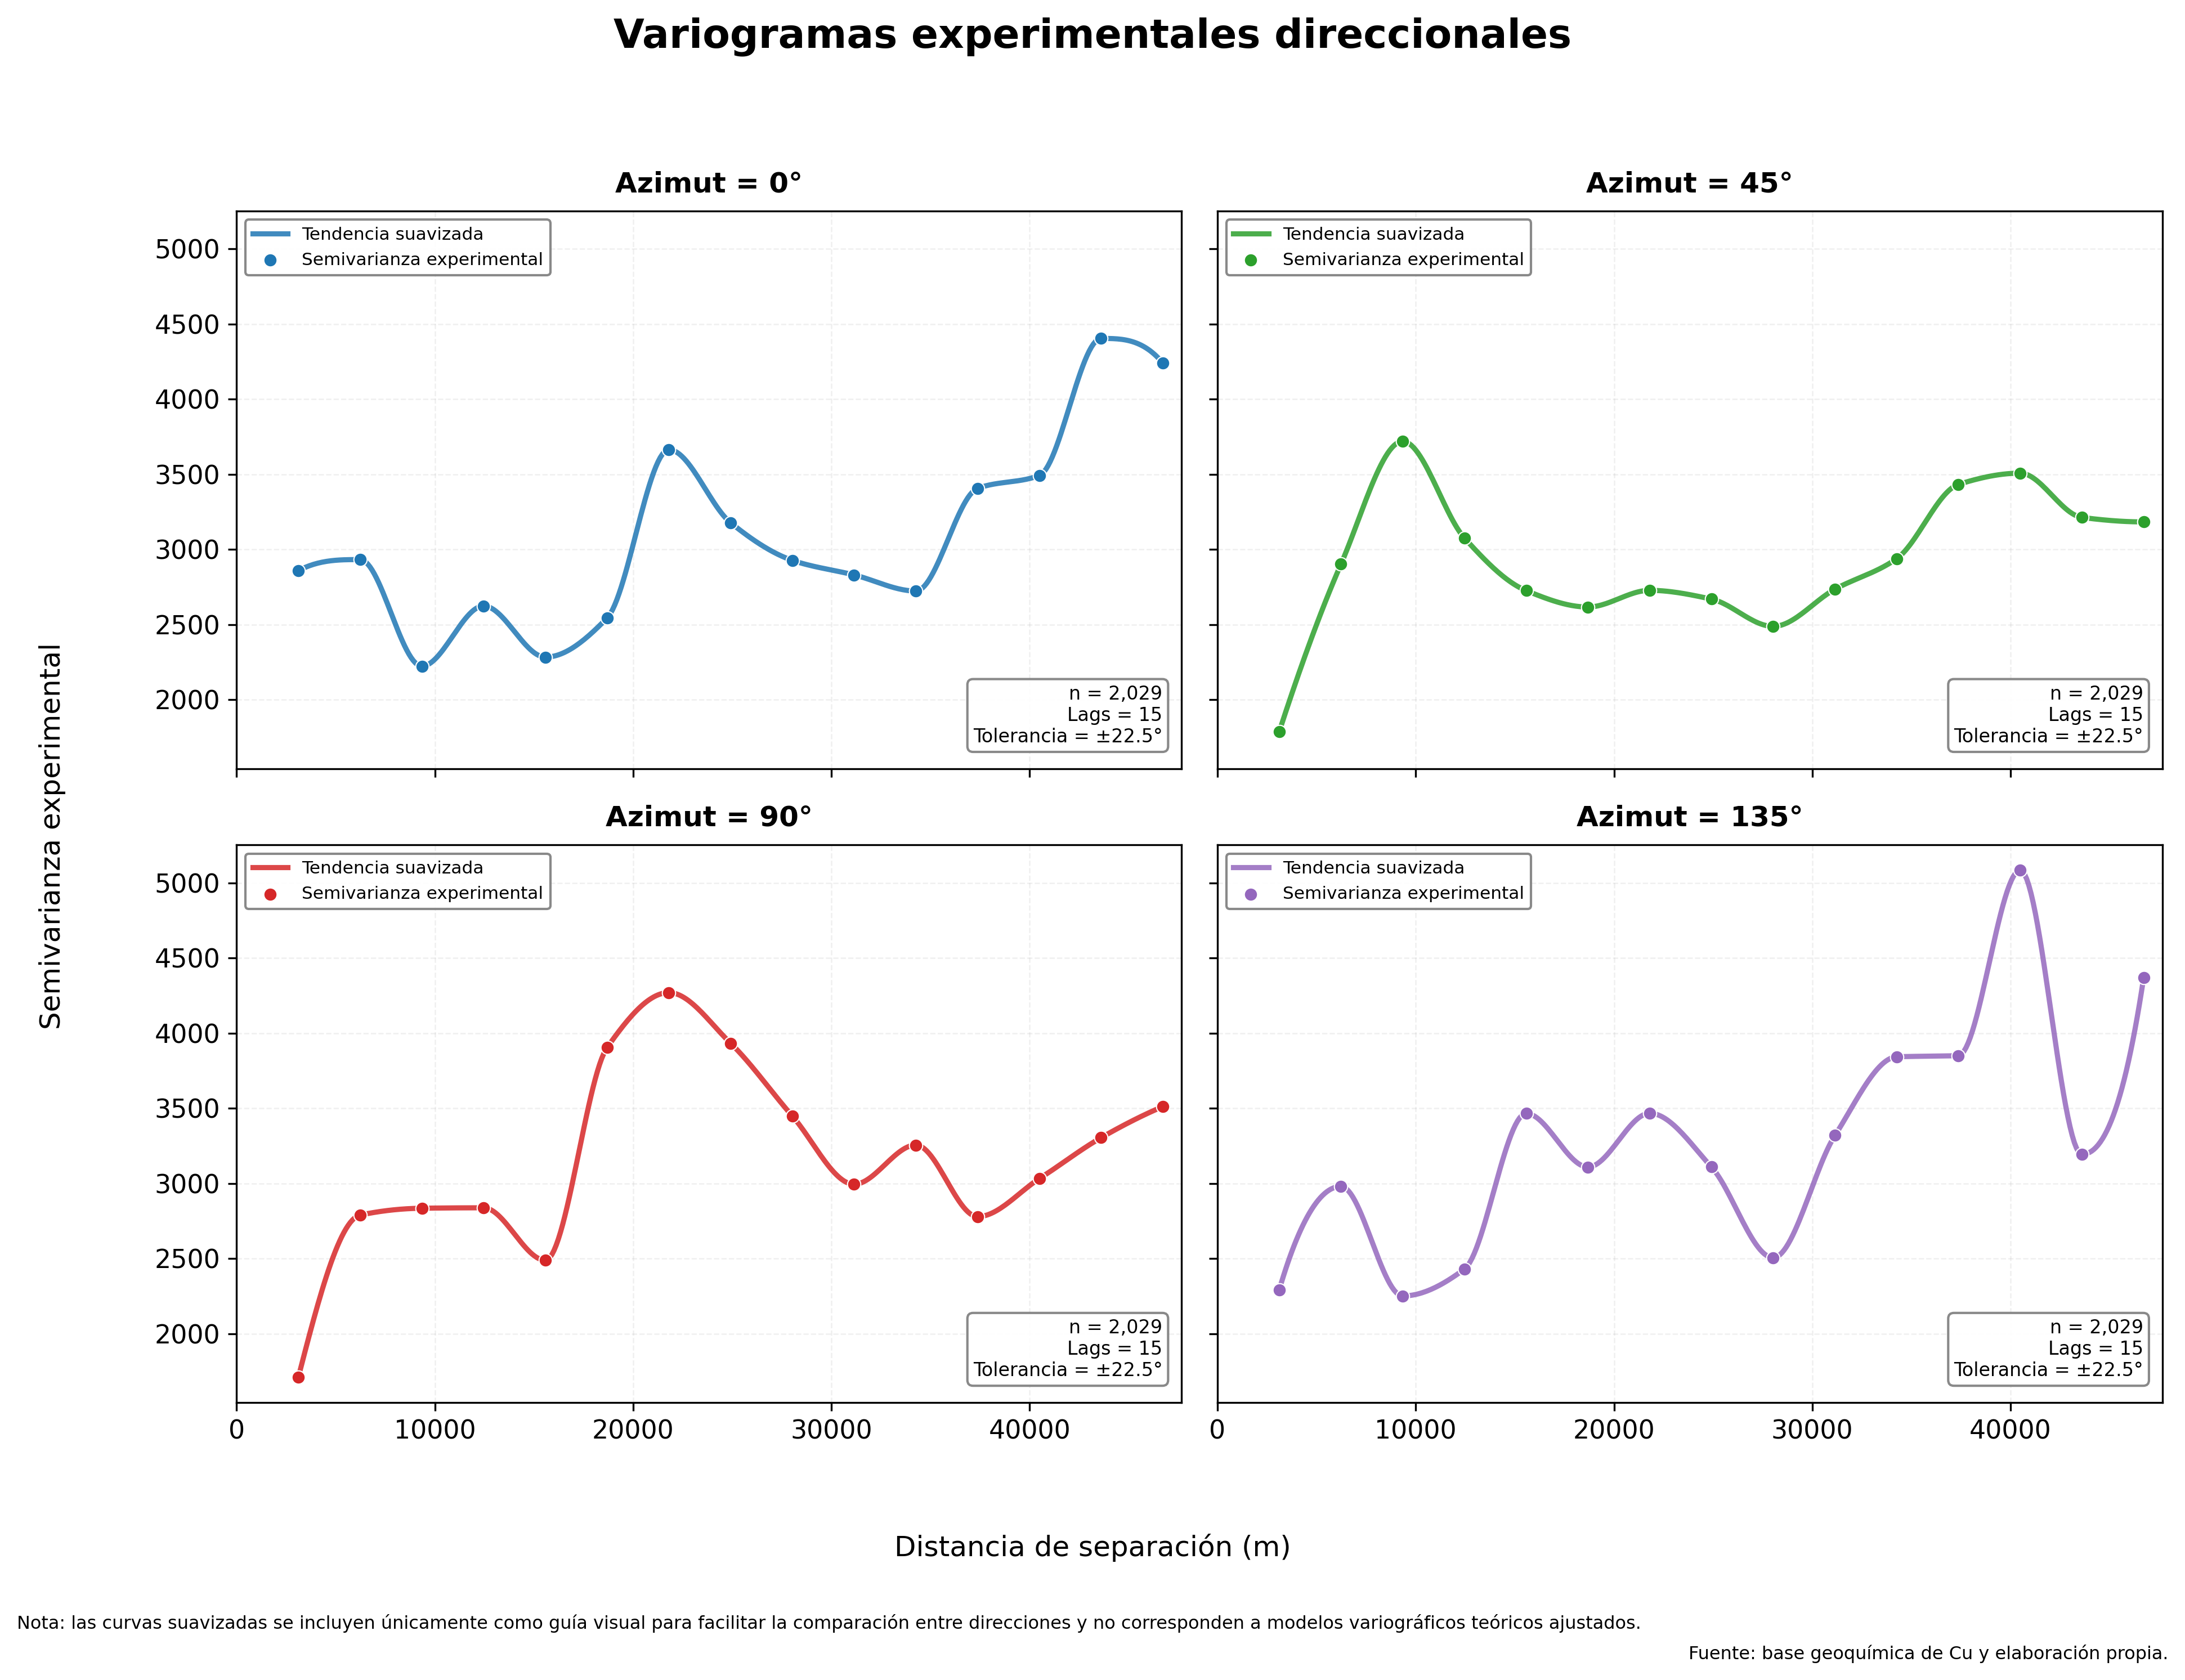

Figura 13 guardada correctamente.


In [125]:
# ==========================================================
# Figura 13. Variogramas experimentales direccionales
# con curva suavizada como guía visual
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import PchipInterpolator

# ----------------------------------------------------------
# 1. Crear figura
# ----------------------------------------------------------

fig, axs = plt.subplots(
    2,
    2,
    figsize=(13, 10),
    sharex=True,
    sharey=True
)

axs = axs.ravel()

colores = {
    0: "#1f77b4",
    45: "#2ca02c",
    90: "#d62728",
    135: "#9467bd"
}

# Distancias máximas comunes para mantener comparabilidad
distancia_maxima_m = max(
    np.nanmax(V.bins)
    for V in variogramas.values()
)

# ----------------------------------------------------------
# 2. Dibujar cada variograma
# ----------------------------------------------------------

for i, azimut in enumerate(direcciones):

    V = variogramas[azimut]

    distancias = np.asarray(V.bins, dtype=float)
    semivarianzas = np.asarray(V.experimental, dtype=float)

    # Eliminar valores no válidos
    mascara_valida = (
        np.isfinite(distancias)
        & np.isfinite(semivarianzas)
    )

    distancias_validas = distancias[mascara_valida]
    semivarianzas_validas = semivarianzas[mascara_valida]

    # Ordenar por distancia
    orden = np.argsort(distancias_validas)

    distancias_validas = distancias_validas[orden]
    semivarianzas_validas = semivarianzas_validas[orden]

    # Eliminar posibles distancias repetidas
    distancias_unicas, indices_unicos = np.unique(
        distancias_validas,
        return_index=True
    )

    semivarianzas_unicas = semivarianzas_validas[
        indices_unicos
    ]

    # ------------------------------------------------------
    # Curva suavizada PCHIP
    # ------------------------------------------------------

    if len(distancias_unicas) >= 3:

        interpolador = PchipInterpolator(
            distancias_unicas,
            semivarianzas_unicas
        )

        distancia_suave = np.linspace(
            distancias_unicas.min(),
            distancias_unicas.max(),
            400
        )

        semivarianza_suave = interpolador(
            distancia_suave
        )

        axs[i].plot(
            distancia_suave,
            semivarianza_suave,
            color=colores[azimut],
            linewidth=2.2,
            alpha=0.85,
            label="Tendencia suavizada",
            zorder=2
        )

    # ------------------------------------------------------
    # Puntos experimentales
    # ------------------------------------------------------

    axs[i].scatter(
        distancias_validas,
        semivarianzas_validas,
        s=32,
        color=colores[azimut],
        edgecolor="white",
        linewidth=0.5,
        label="Semivarianza experimental",
        zorder=3
    )

    # ------------------------------------------------------
    # Formato del panel
    # ------------------------------------------------------

    axs[i].set_title(
        f"Azimut = {azimut}°",
        fontsize=12,
        fontweight="bold",
        pad=8
    )

    axs[i].set_xlim(
        0,
        distancia_maxima_m * 1.02
    )

    axs[i].grid(
        linestyle="--",
        linewidth=0.6,
        alpha=0.20
    )

    axs[i].set_axisbelow(True)

    texto_parametros = (
        f"n = {len(datos_anisotropia):,}\n"
        f"Lags = {numero_lags}\n"
        f"Tolerancia = ±{tolerancia:.1f}°"
    )

    axs[i].text(
        0.98,
        0.04,
        texto_parametros,
        transform=axs[i].transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            boxstyle="round,pad=0.30",
            alpha=0.93
        ),
        zorder=10
    )

    axs[i].legend(
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="gray",
        framealpha=0.93,
        fontsize=7.5
    )

# ----------------------------------------------------------
# 3. Título general y ejes compartidos
# ----------------------------------------------------------

fig.suptitle(
    "Variogramas experimentales direccionales",
    fontsize=17,
    fontweight="bold",
    y=0.985
)

fig.supxlabel(
    "Distancia de separación (m)",
    fontsize=12,
    y=0.070
)

fig.supylabel(
    "Semivarianza experimental",
    fontsize=12,
    x=0.020
)

# ----------------------------------------------------------
# 4. Nota metodológica y fuente
# ----------------------------------------------------------

fig.text(
    0.01,
    0.028,
    (
        "Nota: las curvas suavizadas se incluyen únicamente como guía visual "
        "para facilitar la comparación entre direcciones y no corresponden "
        "a modelos variográficos teóricos ajustados."
    ),
    ha="left",
    va="bottom",
    fontsize=7.7
)

fig.text(
    0.99,
    0.010,
    "Fuente: base geoquímica de Cu y elaboración propia.",
    ha="right",
    va="bottom",
    fontsize=7.7
)

# ----------------------------------------------------------
# 5. Ajuste de diseño
# ----------------------------------------------------------

plt.tight_layout(
    rect=[0.035, 0.09, 1, 0.95]
)

# ----------------------------------------------------------
# 6. Guardar y mostrar
# ----------------------------------------------------------

guardar_figura(
    "Figura_13_Variogramas_Direccionales_Suavizados.png"
)

plt.show()

print("Figura 13 guardada correctamente.")

Figura 13. Variogramas experimentales direccionales para la evaluación de la anisotropía espacial de la concentración de cobre.

La Figura 13 presenta los variogramas experimentales calculados para los azimuts 0°, 45°, 90° y 135°. Los puntos representan las semivarianzas experimentales obtenidas para cada intervalo de distancia, mientras que las curvas suavizadas se incorporan únicamente como guía visual para facilitar la comparación de las tendencias entre direcciones. Estas curvas no corresponden a modelos variográficos teóricos ajustados. Las diferencias observadas en la forma, magnitud y evolución de la semivarianza permiten evaluar posibles cambios direccionales en la continuidad espacial de la concentración de cobre.

4.2.3 Comparación de los variogramas direccionales

Para complementar la comparación visual de los variogramas direccionales, se calcularon indicadores descriptivos para cada azimut analizado. Estos indicadores permiten comparar la magnitud media y máxima de la semivarianza, el comportamiento del último intervalo de distancia y la cantidad de pares utilizados. Una menor semivarianza relativa indica mayor continuidad espacial de la concentración de cobre, mientras que valores más elevados reflejan una mayor variabilidad entre muestras separadas por distancias similares.

In [130]:
# ==========================================================
# Tabla 10. Comparación descriptiva de los variogramas
# direccionales
# ==========================================================

import numpy as np
import pandas as pd

resumen_direccional = []

for azimut in direcciones:

    V = variogramas[azimut]

    # Extraer distancias y semivarianzas
    distancias = np.asarray(
        V.bins,
        dtype=float
    )

    semivarianzas = np.asarray(
        V.experimental,
        dtype=float
    )

    # Conservar únicamente valores válidos
    mascara_valida = (
        np.isfinite(distancias)
        & np.isfinite(semivarianzas)
    )

    distancias_validas = distancias[
        mascara_valida
    ]

    semivarianzas_validas = semivarianzas[
        mascara_valida
    ]

    # Ordenar por distancia
    orden = np.argsort(
        distancias_validas
    )

    distancias_validas = distancias_validas[
        orden
    ]

    semivarianzas_validas = semivarianzas[
        orden
    ]

    # Número total de pares
    if hasattr(V, "bin_count"):

        conteo_pares = np.asarray(
            V.bin_count,
            dtype=float
        )

        if len(conteo_pares) == len(distancias):
            conteo_pares = conteo_pares[
                mascara_valida
            ]

        numero_total_pares = int(
            np.nansum(conteo_pares)
        )

    else:
        numero_total_pares = np.nan

    # Indicadores descriptivos
    resumen_direccional.append({

        "Azimut (°)": azimut,

        "Lags válidos":
            len(semivarianzas_validas),

        "Distancia máxima (m)":
            np.nanmax(distancias_validas),

        "Semivarianza media":
            np.nanmean(semivarianzas_validas),

        "Semivarianza mínima":
            np.nanmin(semivarianzas_validas),

        "Semivarianza máxima":
            np.nanmax(semivarianzas_validas),

        "Semivarianza último lag":
            semivarianzas_validas[-1],

        "Número total de pares":
            numero_total_pares
    })


tabla_10 = pd.DataFrame(
    resumen_direccional
)

# Redondear
columnas_numericas = [
    "Distancia máxima (m)",
    "Semivarianza media",
    "Semivarianza mínima",
    "Semivarianza máxima",
    "Semivarianza último lag"
]

tabla_10[columnas_numericas] = (
    tabla_10[columnas_numericas]
    .round(2)
)

# Ordenar por dirección
tabla_10 = (
    tabla_10
    .sort_values("Azimut (°)")
    .reset_index(drop=True)
)

display(tabla_10)

,Azimut (°),Lags válidos,Distancia máxima (m),Semivarianza media,Semivarianza mínima,Semivarianza máxima,Semivarianza último lag,Número total de pares
0,0,15,46713.94,3088.98,2223.34,4404.32,4240.48,136282
1,45,15,46713.94,2915.14,1787.21,3719.73,3183.51,148866
2,90,15,46713.94,3138.95,1710.51,4269.19,3510.93,121612
3,135,15,46713.94,3283.96,2250.58,5084.05,4369.64,117146


In [131]:
# ==========================================================
# Guardar Tabla 10
# ==========================================================

tabla_10.to_csv(
    RESULTADOS /
    "Tabla_10_Comparacion_Descriptiva_Variogramas_Direccionales.csv",
    encoding="utf-8-sig",
    index=False
)

print("Tabla 10 guardada correctamente.")

Tabla 10 guardada correctamente.


Tabla 10. Comparación descriptiva de los variogramas experimentales direccionales de la concentración de cobre.

In [132]:
diferencia_porcentual = (
    (
        tabla_10["Semivarianza media"].max()
        - tabla_10["Semivarianza media"].min()
    )
    / tabla_10["Semivarianza media"].min()
) * 100

print(
    f"Diferencia relativa entre direcciones: "
    f"{diferencia_porcentual:.2f} %"
)

Diferencia relativa entre direcciones: 12.65 %


Los variogramas direccionales presentan diferencias numéricas moderadas, pero no muestran una dirección con un comportamiento claramente separado de las demás. Las curvas tienen formas generales similares y exhiben fluctuaciones a lo largo de las distancias analizadas. Por esta razón, los resultados experimentales no proporcionan evidencia suficiente para afirmar la existencia de una anisotropía marcada.

4.3 Construcción del variograma experimental omnidirecciona

Una vez evaluada la posible influencia de la anisotropía, se procedió a construir el variograma experimental omnidireccional, el cual constituye la base para la modelación geoestadística de la concentración de cobre. El variograma experimental describe la relación entre la similitud de los valores geoquímicos y la distancia que los separa, permitiendo cuantificar la continuidad espacial de la variable y definir posteriormente el modelo variográfico que será utilizado en la interpolación mediante kriging ordinario.

4.3.1 Definición de los parámetros del variograma

La construcción del variograma experimental requiere definir previamente un conjunto de parámetros que controlan la agrupación de los pares de muestras y la escala espacial del análisis. Estos parámetros influyen directamente en la estabilidad de la semivarianza experimental y en la capacidad del variograma para representar la continuidad espacial de la variable. Con el fin de garantizar la consistencia metodológica, se emplearon los mismos parámetros utilizados durante la evaluación de la anisotropía.

In [135]:
# ==========================================================
# 4.3.1 Parámetros del variograma experimental
# ==========================================================

import numpy as np

# Tomar uno de los variogramas direccionales ya calculados
V_referencia = next(iter(variogramas.values()))

# Distancia máxima efectiva realmente utilizada
distancia_maxima = float(
    np.nanmax(V_referencia.bins)
)

# Ancho aproximado de cada lag
ancho_lag = distancia_maxima / numero_lags

print("=" * 60)
print("PARÁMETROS DEL VARIOGRAMA EXPERIMENTAL")
print("=" * 60)

print(f"Número de muestras              : {len(datos_geoestadistica)}")
print(f"Número de lags                 : {numero_lags}")
print(f"Criterio de distancia máxima   : {maxlag}")
print(f"Distancia máxima efectiva (m)  : {distancia_maxima:,.2f}")
print(f"Distancia máxima efectiva (km) : {distancia_maxima / 1000:.2f}")
print(f"Ancho aproximado del lag (m)   : {ancho_lag:,.2f}")
print(f"Ancho aproximado del lag (km)  : {ancho_lag / 1000:.2f}")
print(f"Tolerancia angular             : ±{tolerancia}°")
print(f"CRS                            : {datos_geoestadistica.crs}")

PARÁMETROS DEL VARIOGRAMA EXPERIMENTAL
Número de muestras              : 2029
Número de lags                 : 15
Criterio de distancia máxima   : median
Distancia máxima efectiva (m)  : 46,713.94
Distancia máxima efectiva (km) : 46.71
Ancho aproximado del lag (m)   : 3,114.26
Ancho aproximado del lag (km)  : 3.11
Tolerancia angular             : ±22.5°
CRS                            : EPSG:21897


In [136]:
# ==========================================================
# Tabla 11. Parámetros del variograma experimental
# ==========================================================

import pandas as pd

tabla_11 = pd.DataFrame({
    "Parámetro": [
        "Número de muestras",
        "Sistema de referencia",
        "Número de lags",
        "Criterio de distancia máxima",
        "Distancia máxima efectiva (m)",
        "Distancia máxima efectiva (km)",
        "Ancho aproximado del lag (m)",
        "Ancho aproximado del lag (km)",
        "Tolerancia angular"
    ],
    "Valor": [
        len(datos_geoestadistica),
        str(datos_geoestadistica.crs),
        numero_lags,
        str(maxlag),
        round(distancia_maxima, 2),
        round(distancia_maxima / 1000, 2),
        round(ancho_lag, 2),
        round(ancho_lag / 1000, 2),
        f"±{tolerancia}°"
    ]
})

display(tabla_11)

,Parámetro,Valor
0,Número de muestras,2029
1,Sistema de referencia,EPSG:21897
2,Número de lags,15
3,Criterio de distancia máxima,median
4,Distancia máxima efectiva (m),46713.94
5,Distancia máxima efectiva (km),46.71
6,Ancho aproximado del lag (m),3114.26
7,Ancho aproximado del lag (km),3.11
8,Tolerancia angular,±22.5°


In [140]:
# ==========================================================
# Guardar Tabla 11
# ==========================================================

tabla_11.to_csv(
    RESULTADOS / "Tabla_11_Parametros_Variograma.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabla 11 guardada correctamente.")

Tabla 11 guardada correctamente.


Tabla 11. Parametros del variograma

4.3.2 Variograma experimental omnidireccional

Una vez definidos los parámetros de cálculo, se construyó el variograma experimental omnidireccional de la concentración de cobre. Este variograma considera todas las orientaciones posibles entre los pares de muestras y permite evaluar la evolución general de la semivarianza con la distancia. Su comportamiento constituye la base para identificar la continuidad espacial de la variable y ajustar posteriormente los modelos variográficos teóricos.

In [141]:
# ==========================================================
# 4.3.2 Construcción del variograma experimental
# omnidireccional
# ==========================================================

import numpy as np
from skgstat import Variogram

# Coordenadas y valores del conjunto definitivo
coordenadas = np.column_stack((
    datos_geoestadistica.geometry.x.to_numpy(),
    datos_geoestadistica.geometry.y.to_numpy()
))

valores_cu = (
    datos_geoestadistica["Cu"]
    .astype(float)
    .to_numpy()
)

# Construcción del variograma experimental omnidireccional
variograma_omni = Variogram(
    coordinates=coordenadas,
    values=valores_cu,
    n_lags=numero_lags,
    maxlag=maxlag,              # criterio definido: "median"
    normalize=False,
    use_nugget=True,
    estimator="matheron"
)

print("Variograma experimental omnidireccional calculado correctamente.")

Variograma experimental omnidireccional calculado correctamente.


In [142]:
# ==========================================================
# Verificación del variograma omnidireccional
# ==========================================================

distancias_omni = np.asarray(
    variograma_omni.bins,
    dtype=float
)

semivarianzas_omni = np.asarray(
    variograma_omni.experimental,
    dtype=float
)

pares_por_lag_omni = np.asarray(
    variograma_omni.bin_count,
    dtype=int
)

mascara_valida_omni = (
    np.isfinite(distancias_omni)
    & np.isfinite(semivarianzas_omni)
)

distancias_omni = distancias_omni[
    mascara_valida_omni
]

semivarianzas_omni = semivarianzas_omni[
    mascara_valida_omni
]

pares_por_lag_omni = pares_por_lag_omni[
    mascara_valida_omni
]

print("=" * 60)
print("VARIOGRAMA EXPERIMENTAL OMNIDIRECCIONAL")
print("=" * 60)

print(f"Muestras utilizadas             : {len(valores_cu)}")
print(f"Lags válidos                    : {len(distancias_omni)}")
print(
    f"Distancia máxima efectiva (m)  : "
    f"{distancias_omni.max():,.2f}"
)
print(
    f"Distancia máxima efectiva (km) : "
    f"{distancias_omni.max()/1000:.2f}"
)
print(
    f"Semivarianza mínima            : "
    f"{semivarianzas_omni.min():,.2f}"
)
print(
    f"Semivarianza máxima            : "
    f"{semivarianzas_omni.max():,.2f}"
)
print(
    f"Número total de pares          : "
    f"{pares_por_lag_omni.sum():,}"
)
print(
    f"Mínimo de pares por lag        : "
    f"{pares_por_lag_omni.min():,}"
)

VARIOGRAMA EXPERIMENTAL OMNIDIRECCIONAL
Muestras utilizadas             : 2029
Lags válidos                    : 15
Distancia máxima efectiva (m)  : 46,713.94
Distancia máxima efectiva (km) : 46.71
Semivarianza mínima            : 2,526.41
Semivarianza máxima            : 3,892.99
Número total de pares          : 1,028,703
Mínimo de pares por lag        : 18,022


In [143]:
# ==========================================================
# Tabla 12. Valores del variograma experimental
# omnidireccional
# ==========================================================

import pandas as pd

tabla_12 = pd.DataFrame({
    "Lag": np.arange(
        1,
        len(distancias_omni) + 1
    ),
    "Distancia (m)": distancias_omni,
    "Distancia (km)": distancias_omni / 1000,
    "Semivarianza experimental": semivarianzas_omni,
    "Número de pares": pares_por_lag_omni
})

tabla_12 = tabla_12.round({
    "Distancia (m)": 2,
    "Distancia (km)": 2,
    "Semivarianza experimental": 2
})

display(tabla_12)

,Lag,Distancia (m),Distancia (km),Semivarianza experimental,Número de pares
0,1,3114.26,3.11,2526.41,18022
1,2,6228.53,6.23,2760.56,36488
2,3,9342.79,9.34,2870.33,52749
3,4,12457.05,12.46,2898.54,61403
4,5,15571.31,15.57,2802.19,72192
5,6,18685.58,18.69,3178.50,79665
6,7,21799.84,21.80,3191.97,82972
7,8,24914.10,24.91,3102.65,86040
8,9,28028.36,28.03,2849.36,88082
9,10,31142.63,31.14,2803.42,89691


In [150]:
# ==========================================================
# Guardar Tabla 12
# ==========================================================

tabla_12.to_csv(
    RESULTADOS /
    "Tabla_12_Variograma_Experimental_Omnidireccional.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabla 12 guardada correctamente.")

Tabla 12 guardada correctamente.


Tabla 12. Valores del variograma experimental omnidireccional de la concentración de cobre por intervalo de distancia.

,Modelo,Nugget,Meseta parcial,Sill total,Rango práctico (m),Rango práctico (km),RMSE,MAE,R²,RSS,AIC,Seleccionado
0,Gaussiano,2747.47,3285.08,6032.55,140141.82,140.14,183.11,148.52,0.7521,502965.29,162.30,Sí
1,Esférico,2530.09,2157.04,4687.13,140141.82,140.14,196.31,160.94,0.7151,578056.76,164.39,No
2,Exponencial,2429.67,1690.91,4120.58,140141.82,140.14,210.86,171.38,0.6713,666916.55,166.54,No


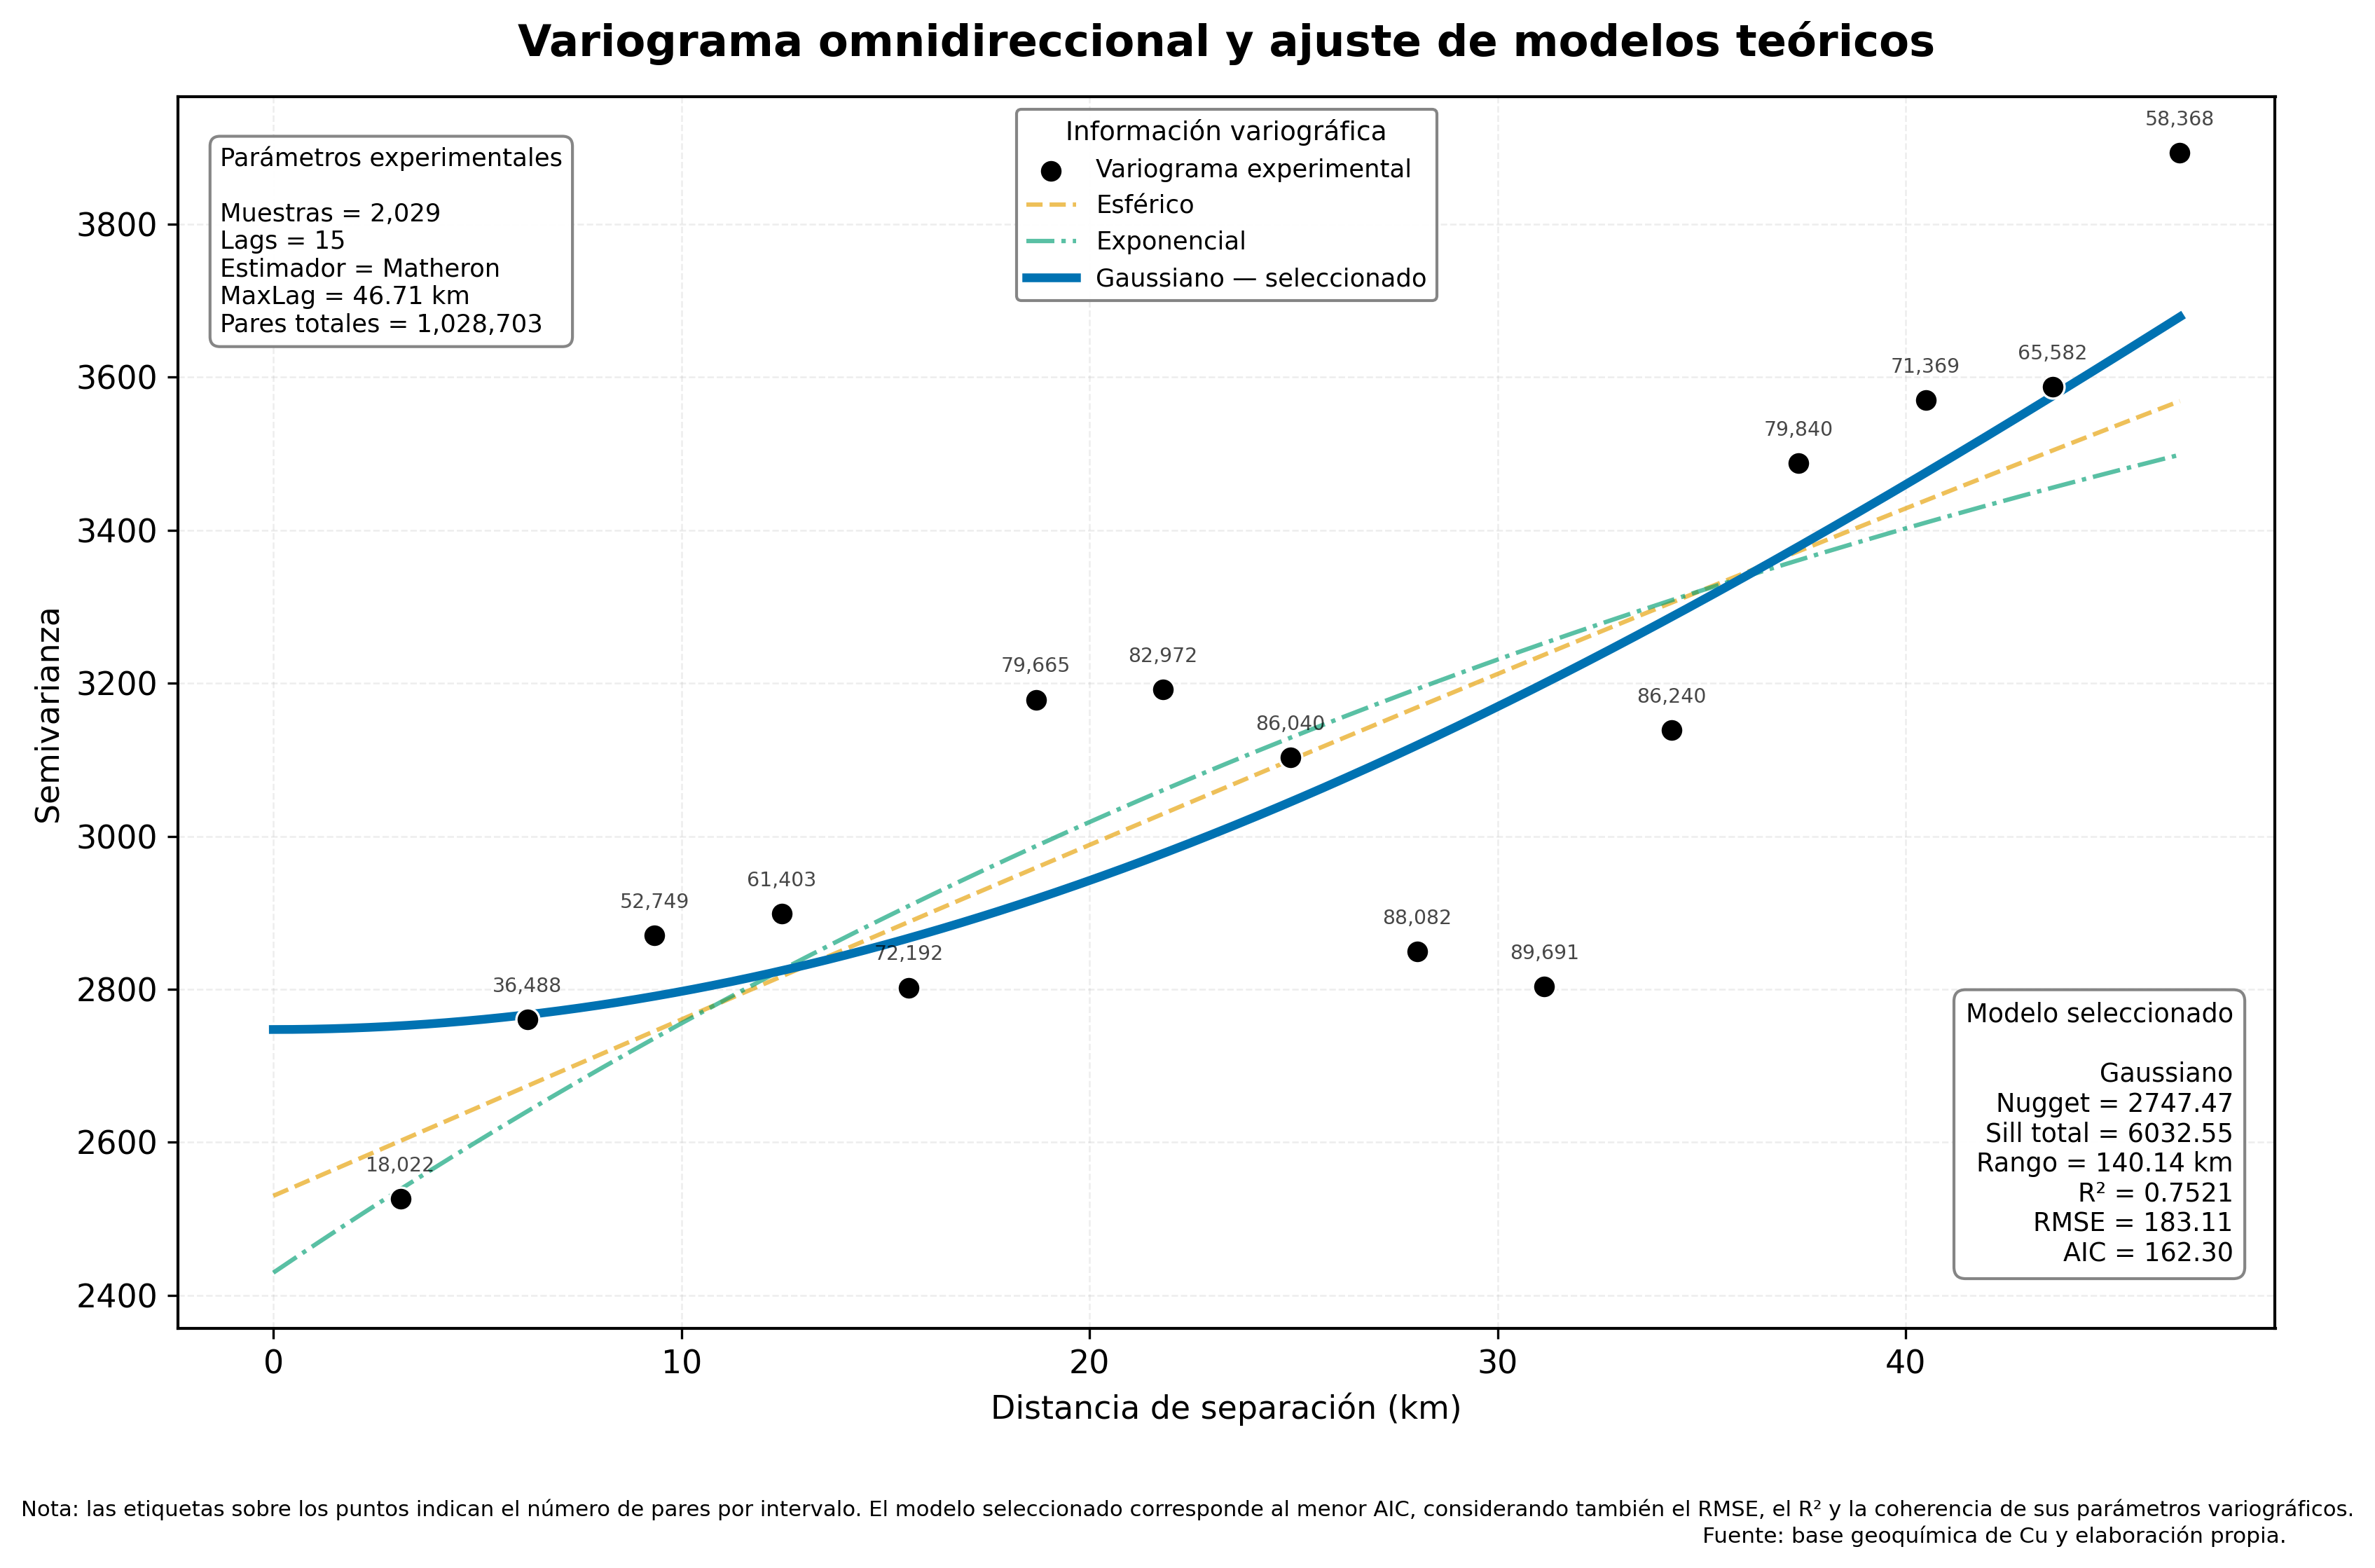

Modelo seleccionado: Gaussiano


In [151]:
# ==========================================================
# Figura 14. Ajuste y selección del modelo variográfico
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

# ----------------------------------------------------------
# 1. Datos experimentales
# ----------------------------------------------------------

h = np.asarray(distancias_omni, dtype=float)
gamma_exp = np.asarray(semivarianzas_omni, dtype=float)
pares = np.asarray(pares_por_lag_omni, dtype=float)

mascara = (
    np.isfinite(h)
    & np.isfinite(gamma_exp)
    & np.isfinite(pares)
    & (pares > 0)
)

h = h[mascara]
gamma_exp = gamma_exp[mascara]
pares = pares[mascara]

orden = np.argsort(h)

h = h[orden]
gamma_exp = gamma_exp[orden]
pares = pares[orden]

# ----------------------------------------------------------
# 2. Modelos variográficos
#
# Parámetros:
# nugget = efecto pepita
# partial_sill = meseta parcial
# rango = alcance práctico
# sill total = nugget + partial_sill
# ----------------------------------------------------------

def modelo_esferico(h, nugget, partial_sill, rango):
    h = np.asarray(h, dtype=float)
    relacion = h / rango

    return np.where(
        h <= rango,
        nugget
        + partial_sill
        * (1.5 * relacion - 0.5 * relacion**3),
        nugget + partial_sill
    )


def modelo_exponencial(h, nugget, partial_sill, rango):
    h = np.asarray(h, dtype=float)

    return (
        nugget
        + partial_sill
        * (1 - np.exp(-3 * h / rango))
    )


def modelo_gaussiano(h, nugget, partial_sill, rango):
    h = np.asarray(h, dtype=float)

    return (
        nugget
        + partial_sill
        * (1 - np.exp(-3 * (h / rango)**2))
    )


modelos = {
    "Esférico": modelo_esferico,
    "Exponencial": modelo_exponencial,
    "Gaussiano": modelo_gaussiano
}

# ----------------------------------------------------------
# 3. Valores iniciales y límites
# ----------------------------------------------------------

nugget_inicial = max(
    0.0,
    gamma_exp[0] * 0.50
)

sill_total_inicial = np.nanmedian(
    gamma_exp[-5:]
)

partial_sill_inicial = max(
    sill_total_inicial - nugget_inicial,
    np.nanstd(gamma_exp)
)

rango_inicial = h.max() * 0.50

p0 = [
    nugget_inicial,
    partial_sill_inicial,
    rango_inicial
]

limite_inferior = [
    0.0,
    0.0,
    max(h.min() * 0.25, 1.0)
]

limite_superior = [
    gamma_exp.max() * 2,
    gamma_exp.max() * 3,
    h.max() * 3
]

# Mayor número de pares = mayor peso en el ajuste
sigma_ajuste = 1 / np.sqrt(pares)

# ----------------------------------------------------------
# 4. Ajustar y evaluar los modelos
# ----------------------------------------------------------

resultados_modelos = []
curvas_modelos = {}

for nombre, funcion_modelo in modelos.items():

    try:
        parametros, covarianza = curve_fit(
            funcion_modelo,
            h,
            gamma_exp,
            p0=p0,
            bounds=(
                limite_inferior,
                limite_superior
            ),
            sigma=sigma_ajuste,
            absolute_sigma=False,
            maxfev=50000
        )

        nugget, partial_sill, rango = parametros
        sill_total = nugget + partial_sill

        gamma_estimado = funcion_modelo(
            h,
            nugget,
            partial_sill,
            rango
        )

        residuos = gamma_exp - gamma_estimado

        rss = np.sum(residuos**2)
        rmse = np.sqrt(np.mean(residuos**2))
        mae = np.mean(np.abs(residuos))

        ss_total = np.sum(
            (gamma_exp - gamma_exp.mean())**2
        )

        r2 = (
            1 - rss / ss_total
            if ss_total > 0
            else np.nan
        )

        n_obs = len(gamma_exp)
        k_parametros = 3

        aic = (
            n_obs * np.log(rss / n_obs)
            + 2 * k_parametros
            if rss > 0
            else -np.inf
        )

        resultados_modelos.append({
            "Modelo": nombre,
            "Nugget": nugget,
            "Meseta parcial": partial_sill,
            "Sill total": sill_total,
            "Rango práctico (m)": rango,
            "Rango práctico (km)": rango / 1000,
            "RMSE": rmse,
            "MAE": mae,
            "R²": r2,
            "RSS": rss,
            "AIC": aic
        })

        curvas_modelos[nombre] = {
            "funcion": funcion_modelo,
            "parametros": parametros
        }

    except Exception as error:
        print(
            f"No fue posible ajustar el modelo "
            f"{nombre}: {error}"
        )

tabla_modelos = pd.DataFrame(
    resultados_modelos
)

if tabla_modelos.empty:
    raise RuntimeError(
        "No fue posible ajustar ninguno de los modelos."
    )

# ----------------------------------------------------------
# 5. Seleccionar el modelo
# ----------------------------------------------------------

tabla_modelos = (
    tabla_modelos
    .sort_values(
        by=["AIC", "RMSE"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

modelo_seleccionado = tabla_modelos.loc[
    0,
    "Modelo"
]

tabla_modelos["Seleccionado"] = np.where(
    tabla_modelos["Modelo"]
    == modelo_seleccionado,
    "Sí",
    "No"
)

display(
    tabla_modelos.round({
        "Nugget": 2,
        "Meseta parcial": 2,
        "Sill total": 2,
        "Rango práctico (m)": 2,
        "Rango práctico (km)": 2,
        "RMSE": 2,
        "MAE": 2,
        "R²": 4,
        "RSS": 2,
        "AIC": 2
    })
)

# ----------------------------------------------------------
# 6. Preparar curvas para la figura
# ----------------------------------------------------------

h_curva = np.linspace(
    0,
    h.max(),
    600
)

colores_modelos = {
    "Esférico": "#E69F00",
    "Exponencial": "#009E73",
    "Gaussiano": "#0072B2"
}

estilos_modelos = {
    "Esférico": "--",
    "Exponencial": "-.",
    "Gaussiano": ":"
}

# ----------------------------------------------------------
# 7. Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 7.5)
)

# Puntos experimentales sin suavizar
ax.scatter(
    h / 1000,
    gamma_exp,
    s=62,
    facecolor="black",
    edgecolor="white",
    linewidth=0.8,
    label="Variograma experimental",
    zorder=5
)

# Etiquetas con número de pares
for distancia, semivarianza, numero_pares in zip(
    h / 1000,
    gamma_exp,
    pares
):
    ax.annotate(
        f"{int(numero_pares):,}",
        xy=(distancia, semivarianza),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=6.8,
        alpha=0.72,
        zorder=6
    )

# Modelos teóricos
for nombre in modelos:

    if nombre not in curvas_modelos:
        continue

    funcion = curvas_modelos[nombre]["funcion"]
    parametros = curvas_modelos[nombre]["parametros"]

    gamma_curva = funcion(
        h_curva,
        *parametros
    )

    es_seleccionado = (
        nombre == modelo_seleccionado
    )

    ax.plot(
        h_curva / 1000,
        gamma_curva,
        color=colores_modelos[nombre],
        linestyle=(
            "-"
            if es_seleccionado
            else estilos_modelos[nombre]
        ),
        linewidth=(
            3.0
            if es_seleccionado
            else 1.5
        ),
        alpha=(
            1.0
            if es_seleccionado
            else 0.65
        ),
        label=(
            f"{nombre} — seleccionado"
            if es_seleccionado
            else nombre
        ),
        zorder=(
            4
            if es_seleccionado
            else 2
        )
    )

# ----------------------------------------------------------
# 8. Parámetros del modelo seleccionado
# ----------------------------------------------------------

fila_seleccionada = tabla_modelos.loc[
    tabla_modelos["Modelo"]
    == modelo_seleccionado
].iloc[0]

texto_modelo = (
    "Modelo seleccionado\n\n"
    f"{modelo_seleccionado}\n"
    f"Nugget = {fila_seleccionada['Nugget']:.2f}\n"
    f"Sill total = {fila_seleccionada['Sill total']:.2f}\n"
    f"Rango = "
    f"{fila_seleccionada['Rango práctico (km)']:.2f} km\n"
    f"R² = {fila_seleccionada['R²']:.4f}\n"
    f"RMSE = {fila_seleccionada['RMSE']:.2f}\n"
    f"AIC = {fila_seleccionada['AIC']:.2f}"
)

ax.text(
    0.98,
    0.05,
    texto_modelo,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.8,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round,pad=0.45",
        alpha=0.96
    ),
    zorder=10
)

# ----------------------------------------------------------
# 9. Parámetros experimentales
# ----------------------------------------------------------

texto_experimental = (
    "Parámetros experimentales\n\n"
    f"Muestras = {len(valores_cu):,}\n"
    f"Lags = {len(h)}\n"
    f"Estimador = Matheron\n"
    f"MaxLag = {h.max()/1000:.2f} km\n"
    f"Pares totales = {int(pares.sum()):,}"
)

ax.text(
    0.02,
    0.96,
    texto_experimental,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.5,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round,pad=0.40",
        alpha=0.95
    ),
    zorder=10
)

# ----------------------------------------------------------
# 10. Formato
# ----------------------------------------------------------

ax.set_title(
    "Variograma omnidireccional y ajuste de modelos teóricos",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    "Distancia de separación (km)",
    fontsize=11
)

ax.set_ylabel(
    "Semivarianza",
    fontsize=11
)

ax.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.22
)

ax.set_axisbelow(True)

ax.legend(
    title="Información variográfica",
    loc="upper center",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.96,
    fontsize=8.5,
    title_fontsize=9
)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1)

# ----------------------------------------------------------
# 11. Nota y fuente
# ----------------------------------------------------------

fig.text(
    0.01,
    0.027,
    (
        "Nota: las etiquetas sobre los puntos indican el número de pares "
        "por intervalo. El modelo seleccionado corresponde al menor AIC, "
        "considerando también el RMSE, el R² y la coherencia de sus "
        "parámetros variográficos."
    ),
    ha="left",
    va="bottom",
    fontsize=7.4
)

fig.text(
    0.99,
    0.010,
    "Fuente: base geoquímica de Cu y elaboración propia.",
    ha="right",
    va="bottom",
    fontsize=7.5
)

plt.tight_layout(
    rect=[0, 0.065, 1, 1]
)

# ----------------------------------------------------------
# 12. Guardar y mostrar
# ----------------------------------------------------------

guardar_figura(
    "Figura_14_Ajuste_Modelos_Variograficos.png"
)

plt.show()

print(
    "Modelo seleccionado:",
    modelo_seleccionado
)

Figura 14. Variograma experimental omnidireccional y ajuste de los modelos teóricos esférico, exponencial y gaussiano.

In [147]:
# ==========================================================
# Tabla 13. Comparación de modelos variográficos
# ==========================================================

tabla_13 = tabla_modelos.copy()

tabla_13.to_csv(
    RESULTADOS /
    "Tabla_13_Comparacion_Modelos_Variograficos.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabla 13 guardada correctamente.")

Tabla 13 guardada correctamente.


Tabla 13. Comparación de los modelos teóricos ajustados al variograma experimental omnidireccional.

4.4 Validación cruzada del modelo variográfico